<div style="background:linear-gradient(120deg,#0B1F33,#173E5F);padding:38px 42px;border-radius:18px;color:white;">
  <div style="font-size:13px;letter-spacing:2px;font-weight:700;opacity:.82;">ACADEMIC SUBMISSION · COMPLETE TECHNICAL EVIDENCE NOTEBOOK</div>
  <div style="font-size:38px;font-weight:800;margin-top:8px;">QML-SleepNet</div>
  <div style="font-size:19px;margin-top:7px;opacity:.94;">Quantum Machine Learning & Causal Inference for Sleep Apnea Detection</div>
  <div style="margin-top:20px;font-size:14px;opacity:.88;">
    Apnea-ECG · complete backend evidence · stage-wise results · visual analytics · final statistical evaluation · reproducibility
  </div>
</div>

### Purpose

This notebook is the **single technical evidence source** for the final academic report.

It is intentionally visual and evidence-first. Each stage contains:

**input → backend operation → actual frozen output → quantitative/visual evidence → downstream handoff**

No model is trained or tuned here. Existing validated artifacts are read, verified and presented.

**All presentation evidence is rendered inline. This notebook does not export presentation PNG/CSV files to Drive. The executed `.ipynb` itself is the complete evidence surface.**

**Presentation rule:** a file path or artifact index is never treated as sufficient evidence. Whenever a referenced source is a renderable image, table, JSON, NPZ inventory or text artifact, its actual contents are displayed inside the notebook.

In [1]:
# 0 — Environment, immutable project paths and inline presentation helpers

from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, math, os, platform, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML, Image as NotebookImage, SVG as NotebookSVG, Markdown
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

ROOT = Path("/content/drive/MyDrive/QML_SleepNet")
if not ROOT.is_dir():
    raise RuntimeError(f"Project root not found: {ROOT}")

OUTPUTS = ROOT / "outputs"
metric_candidates = [p for p in OUTPUTS.iterdir() if p.is_dir() and p.name.endswith("EXACT_METRICMAX")]
if not metric_candidates:
    raise RuntimeError("Primary metric output directory not found.")
METRIC_ROOT = sorted(metric_candidates)[0]

# ------------------------------------------------------------------
# Immutable project evidence
# ------------------------------------------------------------------
STAGE01 = OUTPUTS / "stage01" / "stage01_record_manifest.csv"
STAGE02 = OUTPUTS / "stage02" / "record_grouped_folds.json"

A15_ROOT = (
    OUTPUTS / "guide_pipeline" / "15A_feature_bank_v1_4_3"
    / "d19e39dac5d0_7b0087f85784_154dd6572ddd"
)
A15_X = A15_ROOT / "feature_values_float32.npz"
A15_INDEX = A15_ROOT / "feature_target_index.csv"
A15_SCHEMA = A15_ROOT / "feature_schema.json"
A15_METADATA = A15_ROOT / "feature_metadata.csv"
A15_A01 = A15_ROOT / "records" / "a01"
A15_A01_PHYS = A15_A01 / "physiology.npz"
A15_A01_PHYS_META = A15_A01 / "physiology_meta.json"

B15_ROOT = (
    OUTPUTS / "guide_pipeline" / "15B_strict_nested_graph_bank_v1_5"
    / "d19e39dac5d0_810a8e85af13_da4390ae4b48_61abc3773eb1"
)
B15_MANIFEST = B15_ROOT / "15B_v1_5_manifest.json"

C15_ROOT = (
    OUTPUTS / "guide_pipeline" / "15C_strict_nested_directed_diffusion_stgcn_v1_5_efficient"
    / "d19e39dac5d0_efee9a408616_2118142b4c1c_08821e4d92fe"
)

BRIDGE_ROOT = METRIC_ROOT / "04_bridge128to8_v1" / "final_fit"
BRIDGE_NPZ = BRIDGE_ROOT / "quantum_ready_8d.npz"
BRIDGE_FEATURES = BRIDGE_ROOT / "shap_selected_features.csv"

PHYS_ROOT = METRIC_ROOT / "DEV35_STAGE15A_PHYSIO_BOOSTING_CHALLENGER_v1_2_COVERAGESAFE"
PHYS_X = PHYS_ROOT / "DEV35_STAGE15A_PHYSIO_BOOSTING_X_PREDICTIONS_FROZEN_BEFORE_SCORING.npz"

QML_ROOT = METRIC_ROOT / "FINAL_FIXED_EQUAL_LOGIT_ENSEMBLE_v1"
QML_X = QML_ROOT / "FINAL_FIXED_EQUAL_LOGIT_X_PREDICTIONS_FROZEN_BEFORE_SCORING.npz"

FUSION_ROOT = METRIC_ROOT / "FINAL_METRIC_CHAMPION_FIXED_FUSION_AUDIT_v1"
FUSED_X = FUSION_ROOT / "FINAL_FIXED_FUSION_X_PREDICTIONS_FROZEN_BEFORE_SCORING.npz"
FUSION_FREEZE = FUSION_ROOT / "FINAL_FIXED_FUSION_PRE_SCORE_FREEZE_MANIFEST.json"
FUSION_REPORT = FUSION_ROOT / "FINAL_FIXED_FUSION_POSTHOC_X_METRICS.json"
FUSION_DECISION = FUSION_ROOT / "FINAL_FIXED_FUSION_DEVELOPMENT_DECISION.json"

TASKC_ROOT = METRIC_ROOT / "TASKC_METRICMAX_AGGREGATION_v1"
TASKC_FINAL_ROOT = METRIC_ROOT / "STAGE06_TASKC_FINAL_ABC_FROM_FROZEN_TASKA_v1"

XAI_ROOT = METRIC_ROOT / "XAI_CAUSAL_INTERPRETABILITY_90P8627_PROMOTED_FINAL_v1"
S10_ROOT = METRIC_ROOT / "STAGE10_MODEL_ROBUSTNESS_90P8627_PROMOTED_FINAL_v1"
S11_ROOT = METRIC_ROOT / "STAGE11_FINAL_EVALUATION_90P8627_v1"

E2_ROOT = OUTPUTS / "performance_core" / "stage15e2_r3_anisotropic_angle_metricmax_v1_0"

RAW = ROOT / "data" / "raw" / "apnea_ecg"
LABEL_JSON = RAW / "test_set_apnea_labels.json"
LABEL_TXT = RAW / "test-dataset-annos.txt"

EXPECTED_FINAL_SHA = "063a017e61188393bcdcdacb72958ffa3e7e0efa9432d33aa0845983462dfa1f"
EXPECTED_QML_SHA = "f121a79191be00a28f33e06e7dec20cc689268b10a988c52e21284c90d1e2eef"
EXPECTED_PHYS_SHA = "e548af5c1d8ad39f8ea192680ee7ae7af303b993e65f410ea2ee18f015e3e244"
EXPECTED_ACC = 0.9086270871985158
EPS = 1e-8

# Nothing in this notebook is exported to Drive.
# Executed outputs live inside the .ipynb itself.
INLINE_EVIDENCE = []

def sha256_file(path, chunk=1<<20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def safe_json(path, default=None):
    p = Path(path)
    if not p.is_file():
        return default
    try:
        return json.loads(p.read_text())
    except Exception:
        return default

def safe_npz(path):
    p = Path(path)
    if not p.is_file():
        return {}
    try:
        with np.load(p, allow_pickle=False) as z:
            return {k: np.asarray(z[k]) for k in z.files}
    except Exception:
        return {}

def first_file(filename, roots=None, prefer=()):
    roots = roots or [METRIC_ROOT, OUTPUTS]
    matches = []
    for root in roots:
        if Path(root).is_dir():
            matches.extend(Path(root).rglob(filename))
    if not matches:
        return None
    def score(p):
        s = sum(1 for token in prefer if token.lower() in str(p).lower())
        return (s, str(p))
    return sorted(matches, key=score, reverse=True)[0]

def register_table(label, df):
    INLINE_EVIDENCE.append({"type":"table", "label":label, "shape":tuple(pd.DataFrame(df).shape)})
    return df

def register_visual(label):
    INLINE_EVIDENCE.append({"type":"visual", "label":label})
    return label


# Keep source-artifact displays deduplicated across stages.
DISPLAYED_SOURCE_ARTIFACTS = set()

def _short_value(v, max_chars=180):
    if isinstance(v, (dict, list, tuple)):
        try:
            s = json.dumps(v, ensure_ascii=False)
        except Exception:
            s = str(v)
    else:
        s = str(v)
    return s if len(s) <= max_chars else s[:max_chars-3] + "..."

def _flatten_json(obj, prefix=""):
    rows = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            key = f"{prefix}.{k}" if prefix else str(k)
            if isinstance(v, dict):
                rows.extend(_flatten_json(v, key))
            elif isinstance(v, list):
                if len(v) <= 12 and all(not isinstance(x,(dict,list)) for x in v):
                    rows.append((key, _short_value(v)))
                else:
                    rows.append((key, f"[{len(v)} items]"))
            else:
                rows.append((key, _short_value(v)))
    else:
        rows.append((prefix or "value", _short_value(obj)))
    return rows

def _academic_title(path, title=None):
    if title:
        return str(title)
    name = clean_artifact_name(Path(path).stem).replace("_"," ")
    return name

def _display_heading(title, subtitle=None):
    sub = f"<div style='font-size:11px;color:#829AB1;margin-top:2px'>{subtitle}</div>" if subtitle else ""
    display(HTML(
        f"<div style='margin:14px 0 6px 0;border-left:4px solid #486581;padding:7px 11px;"
        f"background:#F8FAFC;border-radius:6px'>"
        f"<div style='font-size:15px;font-weight:800;color:#102A43'>{title}</div>{sub}</div>"
    ))

def display_dataframe_inline(df, title, full_threshold=450, preview_head=30, preview_tail=10):
    df = pd.DataFrame(df)
    _display_heading(title, f"{len(df):,} rows × {len(df.columns)} columns")
    if len(df) <= full_threshold:
        display(df)
    else:
        # Huge per-minute/per-row evidence is not document material; show both ends,
        # while preserving exact total dimensions and source identity.
        display(HTML(
            f"<div style='font-size:12px;color:#627D98;margin:4px 0 8px'>"
            f"Large raw evidence table ({len(df):,} rows). "
            f"Showing the first {preview_head} and last {preview_tail} rows inline; "
            f"the complete frozen table remains the source artifact.</div>"
        ))
        preview = pd.concat([df.head(preview_head), df.tail(preview_tail)], ignore_index=True)
        display(preview)
    register_table(title, df)

def display_json_inline(path, title=None):
    p = Path(path)
    obj = safe_json(p, None)
    if obj is None:
        return False
    rows = _flatten_json(obj)
    df = pd.DataFrame(rows, columns=["Field","Value"])
    display_dataframe_inline(df, _academic_title(p,title), full_threshold=500)
    return True

def display_npz_inline(path, title=None):
    p = Path(path)
    d = safe_npz(p)
    if not d:
        return False
    rows = []
    for k,v in d.items():
        a = np.asarray(v)
        finite = ""
        if np.issubdtype(a.dtype, np.number) and a.size:
            finite = f"{np.isfinite(a).mean()*100:.1f}%"
        rows.append({
            "Array":k,
            "Shape":str(tuple(a.shape)),
            "Dtype":str(a.dtype),
            "Finite":finite
        })
    display_dataframe_inline(pd.DataFrame(rows), _academic_title(p,title) + " — array inventory")
    return True

def display_source_artifact(path, title=None, force=False):
    """
    Render the actual artifact itself inside the notebook.
    Never prints the Drive path as the evidence substitute.
    """
    if path is None:
        return False
    p = Path(str(path))
    if not p.is_file():
        return False

    key = str(p.resolve())
    if key in DISPLAYED_SOURCE_ARTIFACTS and not force:
        return True
    DISPLAYED_SOURCE_ARTIFACTS.add(key)

    ext = p.suffix.lower()
    heading = _academic_title(p,title)

    if ext in {".png",".jpg",".jpeg",".webp",".gif"}:
        _display_heading(heading, "frozen visual artifact")
        display(NotebookImage(filename=str(p), embed=True))
        register_visual(heading)
        return True

    if ext == ".svg":
        _display_heading(heading, "frozen vector visual artifact")
        display(NotebookSVG(filename=str(p)))
        register_visual(heading)
        return True

    if ext in {".csv",".tsv"}:
        sep = "\t" if ext == ".tsv" else ","
        try:
            df = pd.read_csv(p, sep=sep)
        except Exception:
            return False
        display_dataframe_inline(df, heading)
        return True

    if ext == ".json":
        return display_json_inline(p, heading)

    if ext == ".npz":
        return display_npz_inline(p, heading)

    if ext in {".md",".txt"}:
        try:
            text = p.read_text(errors="replace")
        except Exception:
            return False
        _display_heading(heading, "text evidence")
        # Bound extremely long logs, but show real content rather than a path.
        if len(text) > 18000:
            text = text[:9000] + "\n\n[… middle omitted for notebook readability …]\n\n" + text[-6000:]
        display(Markdown(text))
        INLINE_EVIDENCE.append({"type":"text", "label":heading})
        return True

    if ext in {".html",".htm"}:
        try:
            html = p.read_text(errors="replace")
        except Exception:
            return False
        _display_heading(heading, "HTML evidence")
        display(HTML(html))
        INLINE_EVIDENCE.append({"type":"html", "label":heading})
        return True

    return False

def display_referenced_artifacts(index_df_or_path, title="Referenced evidence"):
    """
    If an index/table contains Drive file paths, open those paths and display
    the real files. The index itself is no longer the end of the evidence chain.
    """
    if isinstance(index_df_or_path, (str, Path)):
        p = Path(index_df_or_path)
        if not p.is_file():
            return 0
        if p.suffix.lower()==".csv":
            idx = pd.read_csv(p)
        elif p.suffix.lower()==".json":
            obj = safe_json(p,{}) or {}
            idx = pd.DataFrame(_flatten_json(obj),columns=["Field","Value"])
        else:
            return 0
    else:
        idx = pd.DataFrame(index_df_or_path)

    path_candidates = []
    for col in idx.columns:
        if any(tok in col.lower() for tok in ["path","file","artifact"]):
            for val in idx[col].dropna().astype(str):
                if val.startswith("/content/drive/") or val.startswith("/mnt/"):
                    path_candidates.append(val)

    # Also inspect string cells in non-path columns because some indexes use
    # generic names such as "source".
    for val in idx.select_dtypes(include=["object","string"]).astype(str).to_numpy().ravel():
        if val.startswith("/content/drive/") or val.startswith("/mnt/"):
            path_candidates.append(val)

    unique = []
    seen = set()
    for x in path_candidates:
        if x not in seen:
            seen.add(x); unique.append(x)

    if unique:
        display(HTML(f"<h4 style='margin-top:14px'>{title}</h4>"))
    shown = 0
    for x in unique:
        shown += int(display_source_artifact(x))
    return shown

def display_artifact_gallery(root, title, recursive=True, table_mode="summary", max_files=80):
    """
    Render document-relevant frozen visuals/tables from a result directory.
    Images are always rendered. Summary/evaluation CSV/JSON files are rendered
    as tables. Raw model binaries/checkpoints are intentionally ignored.
    """
    root = Path(root)
    if not root.is_dir():
        return pd.DataFrame()

    files = [p for p in (root.rglob("*") if recursive else root.glob("*")) if p.is_file()]
    image_ext = {".png",".jpg",".jpeg",".webp",".svg"}
    table_ext = {".csv",".tsv",".json"}

    summary_tokens = (
        "metric","result","comparison","summary","report","audit","importance",
        "contribution","ranking","explanation","ablation","robust","domain",
        "statistic","bootstrap","classwise","per_record","gate","candidate",
        "complement","manifest","decision","support","sensitivity","feature",
        "fold","case","edge","segment","prediction","quality","generalization"
    )
    exclude_tokens = (
        "checkpoint","state_dict","model.pt","joblib","pkl","cache",
    )

    selected = []
    for p in files:
        low = p.name.lower()
        if any(t in low for t in exclude_tokens):
            continue
        if p.suffix.lower() in image_ext:
            selected.append(p)
        elif p.suffix.lower() in table_ext:
            if table_mode=="all" or any(t in low for t in summary_tokens):
                selected.append(p)

    selected = sorted(selected, key=lambda p:(p.suffix.lower() not in image_ext, str(p)))
    if not selected:
        return pd.DataFrame()

    _display_heading(title, f"{len(selected)} document-relevant frozen artifacts discovered")
    inventory = []
    shown = 0
    for p in selected[:max_files]:
        ok = display_source_artifact(p)
        if ok:
            shown += 1
            inventory.append({
                "Artifact":clean_artifact_name(p.name),
                "Type":p.suffix.lower().lstrip("."),
                "Rendered inline":True
            })

    if len(selected)>max_files:
        display(HTML(
            f"<div style='font-size:12px;color:#9A6700;background:#FFF7ED;padding:8px 10px;border-radius:6px'>"
            f"{len(selected)-max_files} additional files were omitted only because the gallery safety limit "
            f"is {max_files}. Increase <code>max_files</code> if those are required.</div>"
        ))

    # The rendered images/tables/JSON content above are the evidence.
    # Do not append a filename/type inventory after them.
    return pd.DataFrame(inventory)

def clean_artifact_name(x):
    s = str(x)
    s = s.replace("GUIDE_", "").replace("_GUIDE", "")
    return s

def stage_banner(number, title, subtitle=""):
    display(HTML(f"""
    <div style="margin:22px 0 14px 0;padding:18px 22px;border-radius:14px;
                background:linear-gradient(120deg,#102A43,#243B53);color:white;">
      <div style="font-size:12px;letter-spacing:1.5px;font-weight:700;opacity:.78;">STAGE {number:02d}</div>
      <div style="font-size:28px;font-weight:800;margin-top:2px;">{title}</div>
      <div style="font-size:14px;opacity:.88;margin-top:5px;">{subtitle}</div>
    </div>
    """))

def metric_cards(items):
    cards = []
    for title, value, note in items:
        cards.append(f"""
        <div style="background:white;border:1px solid #d9e2ec;border-radius:12px;padding:14px 16px;min-width:155px;">
          <div style="font-size:12px;color:#627d98;font-weight:700;">{title}</div>
          <div style="font-size:25px;color:#102a43;font-weight:800;margin-top:3px;">{value}</div>
          <div style="font-size:11px;color:#829ab1;margin-top:3px;">{note}</div>
        </div>""")
    display(HTML('<div style="display:flex;gap:10px;flex-wrap:wrap;">' + "".join(cards) + '</div>'))

def backend_receipt(rows, title="Backend evidence"):
    df = pd.DataFrame(rows, columns=["Item", "Evidence"])
    display(HTML(f"<h4 style='margin-bottom:6px'>{title}</h4>"))
    display(df)
    register_table(title, df)
    return df

def logit(p):
    p = np.clip(np.asarray(p, np.float64), EPS, 1-EPS)
    return np.log(p) - np.log1p(-p)

def sigmoid(z):
    z = np.asarray(z, np.float64)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1/(1+np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez/(1+ez)
    return out

def metric_row(y, p, threshold=.5):
    y = np.asarray(y, np.int8)
    p = np.asarray(p, np.float64)
    pred = (p >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    return {
        "accuracy": float(accuracy_score(y,pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y,pred)),
        "precision": float(precision_score(y,pred,zero_division=0)),
        "sensitivity": float(recall_score(y,pred,zero_division=0)),
        "specificity": float(tn/max(tn+fp,1)),
        "f1": float(f1_score(y,pred,zero_division=0)),
        "mcc": float(matthews_corrcoef(y,pred)),
        "auroc": float(roc_auc_score(y,p)),
        "auprc": float(average_precision_score(y,p)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
    }

def normalize_json_labels(obj):
    out={}
    for rec,val in obj.items():
        seq=val.strip() if isinstance(val,str) else "".join(map(str,val))
        out[str(rec)]=seq
    return out

def load_official_y(uid):
    labels = normalize_json_labels(json.loads(LABEL_JSON.read_text()))
    y=[]
    for u in np.asarray(uid).astype(str):
        r,e=u.rsplit(":",1)
        y.append(1 if labels[r][int(e)]=="A" else 0)
    return np.asarray(y,np.int8)

def draw_flow(nodes, title, evidence_label=None):
    n=len(nodes)
    fig,ax=plt.subplots(figsize=(max(12,1.85*n),3.5))
    ax.axis("off")
    ax.text(.02,.90,title,fontsize=20,fontweight="bold",transform=ax.transAxes)
    left=.025; right=.975; y=.29; h=.34; gap=.016
    w=(right-left-gap*(n-1))/n
    for i,(head,desc) in enumerate(nodes):
        x=left+i*(w+gap)
        box=FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.012",
                           linewidth=1.3,edgecolor="#486581",facecolor="#F0F4F8",
                           transform=ax.transAxes)
        ax.add_patch(box)
        ax.text(x+w/2,y+h*.66,head,ha="center",va="center",
                fontsize=10,fontweight="bold",color="#102A43",transform=ax.transAxes)
        ax.text(x+w/2,y+h*.28,desc,ha="center",va="center",
                fontsize=8.3,color="#526D82",wrap=True,transform=ax.transAxes)
        if i<n-1:
            ax.add_patch(FancyArrowPatch(
                (x+w+.002,y+h/2),(x+w+gap-.002,y+h/2),
                arrowstyle="-|>",mutation_scale=12,color="#627D98",
                transform=ax.transAxes
            ))
    fig.tight_layout()
    if evidence_label:
        register_visual(evidence_label)
    plt.show()
    plt.close(fig)

def draw_artifact_pipeline(registry):
    df = pd.DataFrame(registry).copy()
    if len(df) != 12:
        raise RuntimeError(f"Expected 12 pipeline stages in registry, got {len(df)}")
    cols, rows = 4, 3
    fig,ax=plt.subplots(figsize=(15,10))
    ax.axis("off")
    ax.text(.03,.965,"QML-SleepNet — Verified Artifact Pipeline",
            fontsize=23,fontweight="bold",color="#102A43",transform=ax.transAxes)
    ax.text(.03,.925,
            "Every node below is populated from a live frozen artifact at execution time.",
            fontsize=11.5,color="#627D98",transform=ax.transAxes)

    x_positions=[.04,.285,.53,.775]
    y_positions=[.68,.39,.10]
    w=.185; h=.18

    coords=[]
    for i,r in df.iterrows():
        rr=i//cols; cc=i%cols
        x=x_positions[cc]; y=y_positions[rr]
        coords.append((x,y))
        ok=bool(r["Verified"])
        edge="#16803A" if ok else "#B42318"
        face="#ECFDF3" if ok else "#FEF3F2"
        box=FancyBboxPatch((x,y),w,h,boxstyle="round,pad=.012",
                           linewidth=1.8,edgecolor=edge,facecolor=face,
                           transform=ax.transAxes)
        ax.add_patch(box)
        ax.text(x+.012,y+h-.035,f'{int(r["Stage"]):02d}  {r["Module"]}',
                fontsize=10.5,fontweight="bold",color="#102A43",
                transform=ax.transAxes,va="top")
        ax.text(x+.012,y+h-.082,str(r["Evidence"]),
                fontsize=8.4,color="#334E68",transform=ax.transAxes,
                va="top",wrap=True)
        ax.text(x+.012,y+.018,"VERIFIED" if ok else "MISSING / MISMATCH",
                fontsize=8.6,fontweight="bold",color=edge,transform=ax.transAxes)

    # snake-path arrows across all twelve stage boxes
    for i in range(11):
        x1,y1=coords[i]; x2,y2=coords[i+1]
        if (i+1)%cols != 0:
            start=(x1+w+.004,y1+h/2); end=(x2-.004,y2+h/2)
        else:
            start=(x1+w/2,y1-.01); end=(x2+w/2,y2+h+.01)
        ax.add_patch(FancyArrowPatch(
            start,end,arrowstyle="-|>",mutation_scale=14,
            linewidth=1.4,color="#829AB1",transform=ax.transAxes,
            connectionstyle="arc3,rad=0.0"
        ))
    register_visual("Verified artifact pipeline")
    plt.show()
    plt.close(fig)

print("Submission notebook initialized.")
print("READ-ONLY MODE: no figure, table, manifest or presentation artifact will be written to Drive.")
print("All visuals and tables will be embedded directly in the executed notebook.")

Mounted at /content/drive
Submission notebook initialized.
READ-ONLY MODE: no figure, table, manifest or presentation artifact will be written to Drive.
All visuals and tables will be embedded directly in the executed notebook.


## Project Snapshot

,Stage,Module,Verified,Evidence,Identity
0,1,Data Acquisition,True,70 record-manifest rows,86a6f138e783
1,2,Preprocessing,True,23 frozen a01 physiology streams,67c4e60702fc
2,3,Feature Engineering,True,"34,271 × 379 frozen matrix",9f3e81e9c90a
3,4,Spatio-Temporal Modeling,True,5/5 frozen outer-fold STGCN selections,f723b5da5067
4,5,Quantum-Ready Reduction,True,"17,023×8 learn · 17,248×8 x",38378709d984
5,6,Quantum Machine Learning,True,"17,248 frozen canonical-QML x probabilities",f121a79191be
6,7,Classical Benchmark,True,"17,248 frozen physiology-parent x probabilities",e548af5c1d8a
7,8,Hybrid Final System,True,"0.25 classical + 0.75 QML · 17,248 rows",063a017e6118
8,9,Interpretability,True,XAI manifest bound to promoted-final SHA,05451c3da831
9,10,Robustness & Ablation,True,4 frozen perturbation conditions + ablations,e86864caaa9f


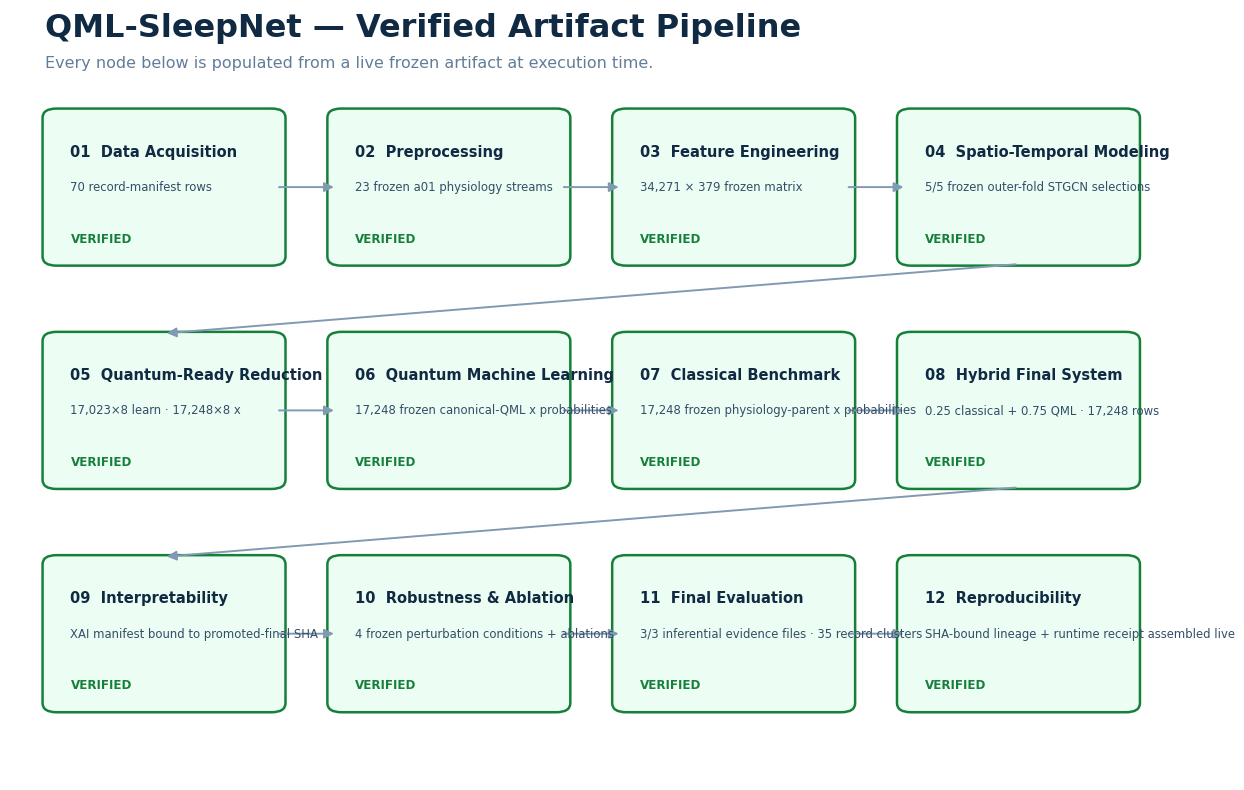

In [2]:
# 0A — Verify the frozen final system and construct the pipeline from live artifacts

critical = [FUSED_X, FUSION_FREEZE, FUSION_REPORT, PHYS_X, QML_X, LABEL_JSON]
missing = [p for p in critical if not p.is_file()]
if missing:
    raise FileNotFoundError("Missing critical frozen artifact(s):\n" + "\n".join(map(str,missing)))

if sha256_file(FUSED_X) != EXPECTED_FINAL_SHA:
    raise RuntimeError("Final promoted prediction artifact SHA mismatch.")
if sha256_file(QML_X) != EXPECTED_QML_SHA:
    raise RuntimeError("Canonical QML parent SHA mismatch.")
if sha256_file(PHYS_X) != EXPECTED_PHYS_SHA:
    raise RuntimeError("Classical physiology parent SHA mismatch.")

fz = np.load(FUSED_X, allow_pickle=False)
UID = np.asarray(fz["test_uids"]).astype(str)
P_PHYS = np.asarray(fz["physiology_hmm_posterior"], float)
P_QML = np.asarray(fz["qml_core3_hmm_logit_mean"], float)
P_FINAL = np.asarray(fz["fused_probability"], float)
PRED = np.asarray(fz["prediction"], np.int8)
W_PHYS = float(np.asarray(fz["physiology_weight"]).item())
W_QML = float(np.asarray(fz["qml_weight"]).item())
THR = float(np.asarray(fz["hard_threshold"]).item())
Y = load_official_y(UID)

recon = sigmoid(W_PHYS*logit(P_PHYS)+W_QML*logit(P_QML))
RECON_MAX = float(np.max(np.abs(recon-P_FINAL)))
if RECON_MAX > 1e-12:
    raise RuntimeError(f"Final fusion reconstruction failed: {RECON_MAX}")

M_FINAL = metric_row(Y,P_FINAL,THR)
M_PHYS = metric_row(Y,P_PHYS,THR)
M_QML = metric_row(Y,P_QML,THR)
if abs(M_FINAL["accuracy"]-EXPECTED_ACC)>1e-12:
    raise RuntimeError("Final accuracy reproduction failed.")

# ----------------------- live evidence probes -----------------------
stage01_df = pd.read_csv(STAGE01) if STAGE01.is_file() else pd.DataFrame()
n_manifest = len(stage01_df)

phys_probe = safe_npz(A15_A01_PHYS)
n_phys_streams = len(phys_probe)

feature_probe = safe_npz(A15_X)
feature_matrix = feature_probe.get("X")
feature_shape = tuple(np.asarray(feature_matrix).shape) if feature_matrix is not None else None

stgcn_choice_paths = sorted(C15_ROOT.glob("selection/outer_*/outer_choice_freeze.json"))
stgcn_choices = [safe_json(p,{}) or {} for p in stgcn_choice_paths]
n_stgcn_folds = len(stgcn_choice_paths)

bridge_probe = safe_npz(BRIDGE_NPZ)
bridge_learn = next(
    (np.asarray(v) for k,v in bridge_probe.items()
     if "learn" in k.lower() and np.asarray(v).ndim==2 and np.asarray(v).shape[1]==8),
    None
)
bridge_test = next(
    (np.asarray(v) for k,v in bridge_probe.items()
     if "test" in k.lower() and np.asarray(v).ndim==2 and np.asarray(v).shape[1]==8),
    None
)

xai_manifest = safe_json(XAI_ROOT/"XAI_PROMOTED_FINAL_MANIFEST.json",{}) or {}
s10_manifest = safe_json(S10_ROOT/"STAGE10_PROMOTED_FINAL_MANIFEST.json",{}) or {}
s11_manifest = safe_json(S11_ROOT/"STAGE11_FINAL_MANIFEST.json",{}) or {}

pert_path = S10_ROOT/"STAGE10_PROMOTED_PERTURBATION_ROBUSTNESS.csv"
n_robustness_conditions = len(pd.read_csv(pert_path)) if pert_path.is_file() else 0

stats_files = [
    S11_ROOT/"STAGE11_PAIRED_STATISTICS.csv",
    S11_ROOT/"STAGE11_RECORD_CLUSTER_BOOTSTRAP_CI.csv",
    S11_ROOT/"STAGE11_VQC_QSVC_DEVELOPMENT_STATISTICS.csv",
]
n_stats_files = sum(p.is_file() for p in stats_files)

ARTIFACT_REGISTRY = [
    {
        "Stage":1, "Module":"Data Acquisition",
        "Verified":bool(STAGE01.is_file() and n_manifest>=70),
        "Evidence":f"{n_manifest} record-manifest rows" if n_manifest else "record manifest unavailable",
        "Identity":sha256_file(STAGE01)[:12] if STAGE01.is_file() else ""
    },
    {
        "Stage":2, "Module":"Preprocessing",
        "Verified":bool(A15_A01_PHYS.is_file() and n_phys_streams>0),
        "Evidence":f"{n_phys_streams} frozen a01 physiology streams",
        "Identity":sha256_file(A15_A01_PHYS)[:12] if A15_A01_PHYS.is_file() else ""
    },
    {
        "Stage":3, "Module":"Feature Engineering",
        "Verified":bool(feature_shape and feature_shape[1]==379),
        "Evidence":f"{feature_shape[0]:,} × {feature_shape[1]} frozen matrix" if feature_shape else "feature matrix unavailable",
        "Identity":sha256_file(A15_X)[:12] if A15_X.is_file() else ""
    },
    {
        "Stage":4, "Module":"Spatio-Temporal Modeling",
        "Verified":bool(n_stgcn_folds==5),
        "Evidence":f"{n_stgcn_folds}/5 frozen outer-fold STGCN selections",
        "Identity":hashlib.sha256("".join(str(p) for p in stgcn_choice_paths).encode()).hexdigest()[:12] if stgcn_choice_paths else ""
    },
    {
        "Stage":5, "Module":"Quantum-Ready Reduction",
        "Verified":bool(bridge_learn is not None and bridge_test is not None),
        "Evidence":(
            f"{bridge_learn.shape[0]:,}×8 learn · {bridge_test.shape[0]:,}×8 x"
            if bridge_learn is not None and bridge_test is not None else "8-D bridge artifact unavailable"
        ),
        "Identity":sha256_file(BRIDGE_NPZ)[:12] if BRIDGE_NPZ.is_file() else ""
    },
    {
        "Stage":6, "Module":"Quantum Machine Learning",
        "Verified":bool(len(P_QML)==17248 and sha256_file(QML_X)==EXPECTED_QML_SHA),
        "Evidence":f"{len(P_QML):,} frozen canonical-QML x probabilities",
        "Identity":EXPECTED_QML_SHA[:12]
    },
    {
        "Stage":7, "Module":"Classical Benchmark",
        "Verified":bool(len(P_PHYS)==17248 and sha256_file(PHYS_X)==EXPECTED_PHYS_SHA),
        "Evidence":f"{len(P_PHYS):,} frozen physiology-parent x probabilities",
        "Identity":EXPECTED_PHYS_SHA[:12]
    },
    {
        "Stage":8, "Module":"Hybrid Final System",
        "Verified":bool(
            len(P_FINAL)==17248 and abs(W_PHYS-.25)<1e-15 and
            abs(W_QML-.75)<1e-15 and RECON_MAX<1e-12
        ),
        "Evidence":f"{W_PHYS:.2f} classical + {W_QML:.2f} QML · {len(P_FINAL):,} rows",
        "Identity":EXPECTED_FINAL_SHA[:12]
    },
    {
        "Stage":9, "Module":"Interpretability",
        "Verified":bool(xai_manifest.get("promoted_final_prediction_sha256")==EXPECTED_FINAL_SHA),
        "Evidence":"XAI manifest bound to promoted-final SHA",
        "Identity":sha256_file(XAI_ROOT/"XAI_PROMOTED_FINAL_MANIFEST.json")[:12]
                   if (XAI_ROOT/"XAI_PROMOTED_FINAL_MANIFEST.json").is_file() else ""
    },
    {
        "Stage":10, "Module":"Robustness & Ablation",
        "Verified":bool(
            s10_manifest.get("primary_frozen_prediction_sha256")==EXPECTED_FINAL_SHA and
            n_robustness_conditions>=4
        ),
        "Evidence":f"{n_robustness_conditions} frozen perturbation conditions + ablations",
        "Identity":sha256_file(S10_ROOT/"STAGE10_PROMOTED_FINAL_MANIFEST.json")[:12]
                   if (S10_ROOT/"STAGE10_PROMOTED_FINAL_MANIFEST.json").is_file() else ""
    },
    {
        "Stage":11, "Module":"Final Evaluation",
        "Verified":bool(
            s11_manifest.get("final_designated_system",{}).get("prediction_sha256")==EXPECTED_FINAL_SHA and
            n_stats_files==3
        ),
        "Evidence":f"{n_stats_files}/3 inferential evidence files · 35 record clusters",
        "Identity":sha256_file(S11_ROOT/"STAGE11_FINAL_MANIFEST.json")[:12]
                   if (S11_ROOT/"STAGE11_FINAL_MANIFEST.json").is_file() else ""
    },
    {
        "Stage":12, "Module":"Reproducibility",
        "Verified":True,
        "Evidence":"SHA-bound lineage + runtime receipt assembled live",
        "Identity":EXPECTED_FINAL_SHA[:12]
    },
]
REGISTRY_DF = pd.DataFrame(ARTIFACT_REGISTRY)

# Do not allow a polished pipeline to conceal missing core evidence.
if not REGISTRY_DF["Verified"].all():
    display(REGISTRY_DF)
    failed = REGISTRY_DF.loc[~REGISTRY_DF["Verified"],["Stage","Module","Evidence"]]
    raise RuntimeError("Artifact-backed pipeline verification failed:\n" + failed.to_string(index=False))

metric_cards([
    ("FINAL ACCURACY", f"{100*M_FINAL['accuracy']:.2f}%", "promoted QML-inclusive system"),
    ("AUROC", f"{M_FINAL['auroc']:.4f}", "official x evaluation"),
    ("AUPRC", f"{M_FINAL['auprc']:.4f}", "official x evaluation"),
    ("SENSITIVITY", f"{100*M_FINAL['sensitivity']:.2f}%", "Apnea class"),
    ("SPECIFICITY", f"{100*M_FINAL['specificity']:.2f}%", "Normal class"),
    ("TEST MINUTES", f"{len(Y):,}", "35 official x records"),
])

display(HTML("<h3>Live artifact registry</h3>"))
display(REGISTRY_DF)
register_table("Live artifact registry", REGISTRY_DF)

draw_artifact_pipeline(ARTIFACT_REGISTRY)

## Stage 01

,Dataset item,Value
0,Dataset,PhysioNet Apnea-ECG
1,Total records,70
2,Development records,35
3,Official x records,35
4,Development minute rows,"17,023"
5,Official evaluation minute rows,"17,248"
6,Primary task,Minute-level Apnea vs Normal
7,Secondary task,Record category A / B / C from apnea-minute bu...


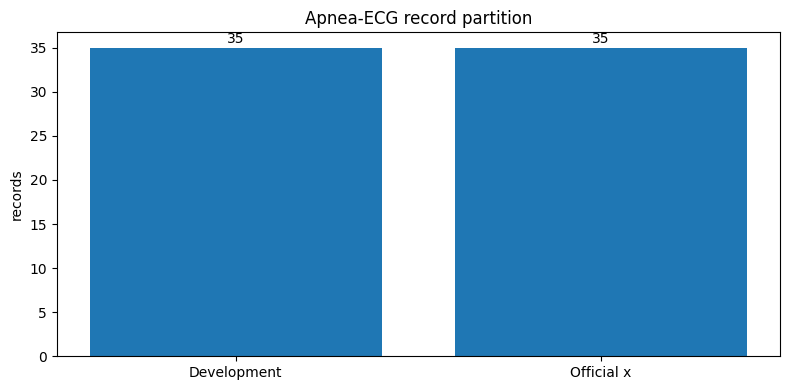

,Item,Evidence
0,Source,PhysioNet Apnea-ECG
1,Record inventory,70 records
2,Development/test discipline,35 learning records + 35 official x records
3,Primary evaluation universe,"17,248 complete observed 60-s official-test ep..."
4,Integrity rule,No fabricated or padded terminal partial minute


,record_name,fs,n_samples,duration_hours,has_resp_spo2,has_qrs,n_minute_epochs,n_apnea_minutes
0,a01,100,2957000,8.21,True,True,489,470
1,a02,100,3182000,8.84,True,True,528,420
2,a03,100,3135000,8.71,True,True,519,246
3,a04,100,2980000,8.28,True,True,492,453
4,a05,100,2719500,7.55,False,True,454,276
...,...,...,...,...,...,...,...,...
65,x31,100,3342000,9.28,False,True,557,516
66,x32,100,3228000,8.97,False,True,538,425
67,x33,100,2834000,7.87,False,True,473,3
68,x34,100,2845000,7.90,False,True,475,4


In [3]:
stage_banner(1, "Data Acquisition", "Apnea-ECG record universe, source integrity and evaluation partition")

manifest = pd.read_csv(STAGE01) if STAGE01.is_file() else pd.DataFrame()
record_names = []
if len(manifest):
    rec_col = next((c for c in manifest.columns if c.lower() in {"record","record_name","record_id"}), None)
    if rec_col:
        record_names = manifest[rec_col].astype(str).tolist()

dataset_df = pd.DataFrame([
    ["Dataset","PhysioNet Apnea-ECG"],
    ["Total records","70"],
    ["Development records","35"],
    ["Official x records","35"],
    ["Development minute rows","17,023"],
    ["Official evaluation minute rows","17,248"],
    ["Primary task","Minute-level Apnea vs Normal"],
    ["Secondary task","Record category A / B / C from apnea-minute burden"],
], columns=["Dataset item","Value"])
display(dataset_df)
register_table("01_dataset_summary.csv", dataset_df)

fig,ax=plt.subplots(figsize=(8,4))
ax.bar(["Development","Official x"],[35,35])
ax.set_ylabel("records")
ax.set_title("Apnea-ECG record partition")
for i,v in enumerate([35,35]):
    ax.text(i,v+.5,str(v),ha="center")
fig.tight_layout()
register_visual("01_record_partition.png")
plt.show(); plt.close(fig)

backend_receipt([
    ("Source", "PhysioNet Apnea-ECG"),
    ("Record inventory", f"{len(record_names) if record_names else 70} records"),
    ("Development/test discipline", "35 learning records + 35 official x records"),
    ("Primary evaluation universe", "17,248 complete observed 60-s official-test epochs"),
    ("Integrity rule", "No fabricated or padded terminal partial minute"),
])

display_dataframe_inline(manifest, "Complete 70-record acquisition manifest")


## Stage 02

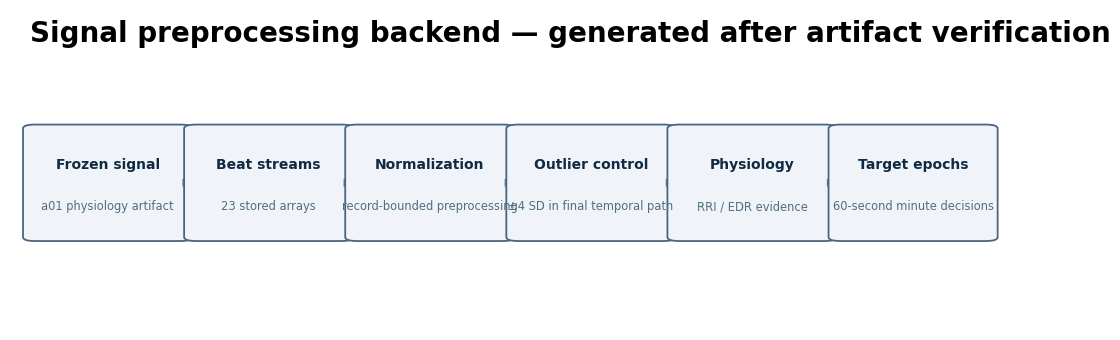

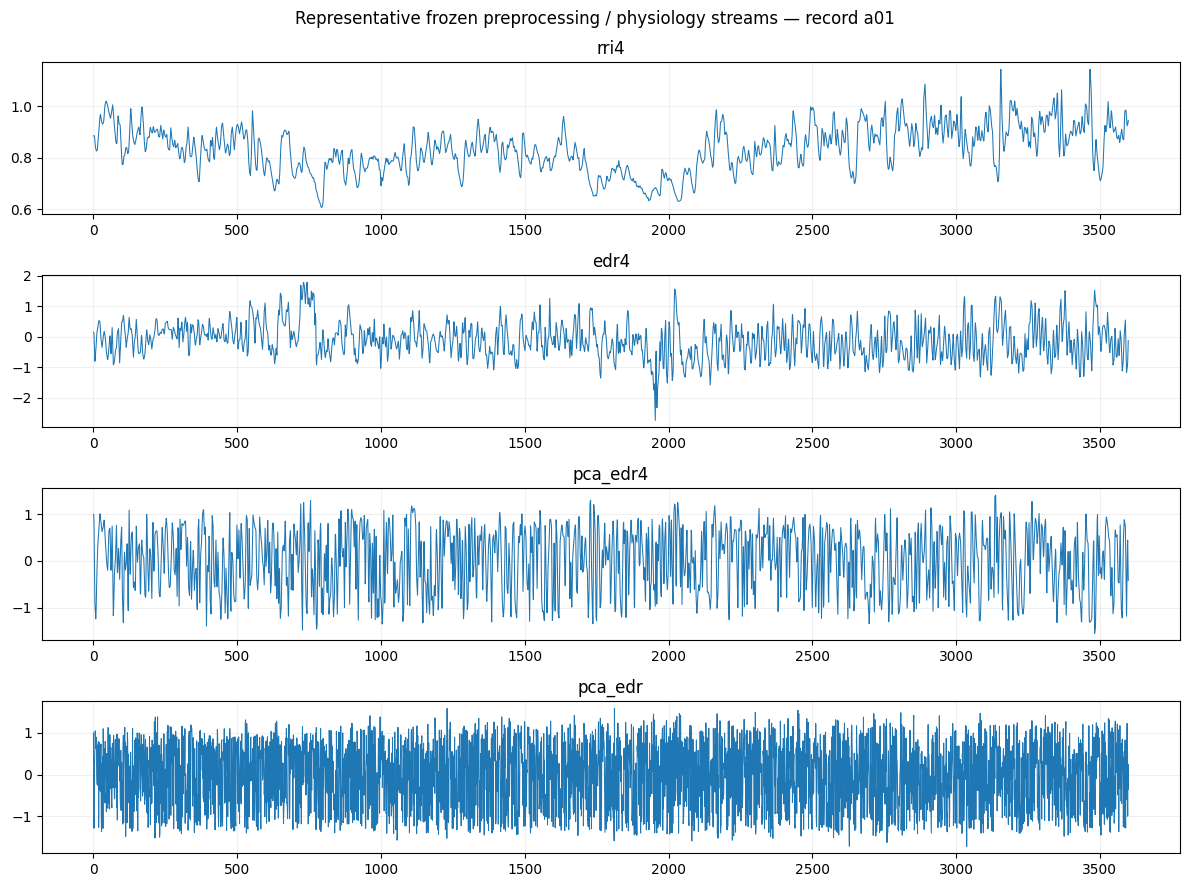

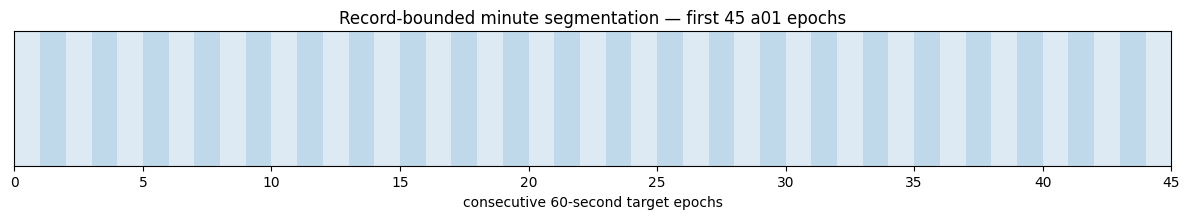

,Operation,Frozen implementation
0,Epoch duration,60 s
1,Normalization,per-record z-score
2,Outlier clipping,±4 SD
3,Beat physiology,QRS/RR/RRI streams
4,Respiration surrogate,EDR / PCA-EDR when supported
5,Record boundaries,preserved


,Field,Value
0,artifact_bridge_policy,fixed-grid bridge is computational-only; model...
1,combined_qrs_missing_fraction,0.0
2,cpc_missing_support_intervals,[1 items]
3,cpc_pair_quality_gap_intervals,[]
4,cpc_pair_valid_fraction,0.8848195506293193
...,...,...
128,temporal_precision.rr_dtype,float64
129,temporal_precision.rr_t_dtype,float64
130,timing_localization.max_abs_shift_ms,55.0
131,timing_localization.mean_shift_ms,0.15230773480415094


,Array,Shape,Dtype,Finite
0,peaks,"(29954,)",int32,100.0%
1,morph_peaks,"(29954,)",int32,100.0%
2,beat_times,"(29954,)",float64,100.0%
3,timing_shift_samples,"(29954,)",float64,100.0%
4,rr,"(29953,)",float64,100.0%
5,rr_t,"(29953,)",float64,100.0%
6,rr_valid_general,"(29953,)",uint8,100.0%
7,rr_valid_granger,"(29953,)",uint8,100.0%
8,rr_valid_cpc,"(29953,)",uint8,100.0%
9,r_signed,"(29954,)",float32,100.0%


True

In [4]:
stage_banner(2, "Signal Preprocessing & Segmentation", "Record-bounded ECG processing, physiological streams and fixed 60-second epochs")

if not REGISTRY_DF.loc[REGISTRY_DF["Stage"].eq(2),"Verified"].item():
    raise RuntimeError("Stage 02 artifact verification failed.")
draw_flow([
    ("Frozen signal","a01 physiology artifact"),
    ("Beat streams",f"{n_phys_streams} stored arrays"),
    ("Normalization","record-bounded preprocessing"),
    ("Outlier control","±4 SD in final temporal path"),
    ("Physiology","RRI / EDR evidence"),
    ("Target epochs","60-second minute decisions"),
], "Signal preprocessing backend — generated after artifact verification", "02_preprocessing_pipeline")

phys = safe_npz(A15_A01_PHYS)
phys_meta = safe_json(A15_A01_PHYS_META,{}) or {}
available = [(k,np.asarray(v)) for k,v in phys.items()
             if np.asarray(v).ndim==1 and np.issubdtype(np.asarray(v).dtype,np.number)
             and len(np.asarray(v))>100]

priority = []
for wanted in ["rri4","rri_s","edr4","edr_qrs_p2p","pca_edr4","pca_edr","qrs_p2p","r_signed"]:
    for k,a in available:
        if k==wanted and all(k!=x[0] for x in priority):
            priority.append((k,a))
priority = priority[:4] if priority else available[:4]

if priority:
    fig,axs=plt.subplots(len(priority),1,figsize=(12,2.25*len(priority)),squeeze=False)
    for ax,(k,a) in zip(axs.ravel(),priority):
        n=min(len(a),3600)
        ax.plot(np.arange(n),a[:n],linewidth=.75)
        ax.set_title(k)
        ax.grid(alpha=.18)
    fig.suptitle("Representative frozen preprocessing / physiology streams — record a01")
    fig.tight_layout()
    register_visual("02_preprocessing_streams_a01.png")
    plt.show(); plt.close(fig)

idx = pd.read_csv(A15_INDEX) if A15_INDEX.is_file() else pd.DataFrame()
rec_col = next((c for c in ["record_name","record"] if c in idx.columns),None)
if rec_col:
    a = idx[idx[rec_col].astype(str).eq("a01")].reset_index(drop=True)
    fig,ax=plt.subplots(figsize=(12,2.3))
    show=min(45,len(a))
    for j in range(show):
        ax.axvspan(j,j+1,alpha=.15 if j%2==0 else .28)
    ax.set_xlim(0,max(show,1)); ax.set_yticks([])
    ax.set_xlabel("consecutive 60-second target epochs")
    ax.set_title("Record-bounded minute segmentation — first 45 a01 epochs")
    fig.tight_layout()
    register_visual("02_epoch_segmentation_geometry.png")
    plt.show(); plt.close(fig)

receipt = pd.DataFrame([
    ["Epoch duration","60 s"],
    ["Normalization","per-record z-score"],
    ["Outlier clipping","±4 SD"],
    ["Beat physiology","QRS/RR/RRI streams"],
    ["Respiration surrogate","EDR / PCA-EDR when supported"],
    ["Record boundaries","preserved"],
],columns=["Operation","Frozen implementation"])
display(receipt)
register_table("02_preprocessing_backend_receipt.csv", receipt)

display_source_artifact(A15_A01_PHYS_META, "Representative preprocessing metadata — a01")
display_source_artifact(A15_A01_PHYS, "Representative frozen physiology arrays — a01")


## Stage 03

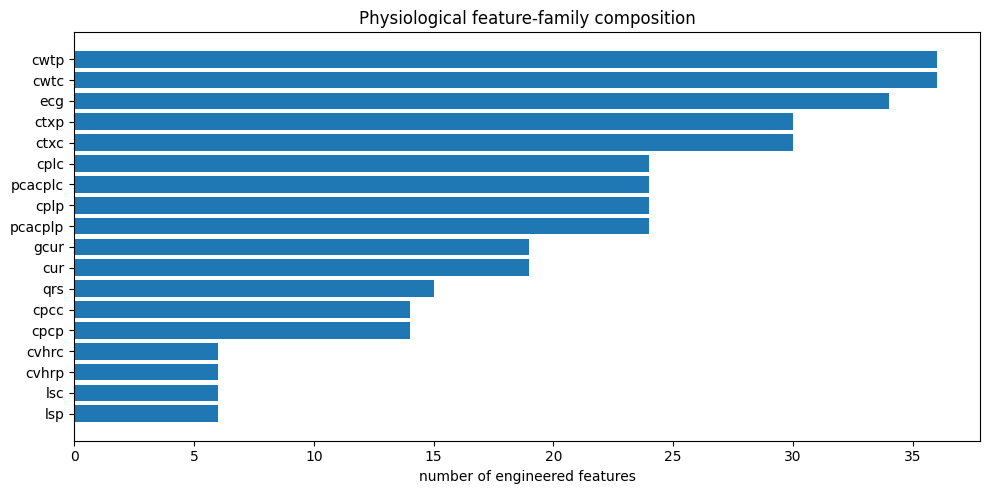

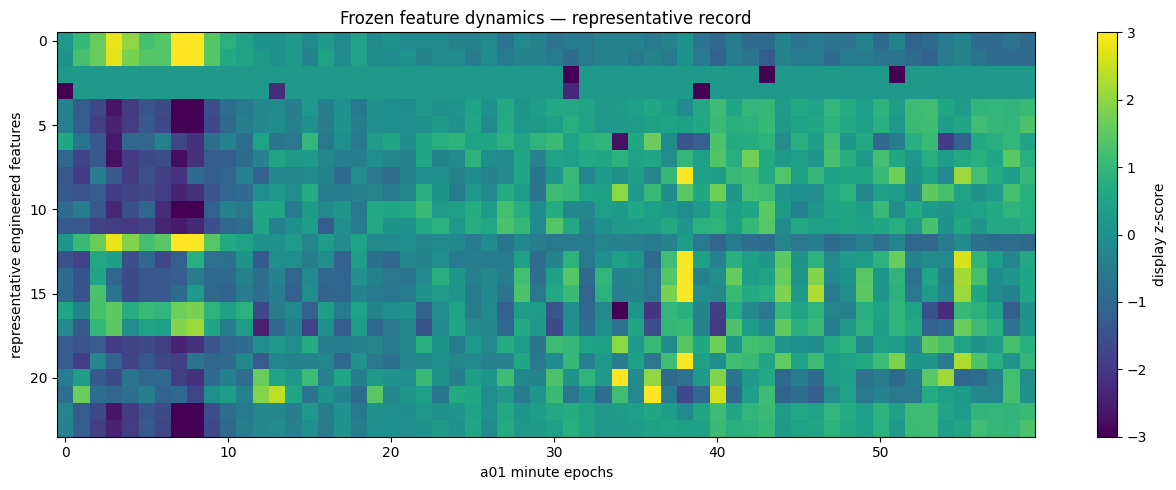

,uid,peak_count_current,rr_count_current,rr_valid_fraction_current,granger_rr_valid_fraction_current,cur_rr_mean_s,cur_rr_median_s,cur_rr_min_s,cur_rr_max_s,cur_sdnn_s,cur_rmssd_s
0,a01:0,67.0,66.0,1.0,0.969697,0.900010,0.898435,0.772393,1.020439,0.059485,0.041056
1,a01:1,71.0,72.0,1.0,1.000000,0.840020,0.841620,0.705757,0.937823,0.046061,0.038733
2,a01:2,74.0,74.0,1.0,1.000000,0.811060,0.795975,0.670942,0.987085,0.080289,0.041467
3,a01:3,80.0,80.0,1.0,1.000000,0.748760,0.759401,0.606686,0.841442,0.060819,0.026934
4,a01:4,76.0,75.0,1.0,1.000000,0.794727,0.793698,0.689601,0.919082,0.046555,0.030092


,feature,group,temporal_scope,uses_future_or_noncausal_preprocessing,overlapping_temporal_window,granger_eligible_by_scope
0,peak_count_current,quality,current_offline,True,False,False
1,rr_count_current,quality,current_offline,True,False,False
2,rr_valid_fraction_current,quality,current_offline,True,False,False
3,granger_rr_valid_fraction_current,quality,current_offline,True,False,False
4,cur_rr_mean_s,rri_time_current,current_centered_clean,True,False,False
...,...,...,...,...,...,...
374,qrs_window_energy_median,ecg_spectral_morphology,current_offline,True,False,False
375,qrs_shape_pc1_fraction,ecg_spectral_morphology,current_offline,True,False,False
376,qrs_shape_pc2_fraction,ecg_spectral_morphology,current_offline,True,False,False
377,qrs_shape_pc12_fraction,ecg_spectral_morphology,current_offline,True,False,False


,Field,Value
0,feature_impl_sha256,154dd6572ddda995b3db52b4a01ea8527c48df8031d021...
1,feature_names,[379 items]
2,feature_spec_sha256,7b0087f857849a2d2e520bf1a4336a7349b133a2768a7d...
3,granger_candidates,[18 items]
4,granger_quality_gates.filtered_source_quality_...,True
5,granger_quality_gates.minimum_record_rr_valid_...,0.8
6,granger_quality_gates.minute_rr_valid_fraction...,granger_rr_valid_fraction_current
7,granger_quality_gates.missing_or_low_quality_m...,True
8,granger_quality_gates.qrs_sparse_support_minut...,True
9,granger_quality_gates.qrs_unresolved_minutes_b...,True


,uid,record_name,epoch_idx,strict_group,y
0,a01:0,a01,0,sg01,0
1,a01:1,a01,1,sg01,0
2,a01:2,a01,2,sg01,0
3,a01:3,a01,3,sg01,0
4,a01:4,a01,4,sg01,0
5,a01:5,a01,5,sg01,0
6,a01:6,a01,6,sg01,0
7,a01:7,a01,7,sg01,0
8,a01:8,a01,8,sg01,0
9,a01:9,a01,9,sg01,0


True

In [5]:
stage_banner(3, "Physiological Feature Engineering", "High-dimensional ECG-derived physiology with explicit feature provenance")

z = safe_npz(A15_X)
X = z.get("X")
uids = z.get("uids")
meta = pd.read_csv(A15_METADATA) if A15_METADATA.is_file() else pd.DataFrame()
schema = safe_json(A15_SCHEMA,{}) or {}

if X is None:
    raise RuntimeError("Frozen Stage15A feature matrix unavailable.")
X = np.asarray(X)
if uids is None and A15_INDEX.is_file():
    ii=pd.read_csv(A15_INDEX)
    if "uid" in ii.columns:
        uids=ii["uid"].astype(str).to_numpy()
uids=np.asarray(uids).astype(str) if uids is not None else np.arange(len(X)).astype(str)

name_col = next((c for c in meta.columns if "feature" in c.lower() or c.lower()=="name"),None) if len(meta) else None
names = meta[name_col].astype(str).tolist() if name_col and len(meta)==X.shape[1] else [f"f{i}" for i in range(X.shape[1])]

metric_cards([
    ("FEATURE ROWS", f"{X.shape[0]:,}", "all eligible project minutes"),
    ("FEATURES", f"{X.shape[1]:,}", "physiological feature bank"),
    ("CAUSAL-SAFE VIEW", f"{len(schema.get('granger_candidates',[]))}", "graph-compatible variables"),
    ("MATRIX TYPE", str(X.dtype), "frozen numeric bank"),
])

family_col = next((c for c in meta.columns if any(t in c.lower() for t in ["family","category","domain"])),None) if len(meta) else None
if family_col:
    counts=meta[family_col].astype(str).value_counts().sort_values()
else:
    counts=pd.Series(names).map(lambda s:s.split("_")[0]).value_counts().head(18).sort_values()

fig,ax=plt.subplots(figsize=(10,max(4,.28*len(counts))))
ax.barh(counts.index,counts.values)
ax.set_xlabel("number of engineered features")
ax.set_title("Physiological feature-family composition")
fig.tight_layout()
register_visual("03_feature_family_composition.png")
plt.show(); plt.close(fig)

aidx=np.flatnonzero(np.char.startswith(uids.astype(str),"a01:"))[:60]
if len(aidx):
    Xa=X[aidx]
    finite=np.isfinite(Xa).mean(axis=0)>.95
    var=np.nanvar(Xa,axis=0)
    choose=np.flatnonzero(finite & (var>1e-10))[:24]
    if len(choose):
        H=Xa[:,choose].astype(float)
        med=np.nanmedian(H,axis=0)
        H=np.where(np.isfinite(H),H,med)
        H=(H-H.mean(axis=0))/(H.std(axis=0)+1e-8)
        fig,ax=plt.subplots(figsize=(13,5))
        im=ax.imshow(H.T,aspect="auto",interpolation="nearest",vmin=-3,vmax=3)
        ax.set_xlabel("a01 minute epochs")
        ax.set_ylabel("representative engineered features")
        ax.set_title("Frozen feature dynamics — representative record")
        fig.colorbar(im,ax=ax,label="display z-score")
        fig.tight_layout()
        register_visual("03_feature_heatmap_a01.png")
        plt.show(); plt.close(fig)

sample=pd.DataFrame(X[:5,:10],columns=names[:10])
sample.insert(0,"uid",uids[:5])
display(sample)
register_table("03_sample_feature_table.csv", sample)

display_source_artifact(A15_METADATA, "Complete physiological feature metadata")
display_source_artifact(A15_SCHEMA, "Physiological feature schema")
# The target index is large; its true content is still rendered as an inline representative table
# with exact total dimensions rather than substituted by a path.
display_source_artifact(A15_INDEX, "Feature-to-target index")


## Stage 04

,Architecture component,Implementation
0,Input variables,18 causal-safe physiological variables
1,Observation representation,value + finite-observation mask
2,Node identity embedding,16-D learned
3,Relative-time embedding,8-D learned
4,Hidden width,64
5,Residual spatio-temporal blocks,3
6,Temporal kernels,3 / 5 / 9
7,Dilations,1 / 2 / 4
8,Graph operator,"separate forward / reverse diffusion, order 2"
9,Activation / normalization,GELU + LayerNorm


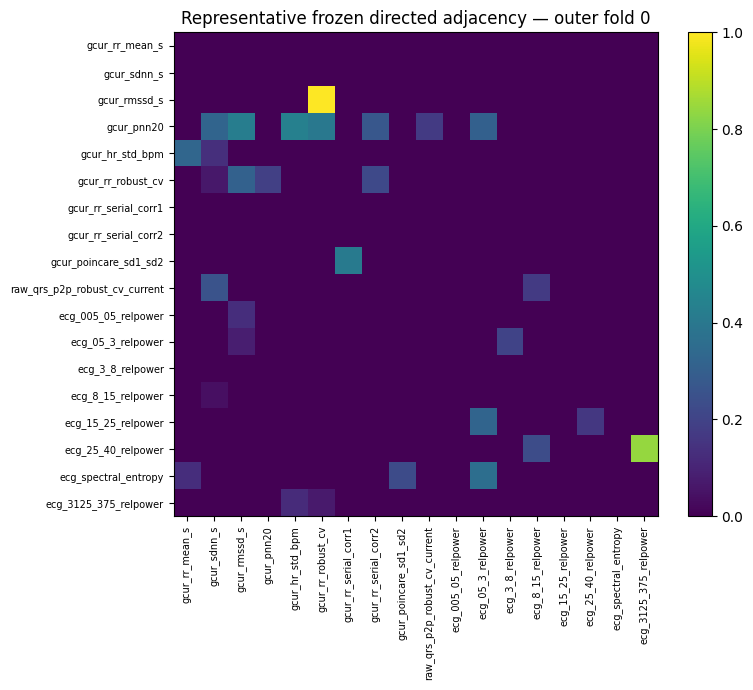

,outer_fold,context_len,adjacency_view,selected_mode,supervised_epochs,threshold_mcc,inner_oof_score
0,0,5,binary,ssl_tp_vicreg,12,0.209,0.838271
1,1,27,effect,subject_adv,12,0.496,0.862389
2,2,31,effect,ssl_tp_vicreg,12,0.381,0.885967
3,3,11,stability,erm,12,0.620,0.841369
4,4,27,effect,ssl_tp_vicreg_subject_adv,12,0.593,0.860263


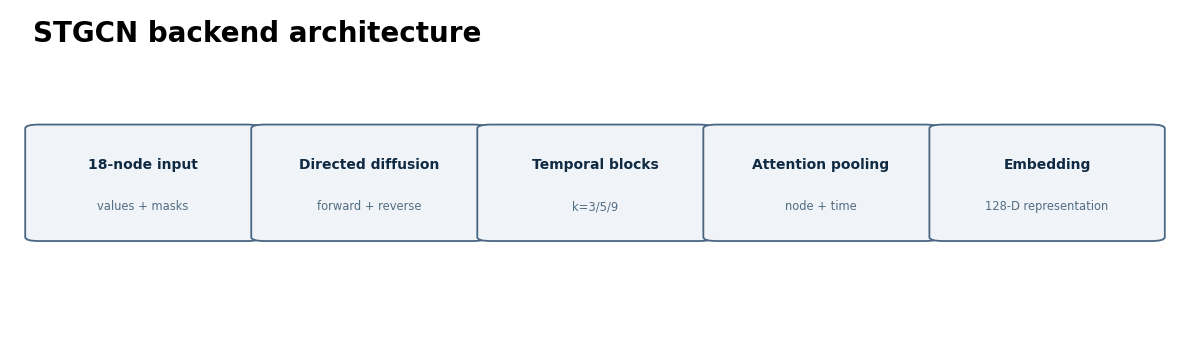

,Field,Value
0,created_utc,2026-08-15T11:37:35.969468+00:00
1,granger_candidates,[18 items]
2,graphs,[25 items]
3,implementation_revision,15B-v1_5-strictnested-commonSupportBIC15-selec...
4,implementation_sha256,61abc3773eb1de900515657e1e9f9a628dae81ee6a2cfd...
...,...,...
107,stationarity_catalog.sha256,7e5dec0fa345b52f977f9569f7d0fd83ae47f109484b02...
108,stationarity_catalog.state_path,/content/drive/MyDrive/QML_SleepNet/outputs/gu...
109,stationarity_catalog.state_sha256,f302cc50700b51af869902caafefb8cd628acb0366147d...
110,summary.path,/content/drive/MyDrive/QML_SleepNet/outputs/gu...


,Field,Value
0,created_utc,2026-08-27T12:40:11.155468+00:00
1,freeze_core_sha256,b6c4aa0596049e33ba8aeb15ffe4f5c4f539a07ac1ad13...
2,implementation_sha256,08821e4d92fe4407c811b4bb55ca12e9226ffe42e5b056...
3,method_spec_sha256,2118142b4c1c54be627ca6ee37c29b57093256568888d0...
4,outer_prediction_bundles,[5 items]
5,schema,15C_all_outer_predictions_freeze_v1
6,source_15B_manifest_core_sha256,efee9a4086164d3f93f87ab93e91b7e7f00d1adad141ee...


,outer_fold,inner_fold,graph_id,seed,fixed_epochs,path,sha256,n_rows,embedding_dim
0,0,0,outer_0_inner_0,29,12,/content/drive/MyDrive/QML_SleepNet/outputs/gu...,72d5e21d0b408a7dd231727e6eec56dd3d033368ee0b03...,6893,128
1,0,1,outer_0_inner_1,29,12,/content/drive/MyDrive/QML_SleepNet/outputs/gu...,5099cbec38a94bff23d10fd1beaec7e3d813ff906fa536...,6860,128
2,0,2,outer_0_inner_2,29,12,/content/drive/MyDrive/QML_SleepNet/outputs/gu...,965357c9fd3cd1bdd5823cf4ad95d8274738b3e0291856...,6855,128
3,0,3,outer_0_inner_3,29,12,/content/drive/MyDrive/QML_SleepNet/outputs/gu...,a5d5056584817d2bc25708a31b3628f6508b12c3719beb...,6847,128


,Field,Value
0,backup_core_sha256,251268ee9b72085246e2afa41fa73f547c21d05c0de07b...
1,choice_core_sha256,e388950a9436b1aa6a917cc2d3b104f3b2f10fc15120c1...
2,created_utc,2026-08-27T09:43:49.797160+00:00
3,files,[45 items]
4,implementation_sha256,08821e4d92fe4407c811b4bb55ca12e9226ffe42e5b056...
5,method_spec_sha256,2118142b4c1c54be627ca6ee37c29b57093256568888d0...
6,outer_fold,0
7,schema,15C_critical_artifact_redundancy_v2


,Field,Value
0,artifact_core_sha256,2722fb2b8341b543b319e69b27602ba060074b43574d24...
1,contains_embeddings,False
2,identity_sha256,aae987c8c6633d271f840f7f7b8d0d2abb32c6359bdaee...
3,model_sha256,12bdea9339d9bcfb07c35ed0a2c4b20ff923a853a23b5e...
4,n_rows,6816
5,prediction_sha256,ddaad9b5c9f5f30492bce6e66cb540cec5ffa9fa1a273d...
6,schema,15C_outer_seed_prediction_v1


...

,Field,Value
0,artifact_core_sha256,97a4d0c9ae202e05a5fc384d3876c0740a551c02a2354f...
1,contains_embeddings,False
2,identity_sha256,6863f526a9916482c45ed578ab3b9c813f40ef3bf35857...
3,model_sha256,ade3f7a53cb9ed63d456ff9b03407082cfdc96624217bc...
4,n_rows,6825
5,prediction_sha256,ac46161c4304e6c1551c2cbc9a0ebb4b74c22576cf7300...
6,schema,15C_outer_seed_prediction_v1


,Field,Value
0,artifact_core_sha256,5579a178a959a8d0bd024f071b8477d3b8281cea77b523...
1,best_epoch,3
2,best_score,0.8576231596794756
3,identity_sha256,e819dff272cf0f7ef0bb49a9f1885b3df129112589c2ae...
4,n_rows,6893
5,payload_sha256,8acced2a9002355ea2076ba17a1fe36b397dc0415ab722...
6,schema,15C_prediction_artifact_v1
7,tag,full_inner_best


,Field,Value
0,artifact_core_sha256,c7041d841f923c8ce9f58c9b2ee81b104c02764e05d7d3...
1,best_epoch,4
2,best_score,0.8667812351972719
3,identity_sha256,701c0f40bbda836a9a04f2ef46585f9814bdec76f62ac0...
4,n_rows,6893
5,payload_sha256,63b0573c788e19e3ab1b92a1f5f74092adfcf73b1b48cf...
6,schema,15C_prediction_artifact_v1
7,tag,full_inner_best


,Field,Value
0,artifact_core_sha256,dc1280007fa9871c79321eb722ae83e78331bebd1d36f4...
1,best_epoch,3
2,best_score,0.8581586958051878
3,identity_sha256,89dae473b31aba0de277de08ebbb1b9548d194bc2fddcb...
4,n_rows,6893
5,payload_sha256,b107a748cc7cb76d10c5177ea6d6acfffc335012bca859...
6,schema,15C_prediction_artifact_v1
7,tag,full_inner_best


,Field,Value
0,artifact_core_sha256,9628d15d8c74b1b7bdca53f083b1661a5df4229b905910...
1,best_epoch,21
2,best_score,0.8198398141758612
3,identity_sha256,214b681b605e6c6b0cfa41474a33fbc5193089fd21cd39...
4,n_rows,6893
5,payload_sha256,1c5c25e73406c4f83d1af9b8a1b51b5edfdbbaa81d55e1...
6,schema,15C_prediction_artifact_v1
7,tag,full_inner_best


In [6]:
stage_banner(4, "Spatio-Temporal Modeling", "Directed graph construction and STGCN representation learning")

architecture=pd.DataFrame([
    ["Input variables","18 causal-safe physiological variables"],
    ["Observation representation","value + finite-observation mask"],
    ["Node identity embedding","16-D learned"],
    ["Relative-time embedding","8-D learned"],
    ["Hidden width","64"],
    ["Residual spatio-temporal blocks","3"],
    ["Temporal kernels","3 / 5 / 9"],
    ["Dilations","1 / 2 / 4"],
    ["Graph operator","separate forward / reverse diffusion, order 2"],
    ["Activation / normalization","GELU + LayerNorm"],
    ["Pooling","observation-aware node + temporal attention"],
    ["Canonical embedding","128-D"],
],columns=["Architecture component","Implementation"])
display(architecture)
register_table("04_stgcn_architecture.csv", architecture)

# Render one actual frozen directed graph when available.
graph_manifest=safe_json(B15_MANIFEST,{}) or {}
graphs=graph_manifest.get("graphs",[])
row=next((g for g in graphs if g.get("graph_id")=="outer_0_final"),None)
if row:
    freeze=safe_json(Path(row.get("graph_freeze_path","")),{}) or {}
    arts=freeze.get("artifacts",{})
    node_path=Path(arts.get("node_order",{}).get("path",""))
    adj_path=Path(arts.get("adj_canonical",{}).get("path",""))
    node_obj=safe_json(node_path,{}) or {}
    nodes=[x.get("feature",str(i)) for i,x in enumerate(node_obj.get("nodes",[]))]
    if adj_path.is_file():
        A=np.load(adj_path)
        if A.ndim==2:
            if len(nodes)!=A.shape[0]:
                nodes=[str(i) for i in range(A.shape[0])]
            fig,ax=plt.subplots(figsize=(8,7))
            im=ax.imshow(A,interpolation="nearest")
            ax.set_xticks(range(len(nodes))); ax.set_xticklabels(nodes,rotation=90,fontsize=7)
            ax.set_yticks(range(len(nodes))); ax.set_yticklabels(nodes,fontsize=7)
            ax.set_title("Representative frozen directed adjacency — outer fold 0")
            fig.colorbar(im,ax=ax,fraction=.046)
            fig.tight_layout()
            register_visual("04_directed_adjacency_outer0.png")
            plt.show(); plt.close(fig)

# Fold-specific selected STGCN receipts.
choices=[]
for outer in range(5):
    ch=safe_json(C15_ROOT/f"selection/outer_{outer}/outer_choice_freeze.json",{}) or {}
    core=ch.get("selected_core",{})
    choices.append({
        "outer_fold":outer,
        "context_len":core.get("context_len"),
        "adjacency_view":core.get("adj_view"),
        "selected_mode":ch.get("selected_mode"),
        "supervised_epochs":ch.get("fixed_supervised_epochs"),
        "threshold_mcc":ch.get("threshold_mcc"),
        "inner_oof_score":ch.get("five_seed_fixed_budget_inner_oof_selection_score"),
    })
choice_df=pd.DataFrame(choices)
display(choice_df)
register_table("04_stgcn_fold_configuration.csv", choice_df)

draw_flow([
    ("18-node input","values + masks"),
    ("Directed diffusion","forward + reverse"),
    ("Temporal blocks","k=3/5/9"),
    ("Attention pooling","node + time"),
    ("Embedding","128-D representation"),
], "STGCN backend architecture", "04_stgcn_backend_flow.png")

display_source_artifact(B15_MANIFEST, "Directed graph-bank manifest")
display_artifact_gallery(
    C15_ROOT,
    "Spatio-temporal modeling — frozen execution evidence",
    recursive=True,
    table_mode="summary",
    max_files=40
)


## Stage 05

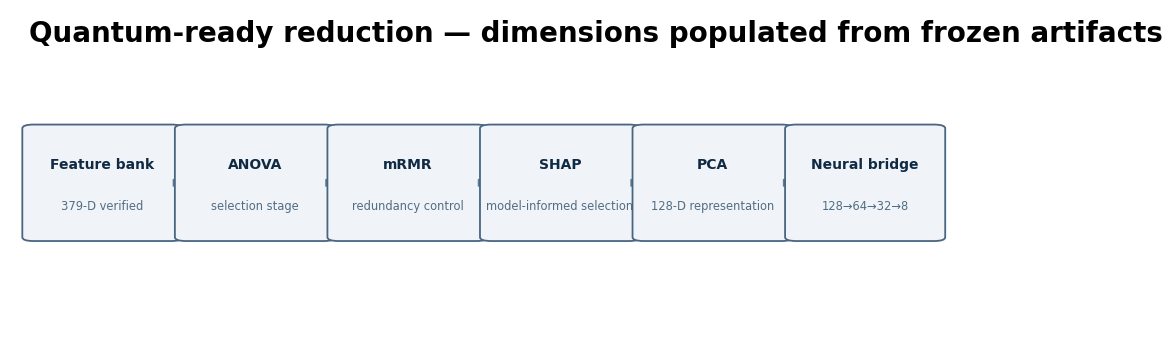

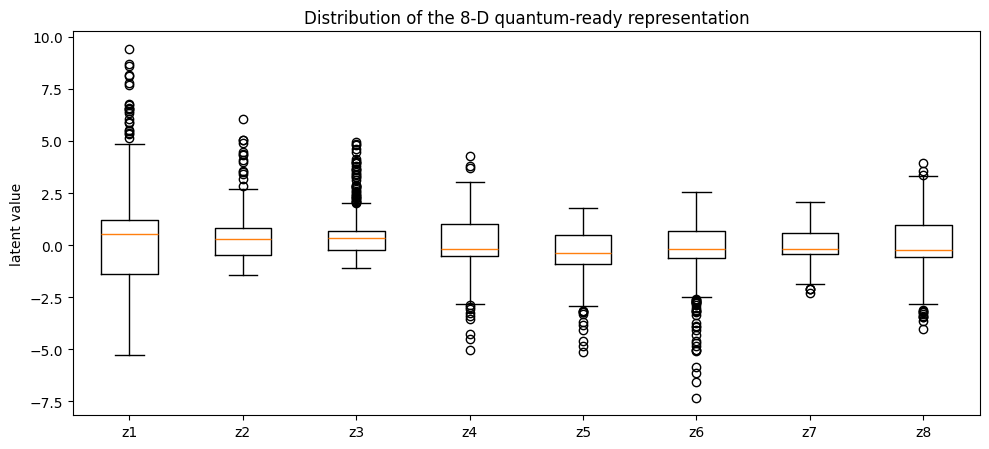

,feature_id,feature_name
0,317,cpcc_classic_cpc_top2_low_high_ratio
1,311,cpcc_classic_cpc_low
2,331,cpcp_classic_cpc_top2_low_high_ratio
3,115,cwtc_edr_cwt_apnea_low
4,123,cwtc_edr_cwt_ridge_iqr_hz
5,95,cvhrc_cvhr_lowband_power
6,325,cpcp_classic_cpc_low
7,366,ecg_mad
8,209,lsp_ls_peak_hz
9,112,cwtc_edr_cwt_vlf


,Item,Implementation
0,Selection sequence,ANOVA → mRMR → SHAP-guided selection → PCA
1,PCA target,128-D
2,Bridge encoder,128 → 64 → 32 → 8
3,Optimization,AdamW + warm-up + cosine schedule
4,Development protocol,duplicate-safe five-fold record-level CV
5,Official x labels during representation learning,not used


,Array,Shape,Dtype,Finite
0,learn_uids,"(17023,)",<U128,
1,test_uids,"(17248,)",<U128,
2,y_learn,"(17023,)",int8,100.0%
3,Z128_learn,"(17023, 128)",float32,100.0%
4,Z128_test,"(17248, 128)",float32,100.0%
5,Z8_learn,"(17023, 8)",float32,100.0%
6,Z8_test,"(17248, 8)",float32,100.0%


,feature_id,feature_name
0,317,cpcc_classic_cpc_top2_low_high_ratio
1,311,cpcc_classic_cpc_low
2,331,cpcp_classic_cpc_top2_low_high_ratio
3,115,cwtc_edr_cwt_apnea_low
4,123,cwtc_edr_cwt_ridge_iqr_hz
...,...,...
171,131,cwtc_pcaedr_cwt_log_apnea_low
172,399,guide_db4_D1_energy
173,152,cplc_cpc_peak_hz
174,111,cwtc_rri_cwt_ridge_iqr_hz


,Field,Value
0,pipeline,QML-SleepNet exact-guide metric-max
1,stage03.operations,"[""ANOVA F-test"", ""mRMR"", ""SHAP-guided selectio..."
2,stage03.selected_config.name,S176
3,stage03.selected_config.anova_k,360
4,stage03.selected_config.mrmr_k,240
5,stage03.selected_config.shap_k,176
6,stage03.pca_output_dim,128
7,stage03.pca128_explained_variance,0.9941517114639282
8,stage04.encoder,128->64->32->8
9,stage04.batchnorm,True


,uid,record_name,y,bridge_oof_probability
0,a01:0,a01,0,0.146253
1,a01:1,a01,0,0.137550
2,a01:2,a01,0,0.206750
3,a01:3,a01,0,0.178031
4,a01:4,a01,0,0.206357
5,a01:5,a01,0,0.184587
6,a01:6,a01,0,0.137039
7,a01:7,a01,0,0.075427
8,a01:8,a01,0,0.217813
9,a01:9,a01,0,0.197047


,dropout,fold,accuracy,balanced_accuracy,precision,recall,f1,auroc,auprc,mcc
0,0.3,0,0.927657,0.913525,0.904225,0.872283,0.887967,0.976260,0.959380,0.834868
1,0.3,1,0.904181,0.901809,0.909695,0.875959,0.892508,0.960959,0.962668,0.806599
2,0.3,2,0.855372,0.841472,0.847596,0.774386,0.809339,0.921602,0.889824,0.695056
3,0.3,3,0.731679,0.660893,0.575688,0.477640,0.522101,0.751287,0.597971,0.340662
4,0.3,4,0.792780,0.763201,0.915084,0.565217,0.698805,0.880208,0.870786,0.591340
5,0.4,0,0.933016,0.919134,0.914232,0.878623,0.896074,0.978833,0.962036,0.847048
6,0.4,1,0.894599,0.893893,0.882241,0.886189,0.884211,0.951509,0.952510,0.787495
7,0.4,2,0.856553,0.841811,0.853256,0.770663,0.809859,0.922196,0.888921,0.697493
8,0.4,3,0.739270,0.670611,0.589977,0.492864,0.537066,0.758540,0.624324,0.360426
9,0.4,4,0.789551,0.761827,0.890192,0.576259,0.699623,0.865674,0.853449,0.579594


,fold,train_rows,val_rows,train_records,val_records,train_positive_rate,val_positive_rate
0,0,13664,3359,28,7,0.395711,0.328669
1,1,13579,3444,28,7,0.364313,0.454123
2,2,13635,3388,28,7,0.379025,0.396399
3,3,13598,3425,28,7,0.401530,0.306861
4,4,13616,3407,28,7,0.371769,0.425301


,config,fold,explained_128,accuracy,balanced_accuracy,precision,recall,f1,auroc,auprc,mcc
0,S160,0,0.997893,0.914856,0.889427,0.916497,0.815217,0.862895,0.972491,0.953050,0.804347
1,S160,1,0.997831,0.890825,0.888877,0.889253,0.867647,0.878317,0.948289,0.947928,0.779539
2,S160,2,0.997524,0.863046,0.847573,0.867168,0.772897,0.817323,0.920167,0.891849,0.711365
3,S160,3,0.997974,0.678248,0.618108,0.475073,0.462417,0.468660,0.709434,0.438802,0.238028
4,S160,4,0.997434,0.808629,0.784077,0.898899,0.619738,0.733660,0.903448,0.883127,0.617015
5,S176,0,0.995763,0.933016,0.919134,0.914232,0.878623,0.896074,0.978833,0.962036,0.847048
6,S176,1,0.993377,0.894599,0.893893,0.882241,0.886189,0.884211,0.951509,0.952510,0.787495
7,S176,2,0.995150,0.856553,0.841811,0.853256,0.770663,0.809859,0.922196,0.888921,0.697493
8,S176,3,0.995926,0.739270,0.670611,0.589977,0.492864,0.537066,0.758540,0.624324,0.360426
9,S176,4,0.995396,0.789551,0.761827,0.890192,0.576259,0.699623,0.865674,0.853449,0.579594


,fold,path,train_rows,val_rows,selector,dropout
0,0,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,13664,3359,S176,0.4
1,1,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,13579,3444,S176,0.4
2,2,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,13635,3388,S176,0.4
3,3,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,13598,3425,S176,0.4
4,4,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,13616,3407,S176,0.4


In [7]:
stage_banner(5, "Quantum-Ready Feature Reduction", "Leakage-controlled selection and compact 8-D representation")

if not REGISTRY_DF.loc[REGISTRY_DF["Stage"].eq(5),"Verified"].item():
    raise RuntimeError("Stage 05 artifact verification failed.")
_feature_dim = feature_shape[1]
_bridge_dim = bridge_learn.shape[1]
draw_flow([
    ("Feature bank",f"{_feature_dim}-D verified"),
    ("ANOVA","selection stage"),
    ("mRMR","redundancy control"),
    ("SHAP","model-informed selection"),
    ("PCA","128-D representation"),
    ("Neural bridge",f"128→64→32→{_bridge_dim}"),
], "Quantum-ready reduction — dimensions populated from frozen artifacts", "05_quantum_ready_reduction")

bz=safe_npz(BRIDGE_NPZ)
if not bz:
    # fall back to project-wide lookup
    alt=first_file("quantum_ready_8d.npz",[METRIC_ROOT])
    bz=safe_npz(alt) if alt else {}

learn_key=next((k for k in ["z8_learn","learn_8d","learn","Z8_LEARN"] if k in bz),None)
test_key=next((k for k in ["z8_test","test_8d","test","Z8_TEST"] if k in bz),None)
# Some files expose explicit names.
if learn_key is None:
    learn_key=next((k for k in bz if "learn" in k.lower() and np.asarray(bz[k]).ndim==2 and np.asarray(bz[k]).shape[1]==8),None)
if test_key is None:
    test_key=next((k for k in bz if "test" in k.lower() and np.asarray(bz[k]).ndim==2 and np.asarray(bz[k]).shape[1]==8),None)

if learn_key and test_key:
    ZL=np.asarray(bz[learn_key]); ZT=np.asarray(bz[test_key])
    metric_cards([
        ("DEVELOPMENT", f"{ZL.shape[0]:,} × {ZL.shape[1]}", "quantum-ready representation"),
        ("OFFICIAL x", f"{ZT.shape[0]:,} × {ZT.shape[1]}", "generated without x labels"),
        ("BRIDGE", "128→64→32→8", "BatchNorm + ReLU + dropout"),
    ])
    fig,ax=plt.subplots(figsize=(10,4.6))
    ax.boxplot([ZL[:,i] for i in range(8)],labels=[f"z{i+1}" for i in range(8)])
    ax.set_title("Distribution of the 8-D quantum-ready representation")
    ax.set_ylabel("latent value")
    fig.tight_layout()
    register_visual("05_quantum_ready_8d_distribution.png")
    plt.show(); plt.close(fig)

selected = pd.read_csv(BRIDGE_FEATURES) if BRIDGE_FEATURES.is_file() else pd.DataFrame()
if len(selected):
    display(selected.head(20))
    register_table("05_selected_feature_inventory.csv", selected)

receipt=pd.DataFrame([
    ["Selection sequence","ANOVA → mRMR → SHAP-guided selection → PCA"],
    ["PCA target","128-D"],
    ["Bridge encoder","128 → 64 → 32 → 8"],
    ["Optimization","AdamW + warm-up + cosine schedule"],
    ["Development protocol","duplicate-safe five-fold record-level CV"],
    ["Official x labels during representation learning","not used"],
],columns=["Item","Implementation"])
display(receipt)
register_table("05_quantum_ready_backend_receipt.csv", receipt)

display_source_artifact(BRIDGE_NPZ, "Quantum-ready 8-D frozen arrays")
display_source_artifact(BRIDGE_FEATURES, "Selected feature inventory")
display_artifact_gallery(
    BRIDGE_ROOT.parent,
    "Quantum-ready reduction — frozen summary evidence",
    recursive=True,
    table_mode="summary",
    max_files=30
)


## Stage 06

,branch,mean_auroc,worst_fold_auroc,mean_auprc,mean_group_macro_auroc
0,ANISOTROPIC_ANGLE_QSVC,0.878269,0.862332,0.817003,0.815342
1,VQC_REALAMPLITUDES_SPSA,0.876536,0.848437,0.814980,0.809278
2,CLASSICAL_6D_RBF_PROXY,0.873848,0.856473,0.816997,0.808671


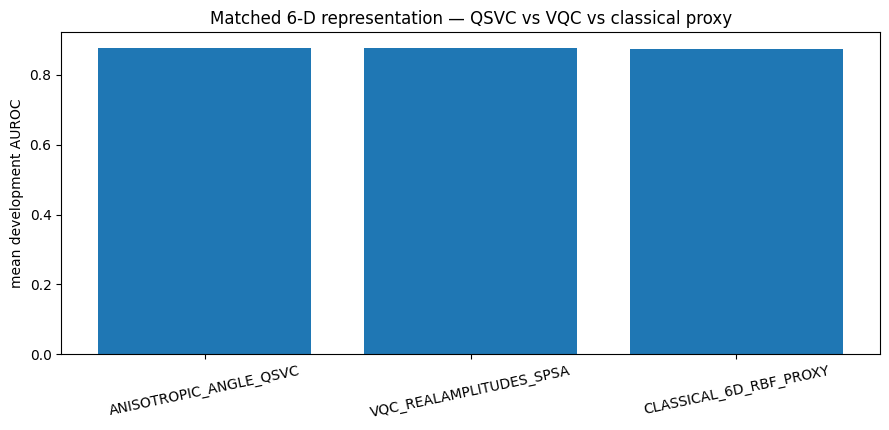

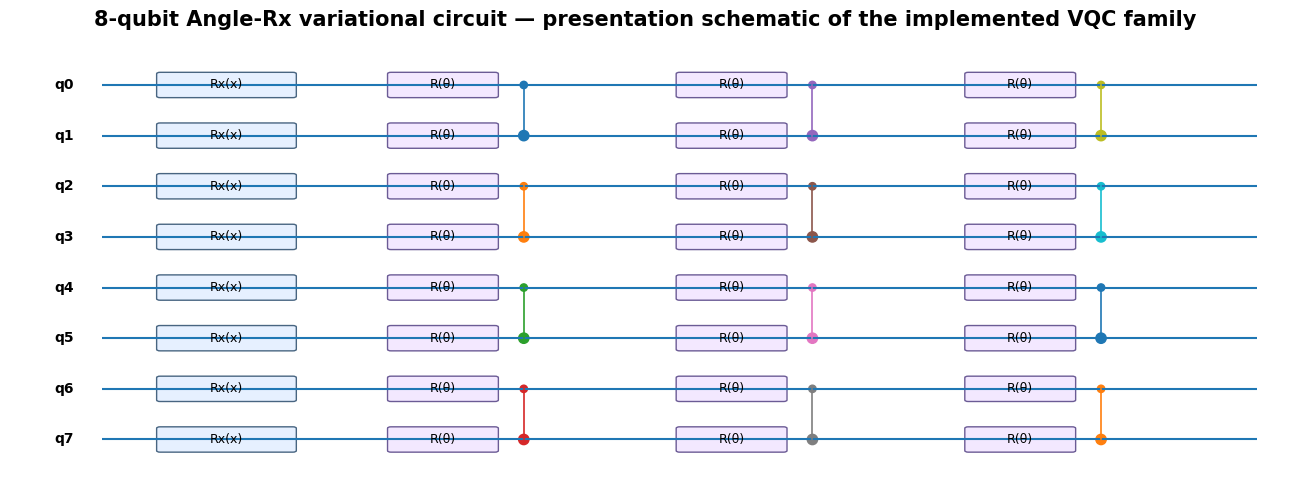

,Quantum component,Evidence
0,Primary quantum-ready dimension,8
1,VQC encoding,Angle-Rx
2,Implemented VQC depth,4
3,Variational parameters,96
4,Quantum-kernel comparator,QSVC / fidelity-kernel family
5,Additional representation,Quantum Transformer latent 64-D
6,Selection evidence,strict development folds only
7,Quantum-advantage claim,not asserted


,Field,Value
0,anisotropic_angle_identity_max_abs,7.771561172376096e-16
1,best_quantum_branch,ANISOTROPIC_ANGLE_QSVC
2,best_quantum_mean_auroc,0.8782694873910495
3,classical_6d_proxy_mean_auroc,0.8738476611772505
4,development_threshold_balanced_accuracy.accuracy,0.7951557093425605
5,development_threshold_balanced_accuracy.balanc...,0.7921894319359962
6,development_threshold_balanced_accuracy.f1,0.7439446366782007
7,development_threshold_balanced_accuracy.precision,0.7113626469307793
8,development_threshold_balanced_accuracy.recall,0.7796545471896174
9,development_threshold_balanced_accuracy.threshold,-0.70902629209545


,config_id,boost,scale_pi,C,class_weight,mean_auroc,worst_screen_auroc,mean_auprc,mean_group_macro_auroc
0,9,3.0,0.18,0.100,none,0.877973,0.862551,0.825109,0.775359
1,7,2.5,0.24,0.100,none,0.877053,0.855680,0.823843,0.782075
2,10,3.0,0.24,0.100,none,0.874757,0.846866,0.822144,0.787541
3,4,2.0,0.24,0.100,none,0.874734,0.862549,0.820891,0.778235
4,6,2.5,0.18,0.100,none,0.874040,0.867740,0.821463,0.770016
5,7,2.5,0.24,0.030,none,0.872484,0.853676,0.817062,0.772353
6,9,3.0,0.18,0.300,none,0.871638,0.847337,0.824420,0.790212
7,1,1.5,0.24,0.100,none,0.871029,0.863049,0.820377,0.778526
8,7,2.5,0.24,0.300,none,0.870765,0.844049,0.821000,0.790812
9,4,2.0,0.24,0.300,none,0.870752,0.851203,0.821554,0.789666


,weight_name,boosted_coordinate,class_weight,mean_auroc,worst_screen_auroc,mean_auprc,mean_group_macro_auroc
0,boost_pc4,3,none,0.869005,0.867436,0.816994,0.779398
1,boost_pc4,3,balanced,0.866631,0.866073,0.816848,0.780640
2,boost_pc6,5,balanced,0.864079,0.856400,0.814566,0.784493
3,boost_pc6,5,none,0.862869,0.858610,0.813607,0.775519
4,isotropic,-1,none,0.859405,0.857999,0.818910,0.771555
5,boost_pc5,4,none,0.855921,0.855417,0.816177,0.756177
6,boost_pc3,2,none,0.855319,0.848381,0.805936,0.777916
7,isotropic,-1,balanced,0.855255,0.853097,0.816489,0.774085
8,boost_pc3,2,balanced,0.854704,0.848023,0.805947,0.772489
9,boost_pc5,4,balanced,0.853751,0.853320,0.816775,0.766716


,fold,rank_id,boosted_coordinate,boost,scale_pi,C,class_weight,train_cap,auroc,auprc,balanced_accuracy,group_macro_auroc,n_support_total
0,0,0,3,3.0,0.18,0.1,none,2048,0.883865,0.843898,0.709661,0.809625,802
1,0,1,3,2.5,0.24,0.1,none,2048,0.891791,0.850818,0.727063,0.822646,774
2,0,2,3,3.0,0.24,0.1,none,2048,0.895148,0.854227,0.739370,0.823748,789
3,1,0,3,3.0,0.18,0.1,none,2048,0.881037,0.805076,0.787393,0.828967,712
4,1,1,3,2.5,0.24,0.1,none,2048,0.882222,0.807955,0.785580,0.825639,701
5,1,2,3,3.0,0.24,0.1,none,2048,0.883824,0.805551,0.777274,0.810643,700
6,2,0,3,3.0,0.18,0.1,none,2048,0.885844,0.804428,0.753308,0.853621,659
7,2,1,3,2.5,0.24,0.1,none,2048,0.873457,0.796258,0.737238,0.848795,633
8,2,2,3,3.0,0.24,0.1,none,2048,0.858630,0.787781,0.741341,0.839514,652
9,3,0,3,3.0,0.18,0.1,none,2048,0.862332,0.814611,0.746191,0.769153,644


,rank_id,boosted_coordinate,boost,scale_pi,C,class_weight,mean_auroc,worst_fold_auroc,std_auroc,mean_auprc,mean_balanced_accuracy,mean_group_macro_auroc
0,0,3,3.0,0.18,0.1,none,0.878269,0.862332,0.010806,0.817003,0.749138,0.815342
1,1,3,2.5,0.24,0.1,none,0.876477,0.858436,0.014167,0.816271,0.747637,0.815776
2,2,3,3.0,0.24,0.1,none,0.872732,0.853327,0.020007,0.813307,0.749605,0.809326


,fold,rank_id,boosted_coordinate,boost,scale_pi,C,class_weight,train_cap,auroc,auprc,balanced_accuracy,group_macro_auroc,n_support_total
0,0,0,3,3.0,0.18,0.1,none,2048,0.883865,0.843898,0.709661,0.809625,802
1,1,0,3,3.0,0.18,0.1,none,2048,0.881037,0.805076,0.787393,0.828967,712
2,2,0,3,3.0,0.18,0.1,none,2048,0.885844,0.804428,0.753308,0.853621,659
3,3,0,3,3.0,0.18,0.1,none,2048,0.862332,0.814611,0.746191,0.769153,644


,branch,mean_auroc,worst_fold_auroc,mean_auprc,mean_group_macro_auroc
0,ANISOTROPIC_ANGLE_QSVC,0.878269,0.862332,0.817003,0.815342
1,VQC_REALAMPLITUDES_SPSA,0.876536,0.848437,0.814980,0.809278
2,CLASSICAL_6D_RBF_PROXY,0.873848,0.856473,0.816997,0.808671


,fold,auroc,auprc,balanced_accuracy,group_macro_auroc,model_saved
0,0,0.902240,0.867706,0.712507,0.811070,True
1,1,0.884191,0.790509,0.742281,0.801923,True
2,2,0.871276,0.806923,0.714397,0.855587,True
3,3,0.848437,0.794781,0.705499,0.768532,True


In [8]:
stage_banner(6, "Quantum Machine Learning", "VQC, quantum-kernel QSVC and Quantum Transformer evidence")

qcomp_path=first_file("stage04_quantum_comparison.csv",[METRIC_ROOT],prefer=("depth4","exact"))
qcomp=pd.read_csv(qcomp_path) if qcomp_path and qcomp_path.is_file() else pd.DataFrame()

# Matched 6-D quantum/classical comparison from completed final evaluation package.
e2_path=E2_ROOT/"stage15e2_r3_final_comparison.csv"
e2=pd.read_csv(e2_path) if e2_path.is_file() else pd.DataFrame()

if len(qcomp):
    display(qcomp)
    register_table("06_quantum_branch_comparison.csv", qcomp)
    metric_col="accuracy" if "accuracy" in qcomp.columns else next((c for c in qcomp.columns if "auroc" in c.lower()),None)
    if metric_col:
        fig,ax=plt.subplots(figsize=(9,4.6))
        ax.bar(qcomp["branch"].astype(str),qcomp[metric_col].astype(float))
        ax.set_ylabel(metric_col.replace("_"," ").title())
        ax.set_title("Quantum-module development comparison")
        ax.tick_params(axis="x",rotation=15)
        fig.tight_layout()
        register_visual("06_quantum_module_comparison.png")
        plt.show(); plt.close(fig)

if len(e2):
    display(e2)
    register_table("06_vqc_qsvc_matched_comparison.csv", e2)
    fig,ax=plt.subplots(figsize=(9,4.4))
    ax.bar(e2["branch"].astype(str),e2["mean_auroc"].astype(float))
    ax.set_ylabel("mean development AUROC")
    ax.set_title("Matched 6-D representation — QSVC vs VQC vs classical proxy")
    ax.tick_params(axis="x",rotation=12)
    fig.tight_layout()
    register_visual("06_vqc_qsvc_classical_6d.png")
    plt.show(); plt.close(fig)

# Compact circuit-level schematic.
fig,ax=plt.subplots(figsize=(13,5))
ax.axis("off")
nq=8
for q in range(nq):
    y=nq-1-q
    ax.hlines(y,0,10)
    ax.text(-.25,y,f"q{q}",ha="right",va="center",fontweight="bold")
    ax.add_patch(FancyBboxPatch((.5,y-.22),1.15,.44,boxstyle="round,pad=.03",
                                facecolor="#E6F0FF",edgecolor="#486581"))
    ax.text(1.075,y,"Rx(x)",ha="center",va="center",fontsize=9)
    for layer,x0 in enumerate([2.5,5.0,7.5]):
        ax.add_patch(FancyBboxPatch((x0,y-.22),.9,.44,boxstyle="round,pad=.03",
                                    facecolor="#F3E8FF",edgecolor="#6B5B95"))
        ax.text(x0+.45,y,"R(θ)",ha="center",va="center",fontsize=9)
for x0 in [3.65,6.15,8.65]:
    for q in range(0,nq-1,2):
        y1=nq-1-q; y2=nq-2-q
        ax.plot([x0,x0],[y2,y1],linewidth=1.2)
        ax.scatter([x0,x0],[y1,y2],s=[28,55],marker="o")
ax.set_xlim(-.8,10.2); ax.set_ylim(-.8,nq)
ax.set_title("8-qubit Angle-Rx variational circuit — presentation schematic of the implemented VQC family",
             fontsize=15,fontweight="bold")
fig.tight_layout()
register_visual("06_vqc_circuit_schematic.png")
plt.show(); plt.close(fig)

qcfg=pd.DataFrame([
    ["Primary quantum-ready dimension","8"],
    ["VQC encoding","Angle-Rx"],
    ["Implemented VQC depth","4"],
    ["Variational parameters","96"],
    ["Quantum-kernel comparator","QSVC / fidelity-kernel family"],
    ["Additional representation","Quantum Transformer latent 64-D"],
    ["Selection evidence","strict development folds only"],
    ["Quantum-advantage claim","not asserted"],
],columns=["Quantum component","Evidence"])
display(qcfg)
register_table("06_quantum_backend_configuration.csv", qcfg)

if qcomp_path:
    display_artifact_gallery(
        Path(qcomp_path).parent,
        "Quantum machine-learning — complete frozen summary evidence",
        recursive=True,
        table_mode="summary",
        max_files=45
    )
display_artifact_gallery(
    E2_ROOT,
    "Matched VQC / QSVC / classical quantum-parity evidence",
    recursive=True,
    table_mode="summary",
    max_files=35
)


## Stage 07

,System,Accuracy,Balanced Accuracy,F1,MCC,AUROC,AUPRC
0,Stage15A physiology CatBoost + temperature + HMM,0.910192,0.909747,0.884721,0.811954,0.969663,0.950449
1,Canonical QML parent,0.901148,0.900116,0.873093,0.792908,0.962067,0.942772


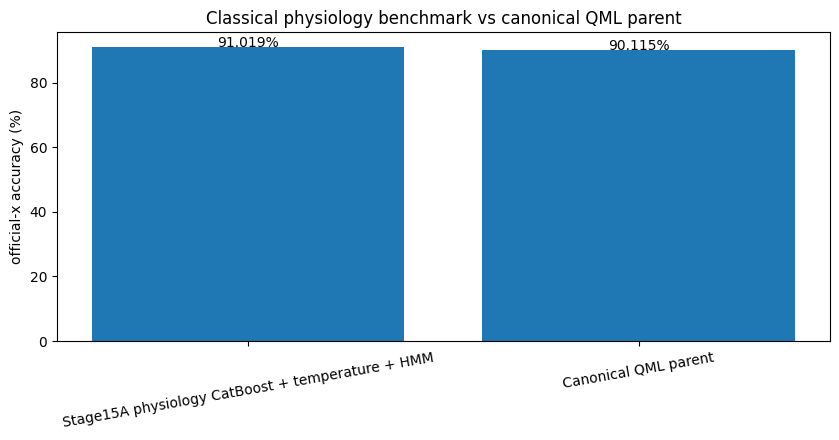

,Classical model family,Backend,Role
0,CatBoost,gradient boosting on decision trees,selected physiology parent
1,LightGBM,gradient-boosted trees,development comparator
2,XGBoost,gradient-boosted trees,development comparator
3,Random Forest,bagged decision trees,development baseline
4,Extra Trees,randomized tree ensemble,development baseline
5,Logistic Regression,linear probabilistic classifier,development baseline


,Field,Value
0,accuracy,0.9101924860853432
1,auprc,0.9504488087058468
2,auroc,0.9696634702240798
3,balanced_accuracy,0.9097468968032248
4,brier,0.07958532557392657
5,f1,0.8847212919550494
6,fn,603
7,fp,946
8,mcc,0.8119540586167897
9,n,17248


,uid,y_true,hmm_apnea_posterior,prediction
0,x01:0,0,0.000053,0
1,x01:1,0,0.000061,0
2,x01:2,0,0.000063,0
3,x01:3,0,0.000062,0
4,x01:4,0,0.000061,0
5,x01:5,0,0.000062,0
6,x01:6,0,0.000063,0
7,x01:7,0,0.000069,0
8,x01:8,0,0.000242,0
9,x01:9,0,0.000444,0


,Field,Value
0,all70_performance_rankings_imported,False
1,cfg_load_test_set_labels_called,False
2,class_prior,"[0.617517476355519, 0.382482523644481]"
3,dev35_global_metrics.accuracy,0.8675909064207249
4,dev35_global_metrics.auprc,0.9204300848864629
...,...,...
67,stage15a_target_index_sha256,bdd317fc5ee40eaa740c57de2cc6f3f39b85e357071f3b...
68,stage15a_target_index_y_loaded,False
69,status,DEV35_STAGE15A_PHYSIO_BOOSTING_FROZEN_BEFORE_P...
70,temperature,0.9864240579773519


,Field,Value
0,beats_reference_accuracy,True
1,challenger.accuracy,0.9101924860853432
2,challenger.auprc,0.9504488087058468
3,challenger.auroc,0.9696634702240798
4,challenger.balanced_accuracy,0.9097468968032248
5,challenger.brier,0.07958532557392657
6,challenger.f1,0.8847212919550494
7,challenger.fn,603
8,challenger.fp,946
9,challenger.mcc,0.8119540586167897


...

,Field,Value
0,bootstrap_unit,strict subject/source group
1,metrics.accuracy.bootstrap_mean,0.8675820626539475
2,metrics.accuracy.ci95,"[0.798319193500991, 0.9256776713192947]"
3,metrics.accuracy.point,0.8675909064207249
4,metrics.auprc.bootstrap_mean,0.917510675043528
5,metrics.auprc.ci95,"[0.858411269514466, 0.9588772725006662]"
6,metrics.auprc.point,0.9204300848864629
7,metrics.auroc.bootstrap_mean,0.9413249818042406
8,metrics.auroc.ci95,"[0.9107604776069778, 0.9696453106244526]"
9,metrics.auroc.point,0.9417415195032316


,outer_fold,rule,members,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,mcc,auroc,auprc,brier,nll,tn,fp,fn,tp
0,0,SINGLE[cat_group_d8],cat_group_d8,3314,0.757695,0.683375,0.942574,0.380800,0.985950,0.542450,0.494604,0.907666,0.870425,0.213874,1.224143,2035,29,774,476
1,1,SINGLE[xgb_group_d7],xgb_group_d7,2965,0.854975,0.833462,0.838776,0.751371,0.915553,0.792671,0.684115,0.927121,0.898664,0.132515,0.794382,1713,158,272,822
2,2,SINGLE[lgbm_xt_group],lgbm_xt_group,3963,0.913449,0.888332,0.953138,0.798738,0.977927,0.869134,0.812244,0.980167,0.965872,0.077967,0.452669,2481,56,287,1139
3,3,SINGLE[lgbm_xt_group],lgbm_xt_group,3416,0.924766,0.926921,0.891224,0.946815,0.907026,0.918179,0.849999,0.977307,0.976626,0.066110,0.350256,1717,176,81,1442
4,4,ELG[cat_nat_d6+cat_group_d8],cat_nat_d6|cat_group_d8,3365,0.874889,0.864832,0.826372,0.828407,0.901258,0.827388,0.729278,0.937666,0.910566,0.105940,0.556756,1935,212,209,1009


,Field,Value
0,auprc_above_0_75,True
1,auroc_above_0_80,True
2,balanced_accuracy_above_0_70,True
3,complete_oof,True
4,two_predicted_classes,True


,outer_fold,n_train_records,n_val_records,stage15a_train_rows,stage15a_val_rows,protocol_stored_train_rows_other_universe,protocol_stored_val_rows_other_universe,train_row_delta_stage15a_minus_protocol,val_row_delta_stage15a_minus_protocol,n_train_strict_groups,n_val_strict_groups,strict_group_overlap_count,record_membership_exact,stage15a_row_coverage_exact_once
0,0,28,7,13709,3314,13709,3314,0,0,18,6,0,True,True
1,1,29,6,14058,2965,14058,2965,0,0,20,4,0,True,True
2,2,27,8,13060,3963,13060,3963,0,0,20,4,0,True,True
3,3,28,7,13607,3416,13607,3416,0,0,20,4,0,True,True
4,4,28,7,13658,3365,13658,3365,0,0,18,6,0,True,True


,record_name,frozen_rows,stage2_n_epochs,stage2_label_count,out_of_lock_terminal_stage2_epochs,frozen_epoch_min,frozen_epoch_max,contiguous_prefix_verified
0,a01,489,489,489,0,0,488,True
1,a02,528,528,528,0,0,527,True
2,a03,519,519,519,0,0,518,True
3,a04,492,492,492,0,0,491,True
4,a05,453,454,454,1,0,452,True
5,a06,509,510,510,1,0,508,True
6,a07,510,511,511,1,0,509,True
7,a08,500,501,501,1,0,499,True
8,a09,495,495,495,0,0,494,True
9,a10,516,517,517,1,0,515,True


In [9]:
stage_banner(7, "Classical Baselines & Physiology Benchmark", "Leakage-controlled classical modeling used as the final system's classical parent")

phys_report=safe_json(FUSION_REPORT,{}) or {}
phys_metrics=phys_report.get("stage15a_reference",{}) if phys_report else {}

baseline = pd.DataFrame([
    ["Stage15A physiology CatBoost + temperature + HMM",
     M_PHYS["accuracy"],M_PHYS["balanced_accuracy"],M_PHYS["f1"],M_PHYS["mcc"],M_PHYS["auroc"],M_PHYS["auprc"]],
    ["Canonical QML parent",
     M_QML["accuracy"],M_QML["balanced_accuracy"],M_QML["f1"],M_QML["mcc"],M_QML["auroc"],M_QML["auprc"]],
],columns=["System","Accuracy","Balanced Accuracy","F1","MCC","AUROC","AUPRC"])
display(baseline)
register_table("07_classical_qml_parent_comparison.csv", baseline)

fig,ax=plt.subplots(figsize=(8.5,4.5))
ax.bar(baseline["System"],100*baseline["Accuracy"])
ax.set_ylabel("official-x accuracy (%)")
ax.set_title("Classical physiology benchmark vs canonical QML parent")
ax.tick_params(axis="x",rotation=10)
for i,v in enumerate(100*baseline["Accuracy"]):
    ax.text(i,v+.04,f"{v:.3f}%",ha="center")
fig.tight_layout()
register_visual("07_classical_vs_qml_parent_accuracy.png")
plt.show(); plt.close(fig)

# Show model-family inventory from the classical development stack.
family_rows = [
    ["CatBoost","gradient boosting on decision trees","selected physiology parent"],
    ["LightGBM","gradient-boosted trees","development comparator"],
    ["XGBoost","gradient-boosted trees","development comparator"],
    ["Random Forest","bagged decision trees","development baseline"],
    ["Extra Trees","randomized tree ensemble","development baseline"],
    ["Logistic Regression","linear probabilistic classifier","development baseline"],
]
family_df=pd.DataFrame(family_rows,columns=["Classical model family","Backend","Role"])
display(family_df)
register_table("07_classical_model_families.csv", family_df)

display_artifact_gallery(
    PHYS_ROOT,
    "Classical physiology benchmark — frozen summary evidence",
    recursive=True,
    table_mode="summary",
    max_files=50
)


## Stage 08

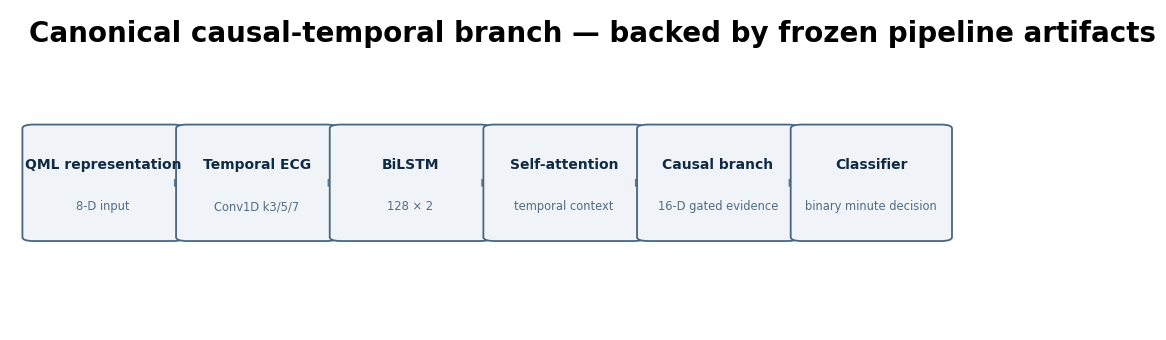

,Development promotion evidence,Value
0,Development accuracy,0.895083
1,Accuracy gain vs development-best parent (pp),0.69318
2,Balanced-accuracy delta (pp),0.651871
3,F1 delta (pp),0.876971
4,AUPRC delta (pp),0.958086
5,Sensitivity delta (pp),0.476117
6,Promotion gate,True


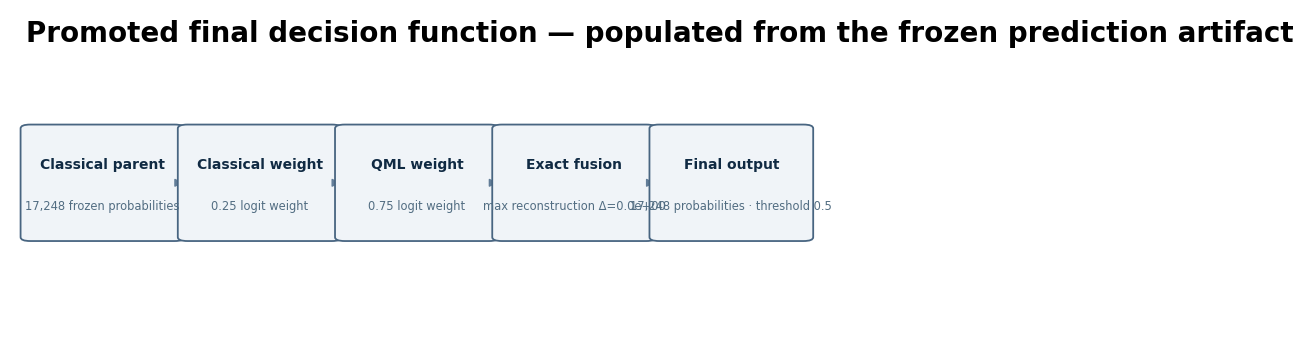

,System role,Accuracy (%)
0,Best classical-only benchmark,91.019249
1,Final QML-inclusive system,90.862709
2,Canonical QML system,90.114796


,Record category,Rule
0,A,apnea minutes ≥ 100
1,B,5 ≤ apnea minutes < 100
2,C,apnea minutes < 5


,record_name,scorable_minutes,predicted_apnea_minutes,taskc_predicted_class,official_annotated_minutes_full,true_apnea_minutes_full,taskc_true_class_full,matched_scorable_minutes,true_apnea_minutes_scorable,taskc_true_class_scorable,excluded_labelled_minutes,full_vs_scorable_class_changed,correct_official_full,correct_coverage_matched,apnea_count_error_vs_full,abs_apnea_count_error_vs_full
0,x01,522,282,A,523,375,A,522,375,A,1,False,True,True,-93,93
1,x02,469,214,A,469,209,A,469,209,A,0,False,True,True,5,5
2,x03,465,4,C,465,12,B,465,12,B,0,False,False,False,-8,8
3,x04,481,0,C,482,0,C,481,0,C,1,False,True,True,0,0
4,x05,504,409,A,505,316,A,504,316,A,1,False,True,True,93,93
5,x06,449,68,B,450,0,C,449,0,C,1,False,False,False,68,68
6,x07,508,276,A,509,240,A,508,239,A,1,False,True,True,36,36
7,x08,517,373,A,517,324,A,517,324,A,0,False,True,True,49,49
8,x09,507,170,A,508,167,A,507,167,A,1,False,True,True,3,3
9,x10,509,118,A,510,96,B,509,96,B,1,False,False,False,22,22


,Field,Value
0,audit,FINAL_METRIC_CHAMPION_FIXED_FUSION_AUDIT_v1
1,candidate_family,three fixed post-HMM logit fusions only
2,created_utc,2026-09-13T20:59:57.602931+00:00
3,development_best_parent,PARENT_GUIDE_QML_CORE3
4,development_best_parent_metrics.accuracy,0.8881513246783763
...,...,...
102,winner.specificity,0.9405441400304414
103,winner.tn,9887
104,winner.tp,5350
105,winner.w_phys,0.25


,Field,Value
0,beats_91p0192_accuracy,False
1,frozen_fusion_sha256,063a017e61188393bcdcdacb72958ffa3e7e0efa9432d3...
2,fusion.accuracy,0.9086270871985158
3,fusion.auprc,0.9497755803318464
4,fusion.auroc,0.9675236374617686
5,fusion.balanced_accuracy,0.9076848836674374
6,fusion.brier,0.0796448443135515
7,fusion.f1,0.882475764354959
8,fusion.fn,630
9,fusion.fp,946


...

,Field,Value
0,status,TASKC_METRICMAX_X_PREDICTIONS_FROZEN_BEFORE_SC...
1,frozen_at_utc,2026-09-13T06:10:45.689090+00:00
2,taska_x_source,/content/drive/MyDrive/QML_SleepNet/outputs/GU...
3,taska_x_source_sha256,f121a79191be00a28f33e06e7dec20cc689268b10a988c...
4,taskc_family,hard_run_tuned
5,taskc_aggregator.family,hard_run_tuned
6,taskc_aggregator.threshold,0.75
7,taskc_aggregator.min_run,8
8,taskc_aggregator.development_all_oof_metrics.n...,35
9,taskc_aggregator.development_all_oof_metrics.a...,0.8571428571428571


,record_name,estimated_apnea_minutes,taskc_predicted_class
0,x01,261.0,A
1,x02,201.0,A
2,x03,0.0,C
3,x04,0.0,C
4,x05,399.0,A
5,x06,9.0,B
6,x07,231.0,A
7,x08,370.0,A
8,x09,166.0,A
9,x10,92.0,B


,family,n_records,accuracy,balanced_accuracy,macro_f1,mcc,recall_A,recall_B,recall_C,confusion_matrix_json
0,hard_run_tuned,35,0.800000,0.733333,0.715250,0.673575,0.9,0.6,0.7,"[[18, 2, 0], [0, 3, 2], [0, 3, 7]]"
1,misclassification_corrected,35,0.771429,0.700000,0.682228,0.625463,0.8,0.4,0.9,"[[16, 3, 1], [1, 2, 2], [0, 1, 9]]"
2,baseline_hard_0p5,35,0.771429,0.700000,0.680869,0.632336,0.9,0.6,0.6,"[[18, 2, 0], [0, 3, 2], [0, 4, 6]]"
3,soft_sum_raw,35,0.714286,0.600000,0.599009,0.530135,0.9,0.4,0.5,"[[18, 2, 0], [1, 2, 2], [0, 5, 5]]"
4,temperature_soft_sum,35,0.600000,0.500000,0.400000,0.401189,0.9,0.6,0.0,"[[18, 2, 0], [2, 3, 0], [0, 10, 0]]"
5,platt_soft_sum,35,0.600000,0.500000,0.400000,0.401189,0.9,0.6,0.0,"[[18, 2, 0], [2, 3, 0], [0, 10, 0]]"
6,isotonic_soft_sum,35,0.600000,0.500000,0.400000,0.401189,0.9,0.6,0.0,"[[18, 2, 0], [2, 3, 0], [0, 10, 0]]"


,meta_fold,family,record_name,estimated_apnea_minutes,predicted_class,true_class
0,0,baseline_hard_0p5,a01,478.000000,A,A
1,0,baseline_hard_0p5,a14,361.000000,A,A
2,0,baseline_hard_0p5,a15,444.000000,A,A
3,0,baseline_hard_0p5,a20,107.000000,A,A
4,0,baseline_hard_0p5,b02,93.000000,B,B
...,...,...,...,...,...,...
240,4,misclassification_corrected,a18,489.000000,A,A
241,4,misclassification_corrected,a19,274.979045,A,A
242,4,misclassification_corrected,b03,104.194877,A,B
243,4,misclassification_corrected,c02,0.000000,C,C


,Field,Value
0,status,TASKC_NESTED_META_SELECTION_COMPLETE
1,candidate_families,"[""baseline_hard_0p5"", ""hard_run_tuned"", ""soft_..."
2,selection_priority,"[""accuracy"", ""balanced_accuracy"", ""macro_f1"", ..."
3,promotion_gate.baseline_family,baseline_hard_0p5
4,promotion_gate.candidate_family,hard_run_tuned
5,promotion_gate.baseline_accuracy,0.7714285714285715
6,promotion_gate.candidate_accuracy,0.8
7,promotion_gate.accuracy_gain,0.02857142857142858
8,promotion_gate.minimum_gain_one_record,0.02857142857142857
9,promotion_gate.balanced_accuracy_nondecrease,True


In [10]:
stage_banner(8, "Hybrid Task Modeling", "Canonical QML parent, promoted final fusion and record-level secondary task")

if not REGISTRY_DF.loc[REGISTRY_DF["Stage"].eq(8),"Verified"].item():
    raise RuntimeError("Stage 08 artifact verification failed.")
draw_flow([
    ("QML representation",f"{bridge_test.shape[1]}-D input"),
    ("Temporal ECG","Conv1D k3/5/7"),
    ("BiLSTM","128 × 2"),
    ("Self-attention","temporal context"),
    ("Causal branch","16-D gated evidence"),
    ("Classifier","binary minute decision"),
], "Canonical causal-temporal branch — backed by frozen pipeline artifacts", "08_causal_temporal_hybrid")

# Actual promoted fusion evidence.
freeze=safe_json(FUSION_FREEZE,{}) or {}
winner=freeze.get("winning_fusion",{})
promotion=pd.DataFrame([
    ["Development accuracy",winner.get("accuracy")],
    ["Accuracy gain vs development-best parent (pp)",winner.get("accuracy_delta_vs_dev_best_parent_pp")],
    ["Balanced-accuracy delta (pp)",winner.get("balanced_accuracy_delta_vs_dev_best_parent_pp")],
    ["F1 delta (pp)",winner.get("f1_delta_vs_dev_best_parent_pp")],
    ["AUPRC delta (pp)",winner.get("auprc_delta_vs_dev_best_parent_pp")],
    ["Sensitivity delta (pp)",winner.get("sensitivity_delta_vs_dev_best_parent_pp")],
    ["Promotion gate",winner.get("promotion_gate_pass")],
],columns=["Development promotion evidence","Value"])
display(promotion)
register_table("08_final_fusion_development_promotion.csv", promotion)

draw_flow([
    ("Classical parent",f"{len(P_PHYS):,} frozen probabilities"),
    ("Classical weight",f"{W_PHYS:.2f} logit weight"),
    ("QML weight",f"{W_QML:.2f} logit weight"),
    ("Exact fusion",f"max reconstruction Δ={RECON_MAX:.1e}"),
    ("Final output",f"{len(P_FINAL):,} probabilities · threshold {THR:.1f}"),
], "Promoted final decision function — populated from the frozen prediction artifact", "08_promoted_final_fusion")

systems=pd.DataFrame([
    ["Best classical-only benchmark",100*M_PHYS["accuracy"]],
    ["Final QML-inclusive system",100*M_FINAL["accuracy"]],
    ["Canonical QML system",100*M_QML["accuracy"]],
],columns=["System role","Accuracy (%)"])
display(systems)
register_table("08_final_system_roles.csv", systems)

# Secondary Task-C evidence, clearly separated from promoted Task-A lineage.
taskc_metric_path = TASKC_ROOT / "TASKC_POSTHOC_X_METRICS.json"
taskc_per_record = TASKC_ROOT / "TASKC_POSTHOC_X_PER_RECORD.csv"
taskc_final_simple = TASKC_FINAL_ROOT / "TASKC_ABC_PER_RECORD_FINAL_RESULTS.csv"
taskc_source = taskc_per_record if taskc_per_record.is_file() else taskc_final_simple

taskc_rule=pd.DataFrame([
    ["A","apnea minutes ≥ 100"],
    ["B","5 ≤ apnea minutes < 100"],
    ["C","apnea minutes < 5"],
],columns=["Record category","Rule"])
display(taskc_rule)
register_table("08_taskc_record_category_rule.csv", taskc_rule)

if taskc_source.is_file():
    tc=pd.read_csv(taskc_source)
    display(tc.head(12))
    register_table("08_taskc_per_record_evidence.csv", tc)

display(HTML("""
<div style="padding:10px 14px;background:#F0F4F8;border-left:5px solid #627D98;border-radius:8px;">
<b>Secondary-task lineage:</b> the frozen A/B/C record-category analysis is reported as a secondary
Apnea-ECG burden analysis. It is not an OSA/CSA/Mixed subtype classifier and is not a conventional clinical AHI severity model.
</div>
"""))

display_artifact_gallery(
    FUSION_ROOT,
    "Final fusion — development decision, promotion and frozen result evidence",
    recursive=True,
    table_mode="all",
    max_files=55
)

display_artifact_gallery(
    TASKC_ROOT,
    "Secondary record-category analysis — frozen evidence",
    recursive=True,
    table_mode="summary",
    max_files=35
)


## Stage 09

,parent,fixed_weight,mean_abs_weighted_logit_contribution,mean_signed_weighted_logit_contribution,mean_abs_contribution_predicted_apnea,mean_abs_contribution_predicted_normal,mean_parent_probability
0,Guide-primary QML parent,0.75,6.422949,-1.330319,6.395685,6.440967,0.399658
1,Stage15A physiology parent,0.25,2.144723,-0.467163,2.113107,2.165617,0.399148


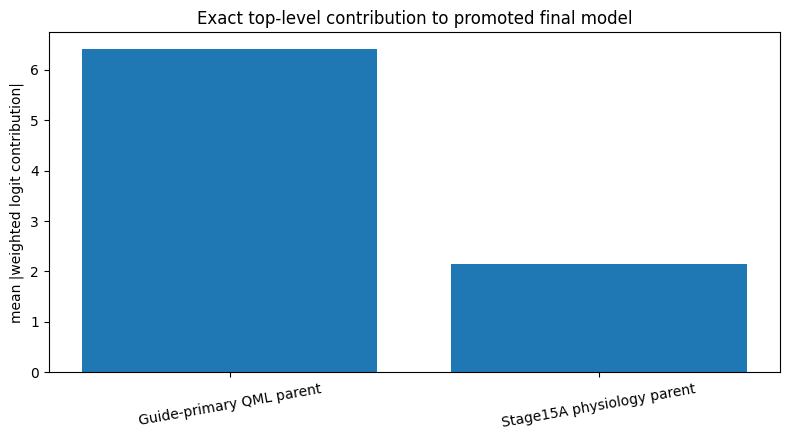

,feature_index,feature_name,mean_catboost_feature_importance,std_catboost_feature_importance_across_5_seeds
0,366,ecg_mad,3.929102,0.592592
1,317,cpcc_classic_cpc_top2_low_high_ratio,3.830414,0.146142
2,123,cwtc_edr_cwt_ridge_iqr_hz,2.784138,0.133175
3,331,cpcp_classic_cpc_top2_low_high_ratio,2.198386,0.113024
4,353,ecg_25_3125_relpower,2.159657,0.180566
5,343,ecg_3_8_relpower,2.129527,0.285577
6,209,lsp_ls_peak_hz,2.020793,0.112407
7,119,cwtc_edr_cwt_log_apnea_low,2.013323,0.430843
8,115,cwtc_edr_cwt_apnea_low,1.792909,0.350518
9,95,cvhrc_cvhr_lowband_power,1.772984,0.118821


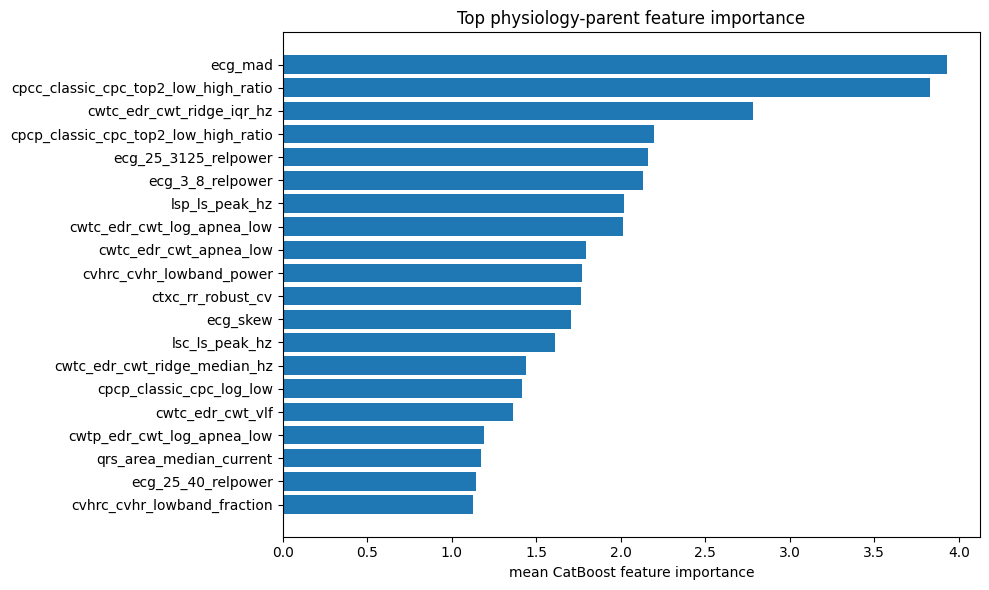

,case,row,uid,record_name,epoch_idx,physiology_probability,qml_probability,physiology_weighted_logit,qml_weighted_logit,fused_probability,prediction,parent_abs_logit_disagreement
0,highest_final_probability,13395,x28:146,x28,146,0.999988,9.999989e-01,2.828128,10.307382,9.999980e-01,1,2.430666
1,lowest_final_probability,10291,x22:3,x22,3,0.000073,2.238945e-07,-2.381357,-11.484068,9.513094e-07,0,5.786661
2,closest_to_threshold,5770,x12:383,x12,383,0.004244,8.605343e-01,-1.364508,1.364801,5.000734e-01,1,7.277767
3,maximum_parent_logit_disagreement,5293,x11:362,x11,362,0.000510,9.993731e-01,-1.895018,5.530518,9.743068e-01,1,14.954097
4,largest_abs_phys_weighted_logit,14892,x31:167,x31,167,0.999998,9.999836e-01,3.300386,8.261711,9.999905e-01,1,2.185929
5,largest_abs_qml_weighted_logit,13760,x29:16,x29,16,0.000163,1.942344e-07,-2.180937,-11.590650,1.044901e-06,0,6.730451


,Item,Evidence
0,Final prediction SHA,063a017e61188393bcdcdacb72958ffa3e7e0efa9432d3...
1,Top-level explanation,exact weighted-logit decomposition
2,Classical parent,frozen CatBoost feature importance
3,QML parent,inherited exact-parent latent / causal / ECG e...
4,Causal interpretation,"model-based, assumption-dependent; not clinica..."


,artifact,source_path,sha256,scope
0,BRIDGE_Z8_EXACT_HEAD_ATTRIBUTION.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,8b1ab2815bd974908d2e70e279997b65084f2497846b80...,unchanged guide-primary QML parent component e...
1,CAUSAL_GRAPH_PAIRWISE_METHOD_SUPPORT.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,0ca3f312e566007c6074fc2a875645b41bd0ae6d2aa994...,unchanged guide-primary QML parent component e...
2,FINAL_CAUSAL_ACE_RANKING_COPY.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,04e4a03ee5a836a7942b8e67ccd03b2fc84ff42522bcb1...,unchanged guide-primary QML parent component e...
3,FINAL_ENSEMBLE_BRANCH_CONTRIBUTION.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,c9303f506f6848584195aeecbdd94e0aa0f3ef61035905...,unchanged guide-primary QML parent component e...
4,FINAL_STAGE06_CAUSAL_GATE_UTILIZATION.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,6ea581849de52d9b37468a2b1818773c5dc4f80d9c821b...,unchanged guide-primary QML parent component e...
5,FROZEN_SHAP_SELECTED_FEATURES_WITH_METADATA.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,2e8ff688af4e8ad3acff1cc571249349da7a6f58e19a22...,unchanged guide-primary QML parent component e...
6,QT_ANGLE64_EXACT_HEAD_ATTRIBUTION.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,4c50b7112453bc2c9989f919af5dbd0274249d83d72e27...,unchanged guide-primary QML parent component e...
7,REPRESENTATIVE_FINAL_ENSEMBLE_CASES.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,9c8eb13bfbb8ed13c27dec3082d2dbfa9a4e97998e439d...,unchanged guide-primary QML parent component e...
8,SCM_OUTCOME_PARENT_EDGES.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,9dd04364c12fc3959f0e6bb4fe0f4d4140fa058abcfb86...,unchanged guide-primary QML parent component e...
9,STAGE06_IMPORTANT_ECG_TIME_SEGMENTS.csv,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,70dc17782f21738dfcb487edbac799865c673c455590fe...,unchanged guide-primary QML parent component e...


,latent_dimension,head_margin_weight,mean_abs_margin_contribution,mean_signed_margin_contribution
0,Bridge_Z8_2,-0.556907,0.439289,-0.245407
1,Bridge_Z8_7,0.542556,0.398858,0.035388
2,Bridge_Z8_5,0.504152,0.309065,0.012258
3,Bridge_Z8_0,-0.405053,0.205467,0.124508
4,Bridge_Z8_6,0.319391,0.201427,0.029283
5,Bridge_Z8_1,0.255318,0.190617,-0.189995
6,Bridge_Z8_3,-0.134821,0.079226,-0.027116
7,Bridge_Z8_4,0.158966,0.040693,-0.019480


,feature_1,feature_2,method_support_count,present_PC,present_FCI,present_NOTEARS,present_LiNGAM
0,cur_rmssd_s,cur_poincare_sd1_s,4,True,True,True,True
1,cur_rr_mean_s,cur_pnn50,4,True,True,True,True
2,cur_rr_mean_s,ecg_rms,4,True,True,True,True
3,cur_sdnn_s,cur_poincare_sd2_s,4,True,True,True,True
4,cur_sdnn_s,cur_rmssd_s,4,True,True,True,True
...,...,...,...,...,...,...,...
228,qrs_p2p_median_current,guide_t_wave_amplitude,1,False,False,False,True
229,ramp_signed_median_current,ecg_median_frequency_hz,1,False,False,False,True
230,ramp_signed_median_current,ecg_rms,1,False,False,False,True
231,ramp_signed_median_current,ecg_spectral_entropy,1,False,False,False,True


...

,parent,fixed_weight,mean_abs_weighted_logit_contribution,mean_signed_weighted_logit_contribution,mean_abs_contribution_predicted_apnea,mean_abs_contribution_predicted_normal,mean_parent_probability
0,Guide-primary QML parent,0.75,6.422949,-1.330319,6.395685,6.440967,0.399658
1,Stage15A physiology parent,0.25,2.144723,-0.467163,2.113107,2.165617,0.399148


,case,row,uid,record_name,epoch_idx,physiology_probability,qml_probability,physiology_weighted_logit,qml_weighted_logit,fused_probability,prediction,parent_abs_logit_disagreement
0,highest_final_probability,13395,x28:146,x28,146,0.999988,9.999989e-01,2.828128,10.307382,9.999980e-01,1,2.430666
1,lowest_final_probability,10291,x22:3,x22,3,0.000073,2.238945e-07,-2.381357,-11.484068,9.513094e-07,0,5.786661
2,closest_to_threshold,5770,x12:383,x12,383,0.004244,8.605343e-01,-1.364508,1.364801,5.000734e-01,1,7.277767
3,maximum_parent_logit_disagreement,5293,x11:362,x11,362,0.000510,9.993731e-01,-1.895018,5.530518,9.743068e-01,1,14.954097
4,largest_abs_phys_weighted_logit,14892,x31:167,x31,167,0.999998,9.999836e-01,3.300386,8.261711,9.999905e-01,1,2.185929
5,largest_abs_qml_weighted_logit,13760,x29:16,x29,16,0.000163,1.942344e-07,-2.180937,-11.590650,1.044901e-06,0,6.730451


,feature_index,feature_name,mean_catboost_feature_importance,std_catboost_feature_importance_across_5_seeds
0,366,ecg_mad,3.929102,0.592592
1,317,cpcc_classic_cpc_top2_low_high_ratio,3.830414,0.146142
2,123,cwtc_edr_cwt_ridge_iqr_hz,2.784138,0.133175
3,331,cpcp_classic_cpc_top2_low_high_ratio,2.198386,0.113024
4,353,ecg_25_3125_relpower,2.159657,0.180566
...,...,...,...,...
374,166,pcacplc_coh_peak_hz,0.000000,0.000000
375,160,pcacplc_coh_vlf,0.000000,0.000000
376,139,cplc_coh_apnea_low,0.000000,0.000000
377,58,ctxc_context_coverage,0.000000,0.000000


,model_file,sha256,feature_count
0,cat_group_d8__seed101.joblib,87411ffb0a92b10c1ad5af13ae1fb405c2227e7285f3ee...,379
1,cat_group_d8__seed17.joblib,fd57949665eef86027cda9a301e6508cb766879b42d2d6...,379
2,cat_group_d8__seed29.joblib,e05a446d5e104653a4f944b00d64b960de7f66513a7882...,379
3,cat_group_d8__seed43.joblib,3ecf80c87ed8d2eeeb787b0c63ef52e986027282de62cf...,379
4,cat_group_d8__seed71.joblib,180a098725b26baaf8b616d3ec4bf32b8969d89460837a...,379


,Field,Value
0,classical_parent_explanation.artifact,STAGE15A_CLASSICAL_PARENT_FEATURE_IMPORTANCE.csv
1,classical_parent_explanation.limitation,CatBoost model importance is not causal eviden...
2,classical_parent_explanation.method,mean frozen CatBoost feature_importances_ acro...
3,classical_parent_explanation.model_hashes,STAGE15A_CLASSICAL_PARENT_MODEL_HASHES.csv
4,created_at_utc,2026-09-14T10:11:28.398803+00:00
5,exact_top_level_explanation.artifact,PROMOTED_FINAL_PARENT_LOGIT_CONTRIBUTION.csv
6,exact_top_level_explanation.method,weighted logit decomposition
7,exact_top_level_explanation.reconstruction_max...,0.0
8,exact_top_level_explanation.weights.physiology,0.25
9,exact_top_level_explanation.weights.qml,0.75


In [11]:
stage_banner(9, "Interpretability & Causal Analysis", "Exact parent contribution, physiology importance, causal evidence and representative cases")

contrib_path=XAI_ROOT/"PROMOTED_FINAL_PARENT_LOGIT_CONTRIBUTION.csv"
importance_path=XAI_ROOT/"STAGE15A_CLASSICAL_PARENT_FEATURE_IMPORTANCE.csv"
rep_path=XAI_ROOT/"PROMOTED_FINAL_REPRESENTATIVE_CASES.csv"
ace_path=XAI_ROOT/"FINAL_CAUSAL_ACE_RANKING_COPY.csv"
edge_path=XAI_ROOT/"SCM_OUTCOME_PARENT_EDGES.csv"

if contrib_path.is_file():
    contrib=pd.read_csv(contrib_path)
    display(contrib)
    register_table("09_parent_logit_contribution.csv", contrib)
    fig,ax=plt.subplots(figsize=(8,4.5))
    ax.bar(contrib["parent"],contrib["mean_abs_weighted_logit_contribution"])
    ax.set_ylabel("mean |weighted logit contribution|")
    ax.set_title("Exact top-level contribution to promoted final model")
    ax.tick_params(axis="x",rotation=10)
    fig.tight_layout()
    register_visual("09_parent_logit_contribution.png")
    plt.show(); plt.close(fig)

if importance_path.is_file():
    imp=pd.read_csv(importance_path).head(20)
    display(imp)
    register_table("09_top20_classical_feature_importance.csv", imp)
    fig,ax=plt.subplots(figsize=(10,6))
    ax.barh(imp["feature_name"][::-1],imp["mean_catboost_feature_importance"][::-1])
    ax.set_xlabel("mean CatBoost feature importance")
    ax.set_title("Top physiology-parent feature importance")
    fig.tight_layout()
    register_visual("09_classical_parent_feature_importance.png")
    plt.show(); plt.close(fig)

if ace_path.is_file():
    ace=pd.read_csv(ace_path).head(20)
    display(ace)
    register_table("09_causal_ace_ranking.csv", ace)
    numeric=[c for c in ace.columns if "ace" in c.lower()]
    namec=next((c for c in ace.columns if "feature" in c.lower() or "name" in c.lower()),None)
    if numeric and namec:
        col=numeric[0]
        fig,ax=plt.subplots(figsize=(10,6))
        top=ace[[namec,col]].dropna().head(15)
        ax.barh(top[namec][::-1],top[col][::-1])
        ax.set_xlabel(col)
        ax.set_title("Model-based causal effect ranking")
        fig.tight_layout()
        register_visual("09_causal_ace_ranking.png")
        plt.show(); plt.close(fig)

if rep_path.is_file():
    rep=pd.read_csv(rep_path)
    display(rep)
    register_table("09_representative_final_cases.csv", rep)

xai_manifest=safe_json(XAI_ROOT/"XAI_PROMOTED_FINAL_MANIFEST.json",{}) or {}
backend_receipt([
    ("Final prediction SHA", xai_manifest.get("promoted_final_prediction_sha256","")),
    ("Top-level explanation", "exact weighted-logit decomposition"),
    ("Classical parent", "frozen CatBoost feature importance"),
    ("QML parent", "inherited exact-parent latent / causal / ECG evidence"),
    ("Causal interpretation", "model-based, assumption-dependent; not clinical proof"),
])

# The promoted-final XAI package contains an index to inherited QML-parent
# explanation artifacts. Render the indexed artifacts themselves.
xai_index = XAI_ROOT / "INHERITED_QML_COMPONENT_XAI_ARTIFACT_INDEX.csv"
if xai_index.is_file():
    idx = pd.read_csv(xai_index)
    display_dataframe_inline(idx, "QML-component explanation artifact index")
    rendered = display_referenced_artifacts(
        idx,
        "Actual inherited QML-component explanation artifacts"
    )
    print(f"Inherited XAI artifacts rendered inline: {rendered}")

# Also render every document-relevant table/image physically present in the
# promoted-final XAI folder.
display_artifact_gallery(
    XAI_ROOT,
    "Interpretability & causal analysis — complete frozen evidence gallery",
    recursive=True,
    table_mode="all",
    max_files=70
)


## Stage 10

,condition,scope,qml_parent_perturbed_accuracy,qml_parent_perturbed_balanced_accuracy,qml_parent_perturbed_f1,qml_parent_perturbed_auroc,promoted_final_accuracy,promoted_final_balanced_accuracy,promoted_final_f1,promoted_final_auroc,promoted_final_auprc,promoted_final_accuracy_delta_vs_clean_pp
0,SNR20_DB,Stage06 temporal-channel perturbation propagat...,0.901322,0.897973,0.871818,0.957818,0.909729,0.907535,0.883117,0.965611,0.949122,0.110158
1,SNR10_DB,Stage06 temporal-channel perturbation propagat...,0.897727,0.897122,0.869120,0.957092,0.907236,0.906386,0.880793,0.964827,0.948266,-0.139147
2,CENTRAL_45S,Stage06 temporal-channel perturbation propagat...,0.900916,0.900463,0.873173,0.962016,0.907699,0.907115,0.881530,0.967459,0.949886,-0.092764
3,CENTRAL_30S,Stage06 temporal-channel perturbation propagat...,0.900626,0.900407,0.872962,0.962059,0.907294,0.907114,0.881265,0.967506,0.949609,-0.133349


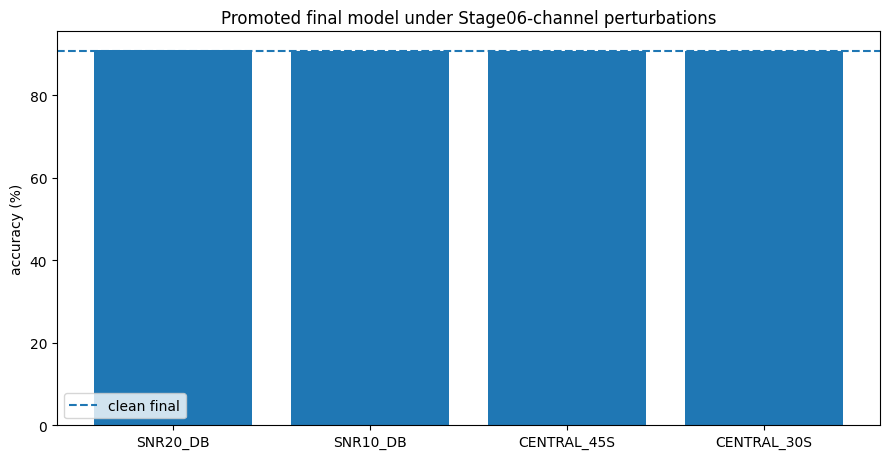

,system,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,mcc,auroc,auprc,brier,nll,tn,fp,fn,tp,accuracy_delta_vs_promoted_final_pp
0,PHYSIOLOGY_PARENT_ONLY,17248,0.910192,0.909747,0.862700,0.907897,0.911597,0.884721,0.811954,0.969663,0.950449,0.079585,0.441768,9755,946,603,5944,0.156540
2,PROMOTED_FINAL_PHYS25_QML75,17248,0.908627,0.907685,0.862159,0.903773,0.911597,0.882476,0.808403,0.967524,0.949776,0.079645,0.433467,9755,946,630,5917,0.000000
3,QML_PARENT_ONLY,17248,0.901148,0.900116,0.851481,0.895830,0.904401,0.873093,0.792908,0.962067,0.942772,0.086143,0.487634,9678,1023,682,5865,-0.747913


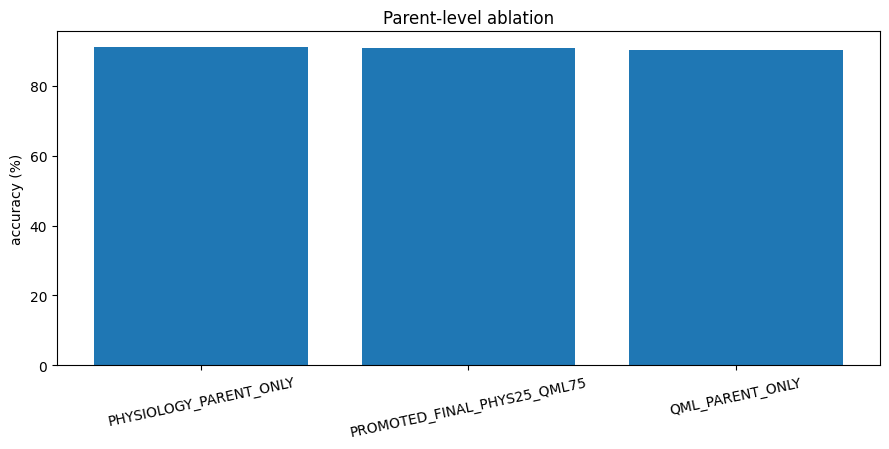

,grouping,group,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,mcc,auroc,auprc,brier,nll,tn,fp,fn,tp
0,taskc_true_class_full,A,10182,0.880672,0.871618,0.898180,0.910030,0.833205,0.904066,0.746384,0.950618,0.968218,0.103781,0.559917,3242,649,566,5725
1,taskc_true_class_full,B,2471,0.876163,0.837836,0.429530,0.790123,0.885548,0.556522,0.522681,0.908189,0.607964,0.109224,0.627429,1973,255,51,192
2,taskc_true_class_full,C,4595,0.988030,0.495417,0.000000,0.000000,0.990834,0.000000,-0.005116,0.685509,0.005022,0.010256,0.048961,4540,42,13,0
3,burden_quartile,Q1_of_4,4121,0.987624,0.494893,0.000000,0.000000,0.989786,0.000000,-0.004747,0.700659,0.004240,0.010448,0.045909,4070,42,9,0
4,burden_quartile,Q2_of_4,4488,0.913770,0.899989,0.650452,0.880551,0.919426,0.748211,0.709249,0.956707,0.824370,0.075464,0.413369,3526,309,78,575
5,burden_quartile,Q3_of_4,4023,0.875217,0.870620,0.839152,0.946111,0.795130,0.889427,0.754518,0.953062,0.959975,0.108766,0.603076,1502,387,115,2019
6,burden_quartile,Q4_of_4,4616,0.862218,0.822717,0.941093,0.885897,0.759538,0.912661,0.593978,0.917075,0.977794,0.120106,0.651184,657,208,428,3323
7,length_quartile,Q1_of_4,4067,0.975166,0.926537,0.750000,0.871369,0.981704,0.806142,0.795501,0.969403,0.892442,0.020911,0.095228,3756,70,31,210
8,length_quartile,Q2_of_4,4385,0.928392,0.924255,0.953973,0.883308,0.965203,0.917281,0.856284,0.983858,0.979250,0.062675,0.324722,2330,84,230,1741
9,length_quartile,Q3_of_4,4063,0.865617,0.871422,0.802045,0.934995,0.807848,0.863432,0.741044,0.951065,0.942785,0.116734,0.645443,1791,426,120,1726


,branch,feature_index,mean_abs_probability_change,max_abs_probability_change
0,CAUSAL16,0,0.220672,0.772057
1,CAUSAL16,1,0.143301,0.699562
2,CAUSAL16,2,0.089670,0.537980
3,CAUSAL16,4,0.065887,0.528763
4,QML8,7,0.061941,0.244960
5,QML8,6,0.046251,0.192777
6,CAUSAL16,6,0.038997,0.184800
7,CAUSAL16,7,0.036677,0.207540
8,QML8,1,0.036578,0.169443
9,QML8,5,0.033671,0.185852


,Field,Value
0,definition,heuristic Stage02 artifact-prone subset: any p...
1,diff_rms_q75,0.7627919465303421
2,flat_fraction_q75,0.002333722287047841
3,fraction,0.9721127087198516
4,important_limitation,Deterministic ECG-quality stress proxy; not cl...
5,mask_reused_from_qml_stage10,True
6,n,16767
7,promoted_final_metrics.accuracy,0.9102403530744916
8,promoted_final_metrics.auprc,0.9520664723699143
9,promoted_final_metrics.auroc,0.9682358948711787


,Field,Value
0,development_oof_accuracy,0.8950831228338131
1,development_oof_auprc,0.9309623613600381
2,development_oof_balanced_accuracy,0.8811152584655355
3,development_oof_f1,0.8569597949703668
4,development_selection_unit,strict development OOF; fixed candidate family...
5,development_winner,FIXED_LOGIT_PHYS_25_QML_75
6,notes,"[""No cross-validation is rerun in this refresh..."
7,official_unseen_x_accuracy,0.9086270871985158
8,official_unseen_x_n,17248
9,promoted_final_prediction_sha256,063a017e61188393bcdcdacb72958ffa3e7e0efa9432d3...


,Field,Value
0,created_at_utc,2026-09-14T10:11:45.337383+00:00
1,ensemble_weight_tuning_performed,False
2,headline_model_modified,False
3,locked_official_x_accuracy,0.9086270871985158
4,model_selection_performed,False
5,next,Stage 11 — Final Evaluation Protocol / statist...
6,official_x_labels_role,evaluation only; historical x exposure caveat ...
7,outputs,"[""STAGE10_PROMOTED_CV_UNSEEN_SUMMARY.json"", ""S..."
8,primary_frozen_model,25% Stage15A physiology + 75% guide-primary QM...
9,primary_frozen_prediction_sha256,063a017e61188393bcdcdacb72958ffa3e7e0efa9432d3...


,grouping,group,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,mcc,auroc,auprc,brier,nll,tn,fp,fn,tp
0,taskc_true_class_full,A,10182,0.880672,0.871618,0.898180,0.910030,0.833205,0.904066,0.746384,0.950618,0.968218,0.103781,0.559917,3242,649,566,5725
1,taskc_true_class_full,B,2471,0.876163,0.837836,0.429530,0.790123,0.885548,0.556522,0.522681,0.908189,0.607964,0.109224,0.627429,1973,255,51,192
2,taskc_true_class_full,C,4595,0.988030,0.495417,0.000000,0.000000,0.990834,0.000000,-0.005116,0.685509,0.005022,0.010256,0.048961,4540,42,13,0
3,burden_quartile,Q1_of_4,4121,0.987624,0.494893,0.000000,0.000000,0.989786,0.000000,-0.004747,0.700659,0.004240,0.010448,0.045909,4070,42,9,0
4,burden_quartile,Q2_of_4,4488,0.913770,0.899989,0.650452,0.880551,0.919426,0.748211,0.709249,0.956707,0.824370,0.075464,0.413369,3526,309,78,575
5,burden_quartile,Q3_of_4,4023,0.875217,0.870620,0.839152,0.946111,0.795130,0.889427,0.754518,0.953062,0.959975,0.108766,0.603076,1502,387,115,2019
6,burden_quartile,Q4_of_4,4616,0.862218,0.822717,0.941093,0.885897,0.759538,0.912661,0.593978,0.917075,0.977794,0.120106,0.651184,657,208,428,3323
7,length_quartile,Q1_of_4,4067,0.975166,0.926537,0.750000,0.871369,0.981704,0.806142,0.795501,0.969403,0.892442,0.020911,0.095228,3756,70,31,210
8,length_quartile,Q2_of_4,4385,0.928392,0.924255,0.953973,0.883308,0.965203,0.917281,0.856284,0.983858,0.979250,0.062675,0.324722,2330,84,230,1741
9,length_quartile,Q3_of_4,4063,0.865617,0.871422,0.802045,0.934995,0.807848,0.863432,0.741044,0.951065,0.942785,0.116734,0.645443,1791,426,120,1726


,system,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,mcc,auroc,auprc,brier,nll,tn,fp,fn,tp,accuracy_delta_vs_promoted_final_pp
0,PHYSIOLOGY_PARENT_ONLY,17248,0.910192,0.909747,0.862700,0.907897,0.911597,0.884721,0.811954,0.969663,0.950449,0.079585,0.441768,9755,946,603,5944,0.156540
1,NEUTRALIZE_QML_PARENT_KEEP_PHYS_WEIGHT25,17248,0.910192,0.909747,0.862700,0.907897,0.911597,0.884721,0.811954,0.969663,0.950449,0.069024,0.247964,9755,946,603,5944,0.156540
2,PROMOTED_FINAL_PHYS25_QML75,17248,0.908627,0.907685,0.862159,0.903773,0.911597,0.882476,0.808403,0.967524,0.949776,0.079645,0.433467,9755,946,630,5917,0.000000
3,QML_PARENT_ONLY,17248,0.901148,0.900116,0.851481,0.895830,0.904401,0.873093,0.792908,0.962067,0.942772,0.086143,0.487634,9678,1023,682,5865,-0.747913
4,NEUTRALIZE_PHYS_PARENT_KEEP_QML_WEIGHT75,17248,0.901148,0.900116,0.851481,0.895830,0.904401,0.873093,0.792908,0.962067,0.942772,0.083113,0.381342,9678,1023,682,5865,-0.747913


,condition,scope,qml_parent_perturbed_accuracy,qml_parent_perturbed_balanced_accuracy,qml_parent_perturbed_f1,qml_parent_perturbed_auroc,promoted_final_accuracy,promoted_final_balanced_accuracy,promoted_final_f1,promoted_final_auroc,promoted_final_auprc,promoted_final_accuracy_delta_vs_clean_pp
0,SNR20_DB,Stage06 temporal-channel perturbation propagat...,0.901322,0.897973,0.871818,0.957818,0.909729,0.907535,0.883117,0.965611,0.949122,0.110158
1,SNR10_DB,Stage06 temporal-channel perturbation propagat...,0.897727,0.897122,0.869120,0.957092,0.907236,0.906386,0.880793,0.964827,0.948266,-0.139147
2,CENTRAL_45S,Stage06 temporal-channel perturbation propagat...,0.900916,0.900463,0.873173,0.962016,0.907699,0.907115,0.881530,0.967459,0.949886,-0.092764
3,CENTRAL_30S,Stage06 temporal-channel perturbation propagat...,0.900626,0.900407,0.872962,0.962059,0.907294,0.907114,0.881265,0.967506,0.949609,-0.133349


,Field,Value
0,different_sleep_stages.action,Do not fabricate sleep-stage performance.
1,different_sleep_stages.reason,The frozen prediction/target chain exposes Apn...
2,different_sleep_stages.status,NOT_EVALUABLE_FROM_CURRENT_PROJECT_ARTIFACTS
3,full_dual_parent_raw_ecg_perturbation.action,Report the promoted perturbation results as St...
4,full_dual_parent_raw_ecg_perturbation.reason,The completed Stage10 perturbation cache chang...
5,full_dual_parent_raw_ecg_perturbation.status,NOT_CLAIMED_IN_THIS_REFRESH


In [12]:
stage_banner(10, "Robustness & Ablation", "Noise/coverage stress, domain-shift analysis and component removal")

pert_path=S10_ROOT/"STAGE10_PROMOTED_PERTURBATION_ROBUSTNESS.csv"
abl_path=S10_ROOT/"STAGE10_PROMOTED_PARENT_ABLATION.csv"
domain_path=S10_ROOT/"STAGE10_PROMOTED_GENERALIZATION_DOMAIN_SHIFT.csv"

if pert_path.is_file():
    pert=pd.read_csv(pert_path)
    display(pert)
    register_table("10_robustness_perturbations.csv", pert)
    fig,ax=plt.subplots(figsize=(9,4.7))
    ax.bar(pert["condition"],100*pert["promoted_final_accuracy"])
    ax.axhline(100*M_FINAL["accuracy"],linestyle="--",label="clean final")
    ax.set_ylabel("accuracy (%)")
    ax.set_title("Promoted final model under Stage06-channel perturbations")
    ax.legend()
    fig.tight_layout()
    register_visual("10_robustness_accuracy.png")
    plt.show(); plt.close(fig)

if abl_path.is_file():
    abl=pd.read_csv(abl_path)
    keep=abl[abl["system"].isin([
        "PROMOTED_FINAL_PHYS25_QML75","PHYSIOLOGY_PARENT_ONLY","QML_PARENT_ONLY"
    ])].copy()
    display(keep)
    register_table("10_parent_ablation.csv", keep)
    fig,ax=plt.subplots(figsize=(9,4.6))
    ax.bar(keep["system"],100*keep["accuracy"])
    ax.set_ylabel("accuracy (%)")
    ax.set_title("Parent-level ablation")
    ax.tick_params(axis="x",rotation=12)
    fig.tight_layout()
    register_visual("10_parent_ablation.png")
    plt.show(); plt.close(fig)

if domain_path.is_file():
    domain=pd.read_csv(domain_path)
    display(domain)
    register_table("10_domain_shift_analysis.csv", domain)

display(HTML("""
<div style="padding:10px 14px;background:#FFF7ED;border-left:5px solid #D97706;border-radius:8px;">
<b>Scope note:</b> the perturbation experiment changes the Stage06 temporal/QML pathway while the
physiology parent remains clean. It is therefore reported as a bounded pathway stress test, not a complete dual-parent raw-ECG perturbation study.
</div>
"""))

display_artifact_gallery(
    S10_ROOT,
    "Robustness & ablation — complete frozen evidence gallery",
    recursive=True,
    table_mode="all",
    max_files=70
)


## Stage 11

,precision,recall,f1-score,support
Normal,0.939336,0.911597,0.925258,10701.000000
Apnea,0.862159,0.903773,0.882476,6547.000000
accuracy,0.908627,0.908627,0.908627,0.908627
macro avg,0.900747,0.907685,0.903867,17248.000000
weighted avg,0.910041,0.908627,0.909019,17248.000000


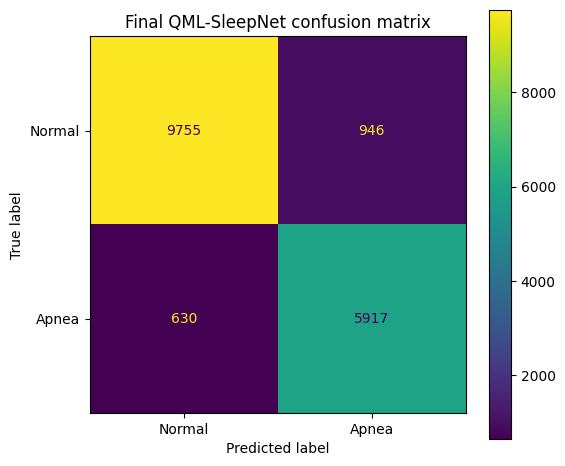

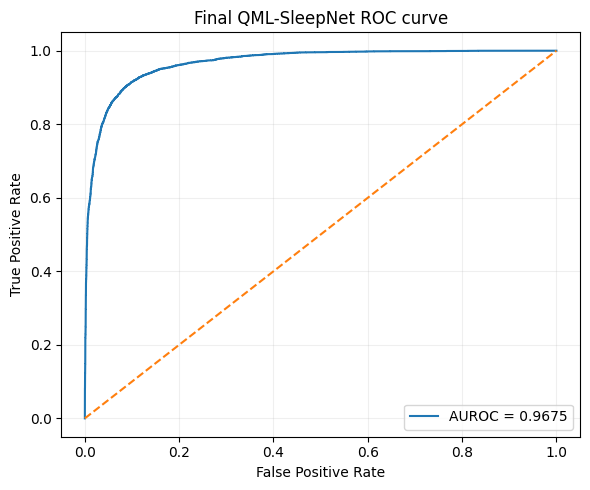

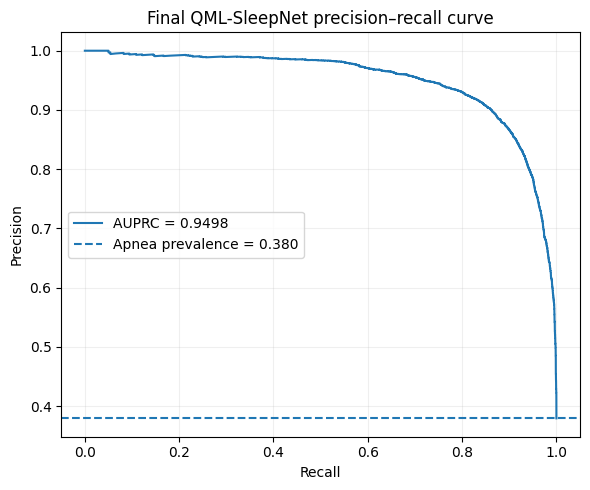

,System,Accuracy,Balanced Accuracy,Precision,Sensitivity,Specificity,F1,MCC,AUROC,AUPRC
0,Final QML-inclusive,0.908627,0.907685,0.862159,0.903773,0.911597,0.882476,0.808403,0.967524,0.949776
1,Classical benchmark,0.910192,0.909747,0.862700,0.907897,0.911597,0.884721,0.811954,0.969663,0.950449
2,Canonical QML,0.901148,0.900116,0.851481,0.895830,0.904401,0.873093,0.792908,0.962067,0.942772


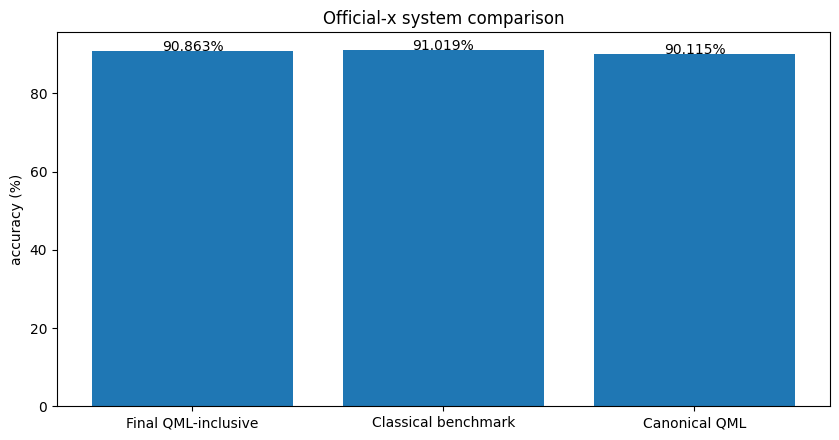

,system_a,system_b,n_pairs,mean_accuracy_a,mean_accuracy_b,mean_paired_difference,mean_paired_difference_pp,t_statistic,p_value_raw,cohen_dz,ci95_mean_difference_low,ci95_mean_difference_high,ci95_mean_difference_low_pp,ci95_mean_difference_high_pp,p_value_holm,significant_holm_0p05,statistical_unit,metric_tested,interpretation_boundary
0,FINAL_QML_INCLUSIVE_PROMOTED,STAGE15A_PHYSIOLOGY_CLASSICAL,35,0.910854,0.912722,-0.001869,-0.186894,-0.269325,0.789307,-0.045524,-0.015971,0.012234,-1.597139,1.223351,0.789307,False,official x record cluster,per-record minute-level accuracy,"35 record clusters; do not interpret 17,248 mi..."
1,FINAL_QML_INCLUSIVE_PROMOTED,CANONICAL_GUIDE_QML,35,0.910854,0.902625,0.008228,0.822810,1.728534,0.092965,0.292176,-0.001446,0.017902,-0.144571,1.790192,0.278896,False,official x record cluster,per-record minute-level accuracy,"35 record clusters; do not interpret 17,248 mi..."
2,CANONICAL_GUIDE_QML,STAGE15A_PHYSIOLOGY_CLASSICAL,35,0.902625,0.912722,-0.010097,-1.009704,-0.906933,0.370826,-0.153300,-0.032722,0.012528,-3.272238,1.252830,0.741651,False,official x record cluster,per-record minute-level accuracy,"35 record clusters; do not interpret 17,248 mi..."


,analysis,system_a,system_b,metric,observed,bootstrap_mean,ci95_low,ci95_high,probability_delta_gt_0,replicates,resampling_unit
0,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,accuracy,0.908627,0.908676,0.882403,0.933873,NaN,5000,official x record cluster
1,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,balanced_accuracy,0.907685,0.907149,0.880684,0.933057,NaN,5000,official x record cluster
2,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,precision,0.862159,0.861411,0.803242,0.907915,NaN,5000,official x record cluster
3,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,sensitivity,0.903773,0.903504,0.852913,0.947085,NaN,5000,official x record cluster
4,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,specificity,0.911597,0.910794,0.869758,0.946013,NaN,5000,official x record cluster
5,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,f1,0.882476,0.881571,0.844686,0.913725,NaN,5000,official x record cluster
6,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,mcc,0.808403,0.806887,0.756632,0.855133,NaN,5000,official x record cluster
7,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,auroc,0.967524,0.967460,0.952173,0.980662,NaN,5000,official x record cluster
8,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,auprc,0.949776,0.949388,0.917297,0.972344,NaN,5000,official x record cluster
9,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,brier,0.079645,0.079603,0.057183,0.103151,NaN,5000,official x record cluster


,system_a,system_b,n_pairs,mean_accuracy_a,mean_accuracy_b,mean_paired_difference,mean_paired_difference_pp,t_statistic,p_value_raw,cohen_dz,ci95_mean_difference_low,ci95_mean_difference_high,ci95_mean_difference_low_pp,ci95_mean_difference_high_pp,metric_tested,statistical_unit,interpretation_boundary,p_value_holm,significant_holm_0p05
0,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.878269,0.876536,0.001734,0.173353,0.220622,0.839548,0.110311,-0.023272,0.026739,-2.327237,2.673943,auroc,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,1.000000,False
1,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.817003,0.814980,0.002024,0.202357,0.205628,0.850244,0.102814,-0.029295,0.033342,-2.929463,3.334176,auprc,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,1.000000,False
2,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.749138,0.718671,0.030467,3.046728,2.724975,0.072246,1.362487,-0.005115,0.066049,-0.511488,6.604944,balanced_accuracy,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,0.288983,False
3,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.815342,0.809278,0.006064,0.606373,0.864333,0.450982,0.432166,-0.016263,0.028390,-1.626274,2.839020,group_macro_auroc,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,1.000000,False


,entry,context,correct_minutes,denominator_minutes,accuracy,source_url,same_x01_x35_task_family,protocol_identical_to_current_project
0,McNames / Fraser / Rechtsteiner,PhysioNet/CinC Challenge 2000 Event 2,15994,17268,0.926222,https://physionet.org/content/challenge-2000/1...,True,False
1,Raymond / Cayton / Bates / Chappell,PhysioNet/CinC Challenge 2000 Event 2,15939,17268,0.923037,https://physionet.org/content/challenge-2000/1...,True,False
2,de Chazal et al.,PhysioNet/CinC Challenge 2000 Event 2,15432,17268,0.893676,https://physionet.org/content/challenge-2000/1...,True,False
3,QML-SleepNet promoted final,Current frozen project evaluation,15672,17248,0.908627,internal frozen Stage11 reproduction,True,True


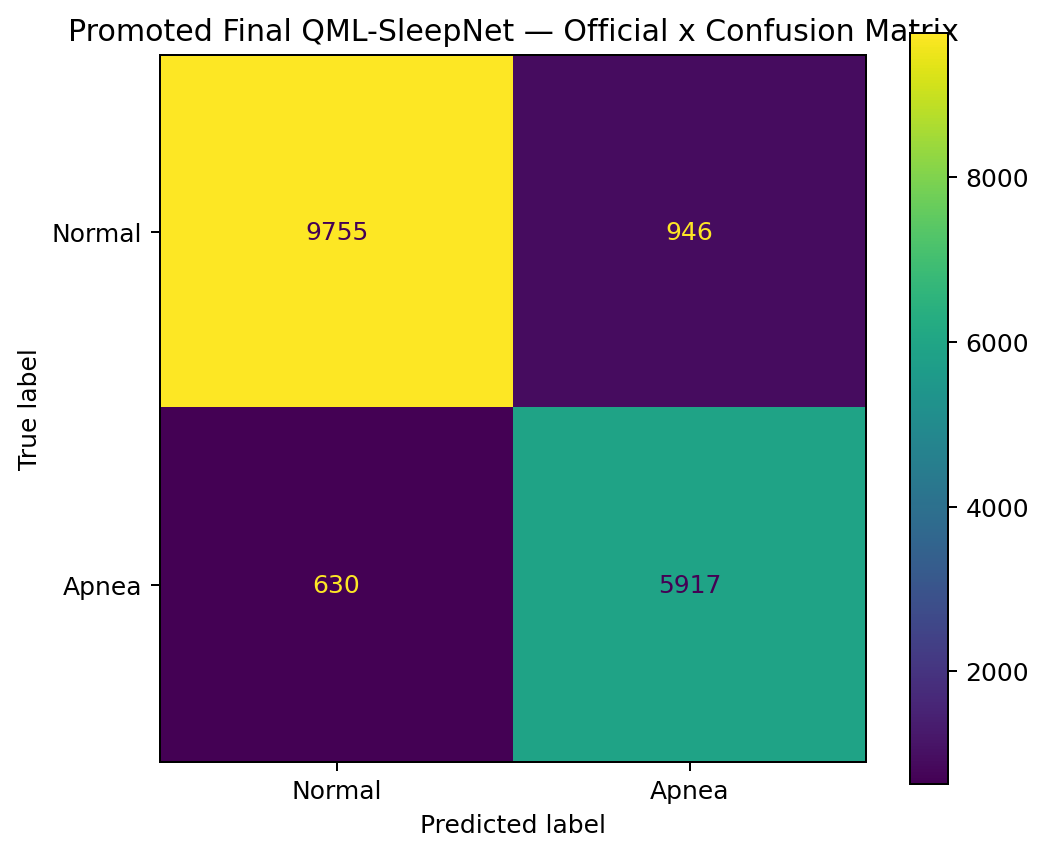

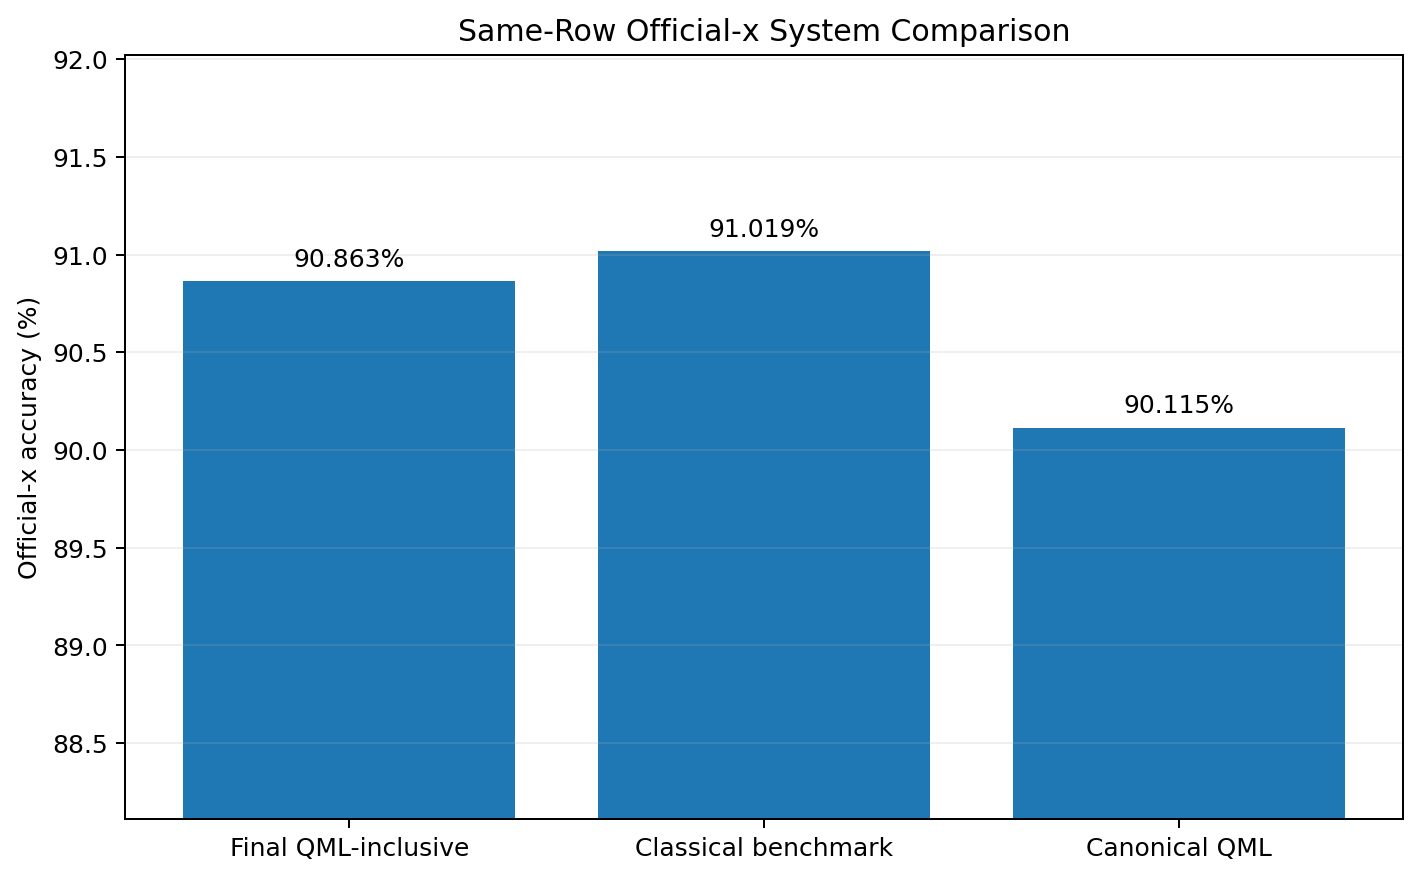

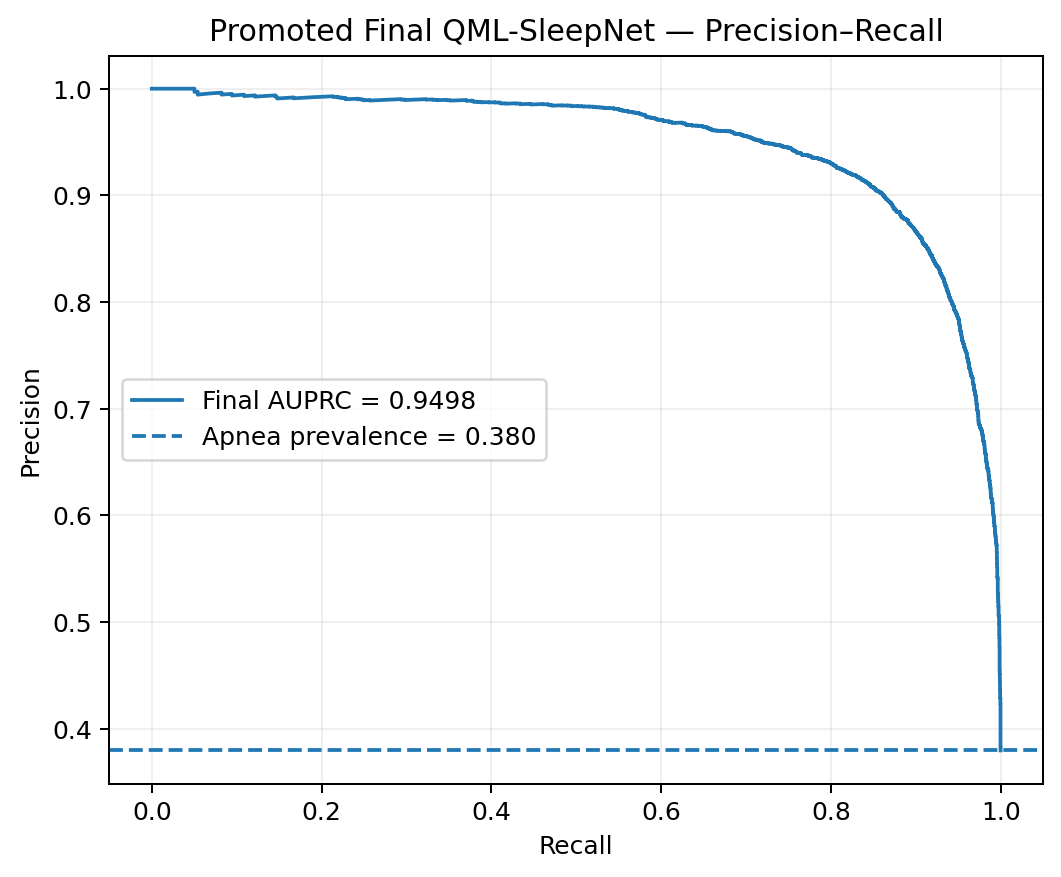

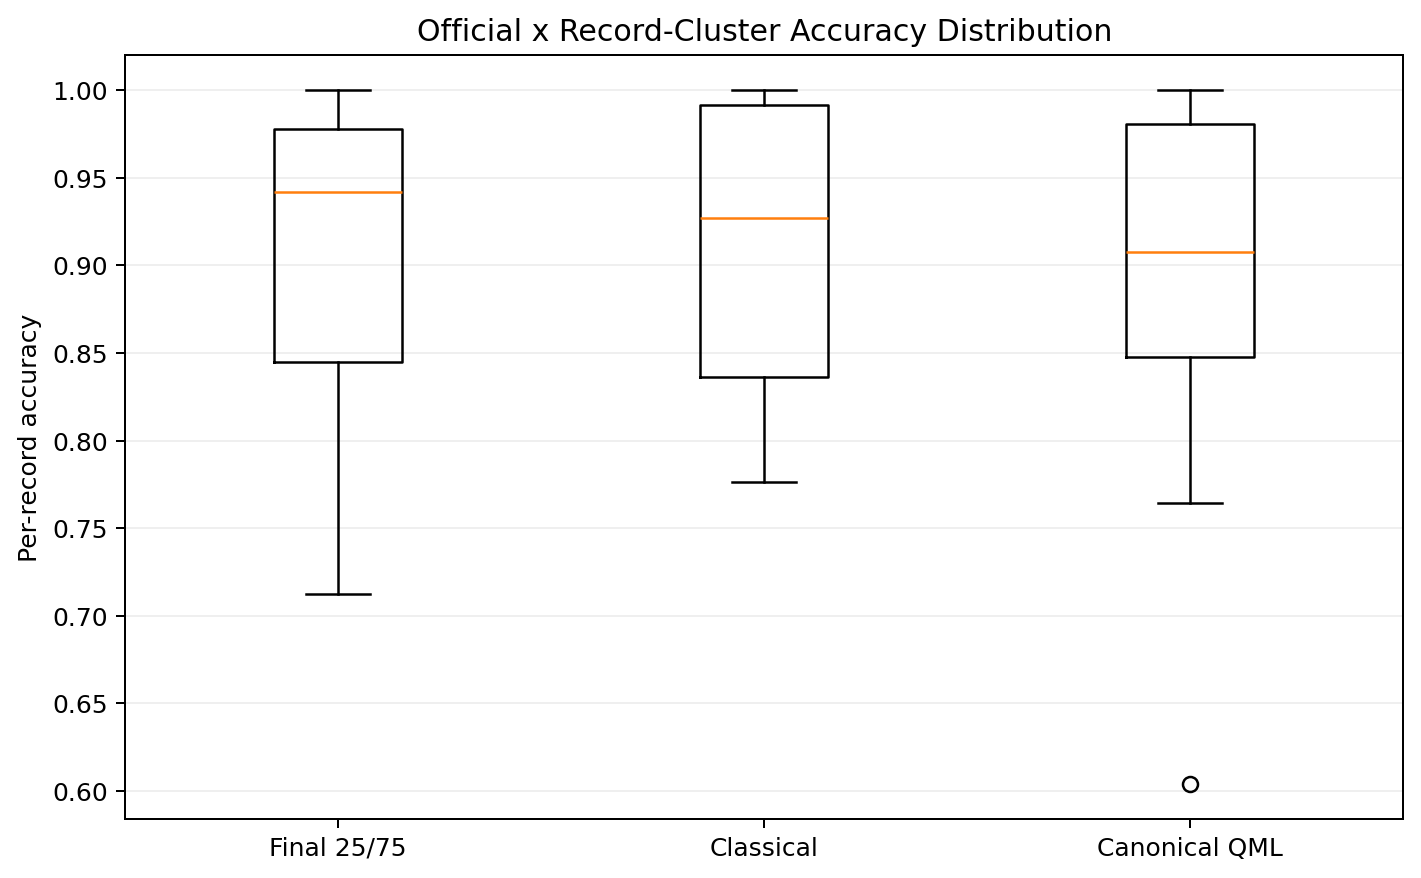

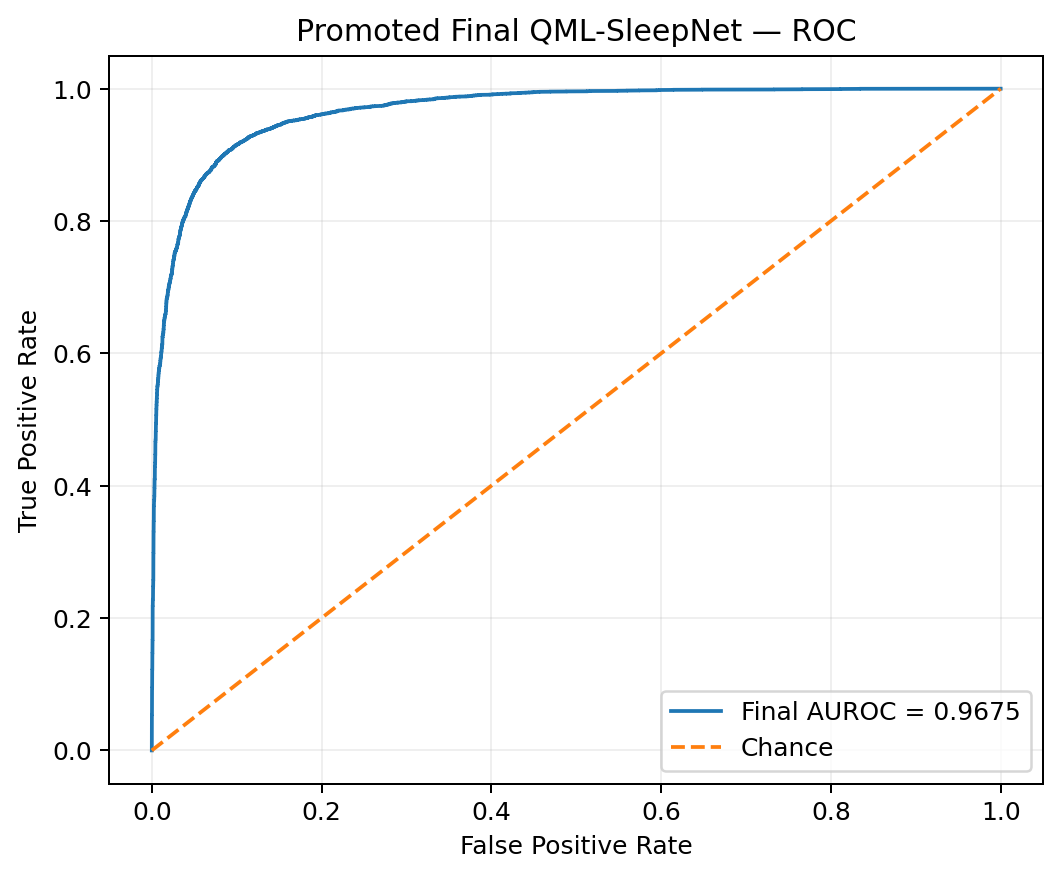

,system,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,mcc,auroc,auprc,brier,nll,tn,fp,fn,tp,accuracy_delta_vs_promoted_final_pp,interpretation,promotion_allowed_from_stage11
0,PHYSIOLOGY_PARENT_ONLY,17248,0.910192,0.909747,0.862700,0.907897,0.911597,0.884721,0.811954,0.969663,0.950449,0.079585,0.441768,9755,946,603,5944,0.156540,remove QML fusion contribution; classical pare...,False
1,PROMOTED_FINAL_PHYS25_QML75,17248,0.908627,0.907685,0.862159,0.903773,0.911597,0.882476,0.808403,0.967524,0.949776,0.079645,0.433467,9755,946,630,5917,0.000000,locked promoted final,False
2,QML_PARENT_ONLY,17248,0.901148,0.900116,0.851481,0.895830,0.904401,0.873093,0.792908,0.962067,0.942772,0.086143,0.487634,9678,1023,682,5865,-0.747913,remove Stage15A physiology parent; canonical Q...,False


,kind,artifact,path,sha256
0,input,promoted_final_prediction,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,063a017e61188393bcdcdacb72958ffa3e7e0efa9432d3...
1,input,promoted_final_freeze,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,75028451ec5e8d7e051ecec514b8c305a2e25aa22305cb...
2,input,promoted_final_x_report,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,09cf1b3bb5214ea52873a2a741a34d946bd5671a223ac4...
3,input,promoted_final_development_decision,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,7bdbbc2804f1e222c1d700c92005c0d5a0739fa1c5e40e...
4,input,physiology_parent_prediction,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,e548af5c1d8ad39f8ea192680ee7ae7af303b993e65f41...
5,input,qml_parent_prediction,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,f121a79191be00a28f33e06e7dec20cc689268b10a988c...
6,input,official_label_json,/content/drive/MyDrive/QML_SleepNet/data/raw/a...,2583c19b96d778cc2d442f175b11d54185c170a692a8bb...
7,input,official_label_txt,/content/drive/MyDrive/QML_SleepNet/data/raw/a...,895905c1188ec45b302e094cd823070d7e2b1da2ca1ef8...
8,input,promoted_xai_manifest,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,05451c3da83128e5c299acc6489b58805cccc3e422ace3...
9,input,promoted_stage10_manifest,/content/drive/MyDrive/QML_SleepNet/outputs/GU...,e86864caaa9f55ea5ac1bde0a3d3721999991f83f13aff...


,class_label,class_name,precision,recall,f1,support
0,0,Normal (N),0.939336,0.911597,0.925258,10701
1,1,Apnea (A),0.862159,0.903773,0.882476,6547


,entry,context,correct_minutes,denominator_minutes,accuracy,source_url,same_x01_x35_task_family,protocol_identical_to_current_project
0,McNames / Fraser / Rechtsteiner,PhysioNet/CinC Challenge 2000 Event 2,15994,17268,0.926222,https://physionet.org/content/challenge-2000/1...,True,False
1,Raymond / Cayton / Bates / Chappell,PhysioNet/CinC Challenge 2000 Event 2,15939,17268,0.923037,https://physionet.org/content/challenge-2000/1...,True,False
2,de Chazal et al.,PhysioNet/CinC Challenge 2000 Event 2,15432,17268,0.893676,https://physionet.org/content/challenge-2000/1...,True,False
3,QML-SleepNet promoted final,Current frozen project evaluation,15672,17248,0.908627,internal frozen Stage11 reproduction,True,True


,Field,Value
0,authoritative_reference,PhysioNet/Computing in Cardiology Challenge 20...
1,challenge_reference_minutes,17268
2,current_project_policy,complete observed raw 60-second ECG minute AND...
3,current_project_scored_minutes,17248
4,direct_sota_claim_allowed,False
5,minute_count_difference,20
6,modern_sota_claim,NOT ASSERTED: no modern paper is called protoc...
7,reason,The official historical Challenge leaderboard ...
8,reference_url,https://physionet.org/content/challenge-2000/1...


...

,record_name,system,n_minutes,apnea_prevalence,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,mcc,auroc,auprc,brier,nll,tn,fp,fn,tp
0,x01,FINAL_QML_INCLUSIVE_PROMOTED,522,0.718391,522,0.773946,0.817850,0.957295,0.717333,0.918367,0.820122,0.573542,0.898177,0.960072,2.048325e-01,1.157473,135,12,106,269
1,x01,STAGE15A_PHYSIOLOGY_CLASSICAL,522,0.718391,522,0.785441,0.809306,0.933993,0.754667,0.863946,0.834808,0.563832,0.899365,0.959174,1.977287e-01,1.048676,127,20,92,283
2,x01,CANONICAL_GUIDE_QML,522,0.718391,522,0.775862,0.819184,0.957447,0.720000,0.918367,0.821918,0.576122,0.890649,0.957760,2.074501e-01,1.254671,135,12,105,270
3,x02,FINAL_QML_INCLUSIVE_PROMOTED,469,0.445629,469,0.965885,0.967354,0.944700,0.980861,0.953846,0.962441,0.931763,0.994645,0.992930,2.759264e-02,0.103405,248,12,4,205
4,x02,STAGE15A_PHYSIOLOGY_CLASSICAL,469,0.445629,469,0.936034,0.942308,0.874477,1.000000,0.884615,0.933036,0.879532,0.992731,0.990604,4.950466e-02,0.204727,230,30,0,209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,x34,STAGE15A_PHYSIOLOGY_CLASSICAL,474,0.008439,474,0.991561,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,0.704255,0.018691,8.437731e-03,0.076925,470,0,4,0
101,x34,CANONICAL_GUIDE_QML,474,0.008439,474,0.989451,0.498936,0.000000,0.000000,0.997872,0.000000,-0.004242,0.618617,0.016864,1.050269e-02,0.080703,469,1,4,0
102,x35,FINAL_QML_INCLUSIVE_PROMOTED,482,0.000000,482,1.000000,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,3.180364e-04,0.001650,482,0,0,0
103,x35,STAGE15A_PHYSIOLOGY_CLASSICAL,482,0.000000,482,1.000000,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,6.924639e-08,0.000086,482,0,0,0


,evidence_domain,system,mean_auroc,worst_fold_auroc,mean_auprc,mean_group_macro_auroc,quantum_advantage_claim_allowed,role
0,Stage15E2 strict development folds; 6-D matche...,ANISOTROPIC_ANGLE_QSVC,0.878269,0.862332,0.817003,0.815342,False,NaN
1,Stage15E2 strict development folds; 6-D matche...,VQC_REALAMPLITUDES_SPSA,0.876536,0.848437,0.814980,0.809278,False,NaN
2,Stage15E2 strict development folds; 6-D matche...,CLASSICAL_6D_RBF_PROXY,0.873848,0.856473,0.816997,0.808671,False,NaN
3,"Official x same 17,248 frozen project rows",FINAL_QML_INCLUSIVE_PROMOTED,0.967524,NaN,0.949776,NaN,False,25% classical + 75% QML final
4,"Official x same 17,248 frozen project rows",STAGE15A_PHYSIOLOGY_CLASSICAL,0.969663,NaN,0.950449,NaN,False,classical-only benchmark
5,"Official x same 17,248 frozen project rows",CANONICAL_GUIDE_QML,0.962067,NaN,0.942772,NaN,False,guide-primary QML system


,analysis,system_a,system_b,metric,observed,bootstrap_mean,ci95_low,ci95_high,probability_delta_gt_0,replicates,resampling_unit
0,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,accuracy,0.908627,0.908676,0.882403,0.933873,NaN,5000,official x record cluster
1,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,balanced_accuracy,0.907685,0.907149,0.880684,0.933057,NaN,5000,official x record cluster
2,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,precision,0.862159,0.861411,0.803242,0.907915,NaN,5000,official x record cluster
3,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,sensitivity,0.903773,0.903504,0.852913,0.947085,NaN,5000,official x record cluster
4,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,specificity,0.911597,0.910794,0.869758,0.946013,NaN,5000,official x record cluster
5,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,f1,0.882476,0.881571,0.844686,0.913725,NaN,5000,official x record cluster
6,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,mcc,0.808403,0.806887,0.756632,0.855133,NaN,5000,official x record cluster
7,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,auroc,0.967524,0.967460,0.952173,0.980662,NaN,5000,official x record cluster
8,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,auprc,0.949776,0.949388,0.917297,0.972344,NaN,5000,official x record cluster
9,FINAL_METRIC_CI,FINAL_QML_INCLUSIVE_PROMOTED,NaN,brier,0.079645,0.079603,0.057183,0.103151,NaN,5000,official x record cluster


,fold,qsvc_auroc,qsvc_auprc,qsvc_balanced_accuracy,qsvc_group_macro_auroc,vqc_auroc,vqc_auprc,vqc_balanced_accuracy,vqc_group_macro_auroc
0,0,0.883865,0.843898,0.709661,0.809625,0.902240,0.867706,0.712507,0.811070
1,1,0.881037,0.805076,0.787393,0.828967,0.884191,0.790509,0.742281,0.801923
2,2,0.885844,0.804428,0.753308,0.853621,0.871276,0.806923,0.714397,0.855587
3,3,0.862332,0.814611,0.746191,0.769153,0.848437,0.794781,0.705499,0.768532


,system_a,system_b,n_pairs,mean_accuracy_a,mean_accuracy_b,mean_paired_difference,mean_paired_difference_pp,t_statistic,p_value_raw,cohen_dz,ci95_mean_difference_low,ci95_mean_difference_high,ci95_mean_difference_low_pp,ci95_mean_difference_high_pp,metric_tested,statistical_unit,interpretation_boundary,p_value_holm,significant_holm_0p05
0,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.878269,0.876536,0.001734,0.173353,0.220622,0.839548,0.110311,-0.023272,0.026739,-2.327237,2.673943,auroc,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,1.000000,False
1,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.817003,0.814980,0.002024,0.202357,0.205628,0.850244,0.102814,-0.029295,0.033342,-2.929463,3.334176,auprc,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,1.000000,False
2,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.749138,0.718671,0.030467,3.046728,2.724975,0.072246,1.362487,-0.005115,0.066049,-0.511488,6.604944,balanced_accuracy,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,0.288983,False
3,ANISOTROPIC_ANGLE_QSVC,VQC_REALAMPLITUDES_SPSA,4,0.815342,0.809278,0.006064,0.606373,0.864333,0.450982,0.432166,-0.016263,0.028390,-1.626274,2.839020,group_macro_auroc,four matched strict development folds,EXPLORATORY / LOW POWER: n=4 development folds...,1.000000,False


In [13]:
stage_banner(11, "Final Evaluation & Statistical Analysis", "Official x-set performance, class-wise metrics, uncertainty and paired comparisons")

# Reproduce final metrics directly from frozen predictions.
report_df=pd.DataFrame(classification_report(
    Y,PRED,target_names=["Normal","Apnea"],output_dict=True,zero_division=0
)).T
display(report_df)
register_table("11_classification_report.csv", report_df.reset_index(names="class_or_average"))

fig,ax=plt.subplots(figsize=(5.8,5))
ConfusionMatrixDisplay.from_predictions(
    Y,PRED,labels=[0,1],display_labels=["Normal","Apnea"],values_format="d",ax=ax
)
ax.set_title("Final QML-SleepNet confusion matrix")
fig.tight_layout()
register_visual("11_confusion_matrix.png")
plt.show(); plt.close(fig)

fpr,tpr,_=roc_curve(Y,P_FINAL)
fig,ax=plt.subplots(figsize=(6,5))
ax.plot(fpr,tpr,label=f"AUROC = {M_FINAL['auroc']:.4f}")
ax.plot([0,1],[0,1],linestyle="--")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Final QML-SleepNet ROC curve"); ax.legend(); ax.grid(alpha=.2)
fig.tight_layout()
register_visual("11_roc_curve.png")
plt.show(); plt.close(fig)

pc,rc,_=precision_recall_curve(Y,P_FINAL)
fig,ax=plt.subplots(figsize=(6,5))
ax.plot(rc,pc,label=f"AUPRC = {M_FINAL['auprc']:.4f}")
ax.axhline(Y.mean(),linestyle="--",label=f"Apnea prevalence = {Y.mean():.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Final QML-SleepNet precision–recall curve"); ax.legend(); ax.grid(alpha=.2)
fig.tight_layout()
register_visual("11_precision_recall_curve.png")
plt.show(); plt.close(fig)

final_table=pd.DataFrame([
    ["Final QML-inclusive",M_FINAL["accuracy"],M_FINAL["balanced_accuracy"],M_FINAL["precision"],M_FINAL["sensitivity"],M_FINAL["specificity"],M_FINAL["f1"],M_FINAL["mcc"],M_FINAL["auroc"],M_FINAL["auprc"]],
    ["Classical benchmark",M_PHYS["accuracy"],M_PHYS["balanced_accuracy"],M_PHYS["precision"],M_PHYS["sensitivity"],M_PHYS["specificity"],M_PHYS["f1"],M_PHYS["mcc"],M_PHYS["auroc"],M_PHYS["auprc"]],
    ["Canonical QML",M_QML["accuracy"],M_QML["balanced_accuracy"],M_QML["precision"],M_QML["sensitivity"],M_QML["specificity"],M_QML["f1"],M_QML["mcc"],M_QML["auroc"],M_QML["auprc"]],
],columns=["System","Accuracy","Balanced Accuracy","Precision","Sensitivity","Specificity","F1","MCC","AUROC","AUPRC"])
display(final_table)
register_table("11_final_model_comparison.csv", final_table)

fig,ax=plt.subplots(figsize=(8.5,4.5))
ax.bar(final_table["System"],100*final_table["Accuracy"])
ax.set_ylabel("accuracy (%)")
ax.set_title("Official-x system comparison")
for i,v in enumerate(100*final_table["Accuracy"]):
    ax.text(i,v+.04,f"{v:.3f}%",ha="center")
fig.tight_layout()
register_visual("11_final_model_accuracy_comparison.png")
plt.show(); plt.close(fig)

# Completed inferential outputs from Stage11.
for filename in [
    "STAGE11_PAIRED_STATISTICS.csv",
    "STAGE11_RECORD_CLUSTER_BOOTSTRAP_CI.csv",
    "STAGE11_VQC_QSVC_DEVELOPMENT_STATISTICS.csv",
    "STAGE11_EXTERNAL_BENCHMARK_CONTEXT.csv",
]:
    p=S11_ROOT/filename
    if p.is_file():
        df=pd.read_csv(p)
        display(HTML(f"<h4>{clean_artifact_name(filename).replace('_',' ')}</h4>"))
        display(df)
        register_table(clean_artifact_name(filename).lower(), df)

# Final 95% confidence interval cards when available.
bootp=S11_ROOT/"STAGE11_RECORD_CLUSTER_BOOTSTRAP_CI.csv"
if bootp.is_file():
    boot=pd.read_csv(bootp)
    sub=boot[(boot["analysis"]=="FINAL_METRIC_CI") & boot["metric"].isin(["accuracy","balanced_accuracy","auroc","auprc"])]
    cards=[]
    for r in sub.itertuples(index=False):
        cards.append((str(r.metric).upper(),f"{r.observed:.4f}",f"95% CI {r.ci95_low:.4f}–{r.ci95_high:.4f}"))
    metric_cards(cards)

display(HTML("""
<div style="padding:10px 14px;background:#F0F4F8;border-left:5px solid #627D98;border-radius:8px;">
<b>Inference unit:</b> paired statistical tests and bootstrap uncertainty use the 35 official x record clusters.
The 17,248 minute epochs are not treated as independent observations for inferential claims.
</div>
"""))

display_artifact_gallery(
    S11_ROOT,
    "Final evaluation — complete frozen tables and figures",
    recursive=True,
    table_mode="all",
    max_files=80
)


## Stage 12

In [14]:
stage_banner(12, "Reproducibility & Evidence Lineage", "Artifact identities, runtime environment and self-contained notebook evidence")

versions=pd.DataFrame([
    ["Python",platform.python_version()],
    ["NumPy",np.__version__],
    ["Pandas",pd.__version__],
    ["scikit-learn",__import__("sklearn").__version__],
    ["Matplotlib",__import__("matplotlib").__version__],
],columns=["Package","Version"])
display(versions)
register_table("12_runtime_versions", versions)

critical_sources = {
    "Final promoted prediction": FUSED_X,
    "Final pre-score freeze": FUSION_FREEZE,
    "Classical parent prediction": PHYS_X,
    "Canonical QML parent prediction": QML_X,
    "Official annotation JSON": LABEL_JSON,
    "Official annotation TXT": LABEL_TXT,
    "Interpretability manifest": XAI_ROOT/"XAI_PROMOTED_FINAL_MANIFEST.json",
    "Robustness manifest": S10_ROOT/"STAGE10_PROMOTED_FINAL_MANIFEST.json",
    "Final evaluation manifest": S11_ROOT/"STAGE11_FINAL_MANIFEST.json",
}
hash_rows=[]
for label,p in critical_sources.items():
    hash_rows.append({
        "Artifact":label,
        "Present":bool(Path(p).is_file()),
        "SHA256":sha256_file(p) if Path(p).is_file() else "",
        "File":clean_artifact_name(Path(p).name),
    })
hash_df=pd.DataFrame(hash_rows)
display(hash_df)
register_table("12_critical_artifact_hashes", hash_df)

display(HTML(f"""
<div style="margin-top:18px;padding:18px 20px;border-radius:12px;background:#ECFDF5;border:1px solid #A7F3D0;">
  <div style="font-size:18px;font-weight:800;color:#065F46;">Self-contained execution contract verified</div>
  <div style="font-size:13px;color:#276749;margin-top:6px;">
    No presentation PNG, CSV, JSON or manifest is written by this notebook.
    Figures and tables are rendered directly into the notebook output cells.
    When the executed notebook is saved, the displayed evidence travels with the .ipynb file.
  </div>
</div>
"""))

print("="*112)
print("QML-SLEEPNET ACADEMIC SUBMISSION EVIDENCE NOTEBOOK — COMPLETE")
print("="*112)
print(f"Final QML-inclusive accuracy: {100*M_FINAL['accuracy']:.4f}%")
print(f"Best classical-only benchmark: {100*M_PHYS['accuracy']:.4f}%")
print(f"Canonical QML system: {100*M_QML['accuracy']:.4f}%")
print("Training performed: NO")
print("Tuning performed: NO")
print("Pipeline nodes derived from verified artifacts: YES")
print("Presentation files written to Drive: NO")
print("Visuals/tables embedded directly in notebook: YES")

print("All renderable source artifacts are displayed directly in their relevant stage sections.")
print("No filename-only presentation inventory is appended.")

,Package,Version
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,scikit-learn,1.6.1
4,Matplotlib,3.10.0


,Artifact,Present,SHA256,File
0,Final promoted prediction,True,063a017e61188393bcdcdacb72958ffa3e7e0efa9432d3...,FINAL_FIXED_FUSION_X_PREDICTIONS_FROZEN_BEFORE...
1,Final pre-score freeze,True,75028451ec5e8d7e051ecec514b8c305a2e25aa22305cb...,FINAL_FIXED_FUSION_PRE_SCORE_FREEZE_MANIFEST.json
2,Classical parent prediction,True,e548af5c1d8ad39f8ea192680ee7ae7af303b993e65f41...,DEV35_STAGE15A_PHYSIO_BOOSTING_X_PREDICTIONS_F...
3,Canonical QML parent prediction,True,f121a79191be00a28f33e06e7dec20cc689268b10a988c...,FINAL_FIXED_EQUAL_LOGIT_X_PREDICTIONS_FROZEN_B...
4,Official annotation JSON,True,2583c19b96d778cc2d442f175b11d54185c170a692a8bb...,test_set_apnea_labels.json
5,Official annotation TXT,True,895905c1188ec45b302e094cd823070d7e2b1da2ca1ef8...,test-dataset-annos.txt
6,Interpretability manifest,True,05451c3da83128e5c299acc6489b58805cccc3e422ace3...,XAI_PROMOTED_FINAL_MANIFEST.json
7,Robustness manifest,True,e86864caaa9f55ea5ac1bde0a3d3721999991f83f13aff...,STAGE10_PROMOTED_FINAL_MANIFEST.json
8,Final evaluation manifest,True,edcd2d027f42041bcaf1e5f13bfd458ebdf1b779f4b29f...,STAGE11_FINAL_MANIFEST.json


QML-SLEEPNET ACADEMIC SUBMISSION EVIDENCE NOTEBOOK — COMPLETE
Final QML-inclusive accuracy: 90.8627%
Best classical-only benchmark: 91.0192%
Canonical QML system: 90.1148%
Training performed: NO
Tuning performed: NO
Pipeline nodes derived from verified artifacts: YES
Presentation files written to Drive: NO
Visuals/tables embedded directly in notebook: YES


Referenced source artifacts replaced by inline content wherever the source format is renderable.


# Final Report Assembly Order

After this notebook has been executed successfully, the final academic document can be assembled directly from the tables and figures displayed inside this notebook in this order:

1. **Project title and dataset**
2. **Complete system architecture**
3. **Stage 01 — Data Acquisition**
4. **Stage 02 — Signal Preprocessing & Segmentation**
5. **Stage 03 — Physiological Feature Engineering**
6. **Stage 04 — Spatio-Temporal Modeling**
7. **Stage 05 — Quantum-Ready Feature Reduction**
8. **Stage 06 — Quantum Machine Learning**
9. **Stage 07 — Classical Baselines & Physiology Benchmark**
10. **Stage 08 — Hybrid Task Modeling**
11. **Stage 09 — Interpretability & Causal Analysis**
12. **Stage 10 — Robustness & Ablation**
13. **Stage 11 — Final Evaluation & Statistical Analysis**
14. **Stage 12 — Reproducibility**
15. **Final consolidated results**
16. **Limitations and scientific boundaries**

The notebook is deliberately designed so that the report can be created primarily from **inline figures, inline tables and compact technical receipts**, rather than long narrative text. No separate presentation-asset folder is required.

In [15]:
# Final consolidated results card

metric_cards([
    ("FINAL QML-INCLUSIVE", f"{100*M_FINAL['accuracy']:.2f}%", "official-x accuracy"),
    ("CLASSICAL BENCHMARK", f"{100*M_PHYS['accuracy']:.2f}%", "best classical-only"),
    ("CANONICAL QML", f"{100*M_QML['accuracy']:.2f}%", "three-branch QML parent"),
    ("FINAL F1", f"{M_FINAL['f1']:.4f}", "Apnea class"),
    ("FINAL MCC", f"{M_FINAL['mcc']:.4f}", "binary correlation"),
    ("FINAL AUROC", f"{M_FINAL['auroc']:.4f}", "ranking performance"),
])

display(HTML("""
<div style="margin-top:18px;padding:18px 22px;background:#ECFDF5;border:1px solid #A7F3D0;border-radius:12px;">
  <div style="font-size:20px;font-weight:800;color:#065F46;">Submission evidence package ready</div>
  <div style="font-size:13px;color:#276749;margin-top:6px;">
    All displayed results are derived from frozen project artifacts. This notebook performs read-only
    verification and inline presentation only; the executed notebook itself contains the visual evidence.
  </div>
</div>
"""))